In [31]:
import os
import sys
import subprocess
import glob as glob
import shlex
from scipy.signal import medfilt
from scipy.special import wofz
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import seaborn as sb
import healpy
import numpy as np
import desispec.io
import fitsio
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from astropy.io import fits
import glob

sb.set_style('white')

# 1) Paths
DESISIM_REPO = "/pscratch/sd/m/mherbold/desisim"
DESISIM_PY   = f"{DESISIM_REPO}/py"
DESIMODEL_REPO = "/pscratch/sd/m/mherbold/desidatamodel/py/desimodeldata"
DESIMODEL_PY   = f"{DESIMODEL_REPO}/py"

# 2) Make sure Python can import desisim from your clone
os.environ["PYTHONPATH"] = DESISIM_PY + (":" + os.environ["PYTHONPATH"] if "PYTHONPATH" in os.environ else "")
if DESISIM_PY not in sys.path:
    sys.path.insert(0, DESISIM_PY)
os.environ["PYTHONPATH"] = DESIMODEL_PY + (":" + os.environ["PYTHONPATH"] if "PYTHONPATH" in os.environ else "")
if DESIMODEL_PY not in sys.path:
    sys.path.insert(0, DESIMODEL_PY)
    
# Optional but often needed by DESI stack:
# os.environ["DESIMODEL"] = "/path/to/desimodel"
# os.environ["DESI_ROOT"] = "/path/to/desi_root"

# Set device to GPU if available, else CPU
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
device
# print(f"Using device: {device}")

print(torch.cuda.is_available())

False


In [2]:
%matplotlib inline

In [3]:
# DR1 test
ifile = '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/transmission-16-1_2.fits'   # with z-mask

# full wavelength
outdir = '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/'

print(outdir) # Adjuts the path if this is not where you want to store the files produced by this tutorial 

/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/


## CNN test

### Metal-line CNN for Lyman-alpha forest mocks (quickquasars)

This notebook (cell-marked `.py`, open with Jupytext or paste cells into Jupyter)
builds a small 1D CNN that detects the rest-frame wavelength (i.e. which known
metal transition) and strength (optical depth / EW-like amplitude) of metal
contaminant lines injected by `quickquasars` into Lya-forest mock spectra.

#### Design idea
`quickquasars` generates metal absorption from the *same* density skewer as
Lya, evaluated at the redshift implied by the metal's rest wavelength lambda_m
instead of 1215.67 A. In log10(lambda_obs) space this is a **constant**
additive shift:

    delta_m = log10(1215.67 / lambda_m)

independent of z_qso or z_absorber. That means the metal optical depth at a
given pixel is (a scaled, noisy version of) the Lya forest optical depth at a
*fixed* pixel offset elsewhere in the same spectrum. We exploit this by
feeding the CNN the raw flux *and* copies of the flux shifted by each known
delta_m as extra channels, turning "find a correlated echo far away in the
spectrum" into a local regression problem.

Adapt the TODO-marked I/O functions to your actual quickquasars output
(spectra-*.fits / truth-*.fits / transmission-*.fits paths and HDU names).

#### 1. Config: grid, transitions, pixel shifts

In [4]:

LYA_REST = 1215.67  # Angstrom

# Match this EXACTLY to the --metals list you passed to quickquasars.
METAL_LINES_FULL = {
    "SiII_1190": 1190.4158,
    "SiII_1193": 1193.2897,
    "SiIII_1207": 1206.500,
    "SiII_1260": 1206.500,
    "CIV_1548": 1548.2049,
    "CIV_1550": 1550.77845,
    'MgI(2853)': 2852.96,
}


# current test case: single contaminant, exaggerated strength, for pipeline validation
METAL_LINES = {
    # "SiII_1304": 1304.37,
    'MgI(2853)': 2852.96,
}
 
# FOREST_MIN = 1040.0   # rest-frame forest window (quasar rest frame), Angstrom
# FOREST_MAX = 1200.0   # keep clear of the Lya emission line proximity zone
FOREST_MIN = 1040.0   
FOREST_MAX = 3500.0 

N_PIX = 256
 
LOG_MIN = np.log10(FOREST_MIN)
LOG_MAX = np.log10(FOREST_MAX)
DLOGLAM = (LOG_MAX - LOG_MIN) / N_PIX
REST_GRID = 10 ** (LOG_MIN + (np.arange(N_PIX) + 0.5) * DLOGLAM)
 
 
def pixel_shift(lambda_m):
    """Constant pixel offset (in the fixed log-lambda grid) between a metal
    echo and the Lya-forest pattern it was copied from."""
    delta_loglam = np.log10(LYA_REST / lambda_m)
    return int(round(delta_loglam / DLOGLAM))

def shift_edge_padded(arr, shift, pad_value=1.0):
    """Shift an array without wrap-around, padding exposed pixels.

    Parameters
    ----------
    arr : array-like
        Input spectrum.
    shift : int
        Number of pixels to shift. Positive shifts toward larger pixel index.
    pad_value : float
        Value used to fill pixels exposed by the shift. For normalized flux,
        1.0 corresponds to no absorption.

    Returns
    -------
    shifted : ndarray
        Shifted, edge-padded array with the same length as arr.
    """
    arr = np.asarray(arr)
    shifted = np.full_like(arr, pad_value)

    if shift > 0:
        shifted[shift:] = arr[:-shift]
    elif shift < 0:
        shifted[:shift] = arr[-shift:]
    else:
        shifted[:] = arr

    return shifted
 
 
PIXEL_SHIFTS = {name: pixel_shift(w) for name, w in METAL_LINES.items()}
METAL_NAMES = list(METAL_LINES.keys())
N_METALS = len(METAL_NAMES)
print(PIXEL_SHIFTS)


{'MgI(2853)': -180}


#### 2. I/O — adapt to quickquasars outputs


In [5]:
base_path = '/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc'

uncontaminated = f'{base_path}/UNCONTAMINATED-1e5/spectra.fits'
contaminated = f'{base_path}/METAL_TEST_MgI-TEMP-1e5/spectra.fits'
# contaminated = f'{base_path}/METAL_TEST_MgI-TEMP-4/spectra.fits'

fitsio.FITS(contaminated)



  file: /pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/spectra.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      FIBERMAP
  2      IMAGE_HDU       B_WAVELENGTH
  3      IMAGE_HDU       B_FLUX
  4      IMAGE_HDU       B_IVAR
  5      IMAGE_HDU       B_MASK
  6      IMAGE_HDU       R_WAVELENGTH
  7      IMAGE_HDU       R_FLUX
  8      IMAGE_HDU       R_IVAR
  9      IMAGE_HDU       R_MASK
  10     IMAGE_HDU       Z_WAVELENGTH
  11     IMAGE_HDU       Z_FLUX
  12     IMAGE_HDU       Z_IVAR
  13     IMAGE_HDU       Z_MASK

In [6]:

import desispec.io
import fitsio
 
TRUTH_FILENAME = "truth-16-12.fits" 
 
 
def read_arm_concat(spectra_path, targetid, spectra_obj=None):
    """
    Read+concatenate the B/R/Z arms for one TARGETID from a quickquasars
    spectra.fits file. Drops masked / non-positive-ivar pixels.
    Pass a pre-loaded `spectra_obj` (from desispec.io.read_spectra) to avoid
    re-reading the file for every target when looping over many TARGETIDs
    from the same file.
    """
    spectra = spectra_obj if spectra_obj is not None else desispec.io.read_spectra(spectra_path)
    tids = spectra.fibermap["TARGETID"]
    matches = np.where(np.asarray(tids) == targetid)[0]
    if len(matches) == 0:
        raise ValueError(f"TARGETID {targetid} not found in {spectra_path}")
    idx = matches[0]
 
    waves, fluxes, ivars = [], [], []
    for band in ["b", "r", "z"]:
        wave = spectra.wave[band]
        flux = spectra.flux[band][idx]
        ivar = spectra.ivar[band][idx]
        mask = spectra.mask[band][idx] if spectra.mask is not None else np.zeros_like(flux, dtype=int)
        good = (mask == 0) & (ivar > 0)
        waves.append(wave[good])
        fluxes.append(flux[good])
        ivars.append(ivar[good])
 
    wave_obs = np.concatenate(waves)
    flux = np.concatenate(fluxes)
    ivar = np.concatenate(ivars)
    order = np.argsort(wave_obs)
    # NOTE: b/r/z arms overlap slightly at their edges, so the concatenated
    # array isn't perfectly monotonic-unique there -- fine for interp1d used
    # below, but if you need a proper coadd in the overlap region later,
    # desispec has coaddition utilities for that.
    return wave_obs[order], flux[order], ivar[order]
 
 
def get_common_targetids(path_a, path_b):
    """TARGETIDs present in both the contaminated and uncontaminated files."""
    tid_a = fitsio.FITS(path_a)["FIBERMAP"].read(columns=["TARGETID"])["TARGETID"]
    tid_b = fitsio.FITS(path_b)["FIBERMAP"].read(columns=["TARGETID"])["TARGETID"]
    return np.intersect1d(tid_a, tid_b)
 
 
def read_arm_concat_raw(spectra_path, targetid, spectra_obj=None):
    """
    Like read_arm_concat, but does NOT drop masked pixels -- returns the FULL
    fixed instrument wavelength grid (same length/values for every target on
    the same instrument setup). Needed so that the contaminated and
    uncontaminated exposures of the same TARGETID line up pixel-for-pixel
    without any interpolation, which matters for the shared-continuum trick
    in build_paired_sample below.
    """
    spectra = spectra_obj if spectra_obj is not None else desispec.io.read_spectra(spectra_path)
    tids = spectra.fibermap["TARGETID"]
    matches = np.where(np.asarray(tids) == targetid)[0]
    if len(matches) == 0:
        raise ValueError(f"TARGETID {targetid} not found in {spectra_path}")
    idx = matches[0]
 
    waves, fluxes, ivars, masks = [], [], [], []
    for band in ["b", "r", "z"]:
        wave = spectra.wave[band]
        flux = spectra.flux[band][idx]
        ivar = spectra.ivar[band][idx]
        mask = spectra.mask[band][idx] if spectra.mask is not None else np.zeros_like(flux, dtype=int)
        waves.append(wave)
        fluxes.append(flux)
        ivars.append(ivar)
        masks.append(mask)
 
    wave_obs = np.concatenate(waves)
    flux = np.concatenate(fluxes)
    ivar = np.concatenate(ivars)
    mask = np.concatenate(masks)
    order = np.argsort(wave_obs)
    return wave_obs[order], flux[order], ivar[order], mask[order]
 
 
def read_ztrue(spectra_path, targetid):
    """Pull Z_true for this TARGETID from the companion truth file."""
    truth_path = os.path.join(os.path.dirname(spectra_path), TRUTH_FILENAME)
    truth = fitsio.FITS(truth_path)["TRUTH"].read(columns=["TARGETID", "Z"])
    row = truth[truth["TARGETID"] == targetid]
    if len(row) == 0:
        raise ValueError(f"TARGETID {targetid} not in truth file {truth_path}")
    return float(row["Z"][0])
 

#### 3. Preprocessing: continuum normalize + resample to fixed rest-frame grid


In [7]:

def continuum_normalize(wave_obs, flux, ivar, z_qso, smooth_pix=150):
    """
    Superseded by the shared-continuum logic inside build_paired_sample --
    normalizing a single noisy exposure independently (as this function
    does) gives each exposure a DIFFERENT noisy continuum estimate, which
    then does NOT cancel in the flux_c/flux_u ratio and leaks noise/bias
    straight into the metal-line label. Left here only as a building block
    if you need to continuum-normalize a single spectrum outside the paired
    pipeline (e.g. for visualizing one exposure on its own).
    """
    from scipy.ndimage import median_filter
    cont = median_filter(flux, size=smooth_pix, mode="nearest")
    cont[cont <= 0] = np.nan
    norm_flux = flux / cont
    norm_ivar = ivar * cont ** 2
    return norm_flux, norm_ivar
 
 
def to_restframe_grid(wave_obs, flux, ivar, z_qso):
    """Resample onto the fixed N_PIX log-lambda grid in the quasar rest frame."""
    rest_wave = wave_obs / (1.0 + z_qso)
    sel = (rest_wave > FOREST_MIN) & (rest_wave < FOREST_MAX) & np.isfinite(flux)
    if sel.sum() < 10:
        return None
    f_interp = interp1d(rest_wave[sel], flux[sel], bounds_error=False, fill_value=1.0)
    iv_interp = interp1d(rest_wave[sel], ivar[sel], bounds_error=False, fill_value=0.0)
    flux_grid = f_interp(REST_GRID)
    ivar_grid = iv_interp(REST_GRID)
    return flux_grid, ivar_grid
 
 
def make_shifted_channels(flux_grid):
    """One extra input channel per metal transition: the forest pattern that
    would echo into that transition's absorption, aligned pixel-for-pixel."""
    channels = []
    for name in METAL_NAMES:
        shift = PIXEL_SHIFTS[name]
        shifted = np.roll(flux_grid, -shift)
        # pad the wrapped-around edge with continuum level (1.0) so it doesn't
        # masquerade as a real feature
        if shift > 0:
            shifted[-shift:] = 1.0
        elif shift < 0:
            shifted[:-shift] = 1.0
        channels.append(shifted)
    return np.stack(channels, axis=0)  # (N_METALS, N_PIX)
 

#### 4. Labels: per-pixel, per-transition metal optical depth


In [8]:

def build_paired_sample(targetid, uncontam_path, contam_path,
                         spectra_uncontam=None, spectra_contam=None,
                         cont_smooth_pix=150):
    """
    Build one training sample from the contaminated / uncontaminated spectra
    for a single TARGETID. Returns None if the forest window isn't covered.
 
    Continuum handling: rather than normalizing each exposure independently
    (which was giving a noisy continuum estimate on EACH side, and since the
    two estimates then differ, that noise doesn't cancel in the flux_c/flux_u
    ratio -- it leaks straight into the metal-line label as spurious
    scatter), we estimate ONE continuum from the average of both exposures
    (halves the noise going into the fit) and divide both sides by that SAME
    continuum. Any residual continuum-fit error or shape then cancels
    exactly in the ratio -- it only affects the overall normalization scale
    of the CNN input, not the label.
    """
    wave_u, flux_u, ivar_u, mask_u = read_arm_concat_raw(uncontam_path, targetid, spectra_uncontam)
    wave_c, flux_c, ivar_c, mask_c = read_arm_concat_raw(contam_path, targetid, spectra_contam)
    z_qso = read_ztrue(uncontam_path, targetid)
 
    if not np.array_equal(wave_u, wave_c):
        raise RuntimeError(
            f"wavelength grids differ between contaminated/uncontaminated "
            f"spectra for TARGETID {targetid} -- unexpected for the same "
            f"instrument setup/target; check that both files really share "
            f"the same fiber/exposure layout."
        )
    wave_obs = wave_u
 
    good = (mask_u == 0) & (mask_c == 0) & (ivar_u > 0) & (ivar_c > 0)
    if good.sum() < 20:
        return None
 
    from scipy.ndimage import median_filter
    avg_flux = 0.5 * (flux_u + flux_c)
    # fill masked/bad pixels for continuum-fitting purposes only, so the
    # median filter doesn't get corrupted by garbage values in masked gaps
    idx_good = np.where(good)[0]
    filled = np.interp(np.arange(len(avg_flux)), idx_good, avg_flux[idx_good])
    cont = median_filter(filled, size=cont_smooth_pix, mode="nearest")
    cont[cont <= 0] = np.nan
 
    flux_u_norm = flux_u / cont
    flux_c_norm = flux_c / cont
    ivar_u_norm = ivar_u * cont ** 2
    ivar_c_norm = ivar_c * cont ** 2
    ivar_u_norm[~good] = 0.0
    ivar_c_norm[~good] = 0.0
 
    grid_u = to_restframe_grid(wave_obs, flux_u_norm, ivar_u_norm, z_qso)
    grid_c = to_restframe_grid(wave_obs, flux_c_norm, ivar_c_norm, z_qso)
    if grid_u is None or grid_c is None:
        return None
    flux_u_grid, ivar_u_grid = grid_u
    flux_c_grid, ivar_c_grid = grid_c
 
    # network input is the *contaminated* (realistic) spectrum; label is the
    # metal-only optical depth recovered by differencing against the
    # metal-free twin. `weight` propagates BOTH exposures' noise (see
    # build_label_maps) since you only have one realization per side -- this
    # is what the training loss uses, not raw `ivar_c_grid`.
    label, weight = build_label_maps(flux_c_grid, flux_u_grid, ivar_c_grid, ivar_u_grid)
    return {
        "flux": flux_c_grid,
        "ivar": ivar_c_grid,
        "label": label,
        "weight": weight,
        "targetid": targetid,
        "z_qso": z_qso,
    }
 
 
def check_shared_noise_realization(targetid, uncontam_path, contam_path, n_show=5):
    """
    Diagnostic: if the two files DON'T share a noise realization (common for
    quickquasars -- the noise seed is often independent of the seed used for
    the density field / metal strengths / templates), the flux difference
    away from the metal feature will be consistent with the FULL per-pixel
    noise amplitude rather than ~0. If that's what you see, don't difference
    single pairs -- average many noise realizations first (see
    `build_averaged_pair_grids` below) before differencing.
    """
    wave_u, flux_u, ivar_u = read_arm_concat(uncontam_path, targetid)
    wave_c, flux_c, ivar_c = read_arm_concat(contam_path, targetid)
    z_qso = read_ztrue(uncontam_path, targetid)
 
    diff = flux_c - np.interp(wave_u, wave_u, flux_u)  # same grid check below is more robust
    rest = wave_u / (1 + z_qso)
    away = np.abs(rest - 1304.37) > 5  # Angstrom, away from the SiII(1304) feature
    std_diff = np.nanstd(diff[away])
    typical_noise = np.nanmedian(1 / np.sqrt(ivar_u[away]))
    print(f"TARGETID {targetid}: std(diff) away from line = {std_diff:.4f}, "
          f"typical 1/sqrt(ivar) = {typical_noise:.4f}, ratio = {std_diff/typical_noise:.2f}")
    print("  -> ratio near 0     : noise IS shared -- single-pair differencing is clean.")
    print("  -> ratio near 1.4   : noise is INDEPENDENT (sqrt(2) x single-exposure noise) -- average realizations.")
    return std_diff, typical_noise
 
 
def build_averaged_pair_grids(targetid, uncontam_paths, contam_paths):
    """
    NOT APPLICABLE to your current data (single realization per side) --
    kept here in case you're able to generate repeated noise draws of the
    same skewers later, which would let you build much cleaner labels than
    the single-pair-with-propagated-weights approach used below.
 
    uncontam_paths / contam_paths: lists of spectra.fits paths, each a
    DIFFERENT noise realization of the SAME underlying skewer/target (same
    density-field/metals/template seed, only the noise draw differs). Averages
    (ivar-weighted, i.e. inverse-variance stacked) the resampled flux across
    realizations separately for the contaminated and uncontaminated sets --
    this denoises each set toward its noiseless flux -- then differences the
    two *stacked* spectra for a much cleaner metal-only label than any single
    pair would give.
    """
    def stack(paths):
        num = np.zeros(N_PIX)
        den = np.zeros(N_PIX)
        z_qso = None
        for p in paths:
            wave, flux, ivar = read_arm_concat(p, targetid)
            if z_qso is None:
                z_qso = read_ztrue(p, targetid)
            fnorm, ivnorm = continuum_normalize(wave, flux, ivar, z_qso)
            grid = to_restframe_grid(wave, fnorm, ivnorm, z_qso)
            if grid is None:
                continue
            fg, ivg = grid
            ivg = np.nan_to_num(ivg, nan=0.0)
            fg = np.nan_to_num(fg, nan=1.0)
            num += fg * ivg
            den += ivg
        stacked_flux = np.divide(num, den, out=np.ones_like(num), where=den > 0)
        stacked_ivar = den
        return stacked_flux, stacked_ivar, z_qso
 
    flux_u, ivar_u, z_qso = stack(uncontam_paths)
    flux_c, ivar_c, _ = stack(contam_paths)
    label, weight = build_label_maps(flux_c, flux_u, ivar_c, ivar_u)
    return flux_c, ivar_c, label, weight, z_qso
 
 
def build_label_maps(flux_with, flux_without, ivar_with, ivar_without):
    """
    Returns (labels, weight) both shaped (N_METALS, N_PIX).
 
    labels: metal-only signal as a LINEAR flux difference,
        dF = flux_without - flux_with   (positive where metals add absorption)
    Deliberately NOT log optical depth (-log(flux_with/flux_without)): that
    involves a division and a log, both of which blow up whenever either
    exposure's flux noise-dips near zero -- routine at low S/N (e.g. camera
    edges near wmin/wmax, arm-overlap gaps). Those blow-ups show up as fixed-
    height "clipped ceiling" spikes at specific wavelengths that have nothing
    to do with real absorption and will swamp genuine, weak metal features.
    A linear difference has no such singularity -- it's just noisy where the
    data are noisy, which the `weight` map below already accounts for.
    For the weak realistic line strengths of interest (tau ~ 1e-4) and
    continuum-normalized flux ~1, dF ~= tau anyway, so this is an equally
    valid regression target, just numerically well-behaved. extract_lines'
    "strength" is accordingly an EW-like linear quantity now, not tau.
 
    weight: inverse-variance to use for the LOSS, not just IO's `ivar`. The
    label is a *difference* of two independently-noisy exposures, so its
    variance is the SUM of both exposures' variances:
        var(dF) ~ 1/ivar_with + 1/ivar_without
    Using only ivar_with here would understate how noisy the label really is
    by up to a factor of 2, and bias the network toward trusting noisy
    labels too much (this matters a lot with a single realization per side,
    per your setup -- there's no averaging-down of label noise otherwise).
    """
    dF_total = flux_without - flux_with
 
    good = (ivar_with > 0) & (ivar_without > 0)
    combined_ivar = np.zeros_like(ivar_with)
    combined_ivar[good] = 1.0 / (1.0 / ivar_with[good] + 1.0 / ivar_without[good])
    dF_total[~good] = 0.0
 
    labels = np.zeros((N_METALS, N_PIX), dtype=np.float32)
    weight = np.zeros((N_METALS, N_PIX), dtype=np.float32)
    for i, name in enumerate(METAL_NAMES):
        # tau_metal for transition m sits at the SAME pixel as tau_total here,
        # since tau_total already lives on the observed/rest grid where the
        # metal absorption actually appears (no re-shifting needed for labels
        # -- the shift is only needed to build the *input* echo feature).
        labels[i] = dF_total
        weight[i] = combined_ivar
    return labels, weight  # NOTE: if injecting multiple metals simultaneously,
    # you'll want separate paired runs (metals one at a time) to get clean
    # per-species labels, or use the true per-species tau from the
    # transmission file if your quickquasars setup exposes it.

#### 5. Dataset


In [9]:
class MetalLineDataset(Dataset):
    def __init__(self, samples):
        """
        samples: list of dicts, each with keys
            'flux' (N_PIX,), 'ivar' (N_PIX,), 'label' (N_METALS, N_PIX)
        """
        self.samples = samples
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        s = self.samples[idx]
    
        flux = s["flux"].astype(np.float32)
        ivar = s["ivar"].astype(np.float32)
    
        # Normalize inverse variance for use as a CNN input
        IVAR_SCALE = 1e7
        ivar = ivar / IVAR_SCALE    
        # ivar = np.log1p(ivar)
        # ivar = ivar / (np.mean(ivar) + 1e-8)
    
        shifted = make_shifted_channels(flux).astype(np.float32)
    
        x = np.concatenate(
            [flux[None, :], ivar[None, :], shifted],
            axis=0
        )
    
        y = s["label"].astype(np.float32)
        w = s["weight"].astype(np.float32)
    
        return torch.from_numpy(x), torch.from_numpy(y), torch.from_numpy(w)
 

In [10]:

base_path = "/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc"

uncontaminated_path = uncontaminated
contaminated_path = contaminated
 
common_ids = get_common_targetids(uncontaminated_path, contaminated_path)
std_diff, typical_noise = check_shared_noise_realization(common_ids[0], uncontaminated_path, contaminated_path)
 
# Load each spectra.fits ONCE, then reuse for every TARGETID 
spectra_uncontam = desispec.io.read_spectra(uncontaminated_path)
spectra_contam = desispec.io.read_spectra(contaminated_path)
 
samples = []
for tid in common_ids:
    try:
        s = build_paired_sample(
            tid, uncontaminated_path, contaminated_path,
            spectra_uncontam=spectra_uncontam, spectra_contam=spectra_contam,
        )
    except Exception as e:
        print(f"skipping TARGETID {tid}: {e}")
        continue
    if s is not None:
        samples.append(s)
 
print(f"built {len(samples)} / {len(common_ids)} samples")
 
# split by TARGETID so train/val don't leak
rng = np.random.default_rng(0)
idx = rng.permutation(len(samples))
n_val = max(1, int(0.15 * len(samples)))
val_samples = [samples[i] for i in idx[:n_val]]
train_samples = [samples[i] for i in idx[n_val:]]
 
train_loader = DataLoader(MetalLineDataset(train_samples), batch_size=32, shuffle=True)
val_loader = DataLoader(MetalLineDataset(val_samples), batch_size=32, shuffle=False)
 

INFO:spectra.py:453:read_spectra: iotime 0.049 sec to read spectra from:  spectra.fits at 2026-08-18T07:42:14.112075
INFO:spectra.py:453:read_spectra: iotime 0.041 sec to read spectra from:  spectra.fits at 2026-08-18T07:42:14.183015
TARGETID 1001: std(diff) away from line = 0.0254, typical 1/sqrt(ivar) = 0.0011, ratio = 23.17
  -> ratio near 0     : noise IS shared -- single-pair differencing is clean.
  -> ratio near 1.4   : noise is INDEPENDENT (sqrt(2) x single-exposure noise) -- average realizations.
INFO:spectra.py:453:read_spectra: iotime 0.055 sec to read spectra from:  spectra.fits at 2026-08-18T07:42:14.267588
INFO:spectra.py:453:read_spectra: iotime 0.029 sec to read spectra from:  spectra.fits at 2026-08-18T07:42:14.319091
built 137 / 137 samples


#### 6. Model


In [15]:
class MetalCNN(nn.Module):
    def __init__(self, in_channels, n_metals, hidden=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv1d(in_channels, hidden, kernel_size=7, padding=3),
            nn.LeakyReLU(0.01),

            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.LeakyReLU(0.01),

            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.LeakyReLU(0.01),

            nn.Conv1d(hidden, n_metals, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.net(x)

model = MetalCNN(in_channels=2 + N_METALS, n_metals=N_METALS)

#### 7. Loss + training loop


In [16]:

# def masked_weighted_mse(pred, target, weight, l1_sparsity=1e-4):
#     se = (pred - target) ** 2 * weight
#     mse = se.sum() / (weight.sum() + 1e-8)
#     # sparsity = l1_sparsity * pred.mean()  # discourages spurious everywhere-detections
#     # return mse + sparsity
#     return mse

def masked_weighted_mse(pred, target, weight, l1_sparsity=1e-5):
    se = (pred - target) ** 2 * weight
    mse = se.sum() / (weight.sum() + 1e-8)

    positive_pred = torch.relu(pred)
    sparsity = l1_sparsity * positive_pred.mean()

    return mse + sparsity
    
 
def train(model, train_loader, val_loader, epochs=30, lr=1e-3, device="cpu"):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_val = np.inf
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x, y, w in train_loader:
            x, y, w = x.to(device), y.to(device), w.to(device)
            opt.zero_grad()
            pred = model(x)
            # pred = torch.ReLU(model(x))
            loss = masked_weighted_mse(pred, y, w)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            if epoch == 0:
                print(
                    "final layer gradient:",
                    model.net[-1].weight.grad.abs().mean().item()
                )
            
            opt.step()
            train_loss += loss.item() * x.size(0)
        
        train_loss /= len(train_loader.dataset)
 
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            raw = model(x)
            for x, y, w in val_loader:
                x, y, w = x.to(device), y.to(device), w.to(device)
                pred = model(x)
                # pred = torch.relu(model(x))
                val_loss += masked_weighted_mse(pred, y, w).item() * x.size(0)
        print(
                "raw:",
                raw.min().item(),
                raw.max().item(),
                raw.mean().item()
            )
        val_loss /= len(val_loader.dataset)
        sched.step(val_loss)
 
        print(f"epoch {epoch:3d}  train {train_loss:.5f}  val {val_loss:.5f}")
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_metal_cnn.pt")

    return model

In [17]:
# check that channel weights are reasonable / normalized

x, y, w = next(iter(train_loader))

for c in range(x.shape[1]):
    print(
        f"channel {c}: "
        f"min={x[:,c,:].min():.4f}, "
        f"max={x[:,c,:].max():.4f}, "
        f"mean={x[:,c,:].mean():.4f}, "
        f"std={x[:,c,:].std():.4f}"
    )

channel 0: min=-66.9101, max=7.1250, mean=0.9731, std=0.7693
channel 1: min=0.0000, max=1.4734, mean=0.0743, std=0.1437
channel 2: min=0.0022, max=2.2412, mean=0.9940, std=0.1148


#### 8. Inference + turning predictions into a (rest wavelength, strength) catalog


In [18]:
def extract_lines_v4(pred_maps, z_qso, rest_grid, metal_lines,
                                min_peak_tau=0.01, distance=3):
    """    
    Key insight: Absorbers at z_abs < z_qso appear BLUE-WARD of the metal
    rest wavelength in the REST frame (because we divide by 1+z_qso).
    """
    from scipy.signal import find_peaks
    
    detections = []
    
    for metal_name, metal_rest_wave in metal_lines.items():
        metal_idx = list(metal_lines.keys()).index(metal_name)
        if metal_idx >= len(pred_maps):
            continue
            
        tau = pred_maps[metal_idx]
        
        if tau.max() < min_peak_tau:
            continue
        
        # Find the pixel corresponding to the metal rest wavelength
        metal_pix = np.argmin(np.abs(rest_grid - metal_rest_wave))
        
        print(f"\n{metal_name}:")
        print(f"  Metal rest wave: {metal_rest_wave:.2f} Å")
        print(f"  Metal pixel: {metal_pix}")
        print(f"  REST_GRID[{metal_pix}]: {rest_grid[metal_pix]:.2f} Å")
        
        # ============ FIXED: Signal region is BLUE-WARD of metal line ============
        # Absorbers at z_abs < z_qso appear at shorter wavelengths (blue-ward)
        # So we look from the start of the grid up to and including the metal pixel
        signal_start = 0  # or some reasonable minimum
        signal_end = metal_pix + 1  # Include metal pixel and everything blue-ward
        signal_region = slice(signal_start, signal_end)
        
        print(f"  Signal region: pixels {signal_start} to {signal_end}")
        
        signal_tau = tau[signal_region]
        if len(signal_tau) == 0:
            continue
            
        print(f"  Signal tau range: [{signal_tau.min():.6f}, {signal_tau.max():.6f}]")
        
        # Compute noise in signal region
        median_tau = np.median(signal_tau)
        mad = np.median(np.abs(signal_tau - median_tau))
        noise = max(mad * 1.4826, 1e-4)
        
        print(f"  Noise level: {noise:.6f}")
        
        # Find peaks
        peaks, props = find_peaks(
            tau,
            height=3 * noise,
            prominence=2 * noise,
            distance=distance,
        )
        
        print(f"  Raw peaks found: {len(peaks)}")
        if len(peaks) > 0:
            print(f"    Pixels: {peaks}")
            print(f"    Tau values: {tau[peaks]}")
        
        dwave_rest = np.gradient(rest_grid).mean()
        
        for p_idx, p in enumerate(peaks):
            rest_wave_at_p = rest_grid[p]
            
            # ============ FIXED: Correct redshift calculation ============
            # If peak is at rest_wave_at_p in our frame (QSO rest frame),
            # and the metal has rest wavelength metal_rest_wave,
            # then the absorber is at:
            z_abs = (rest_wave_at_p * (1 + z_qso) / metal_rest_wave) - 1.0
            
            # ============ FIXED: Correct sanity checks ============
            # Peak must be in signal region (blue-ward of metal pixel)
            if p > metal_pix:
                print(f"    Reject peak at pix {p}: too red-ward of metal line")
                continue
            
            # Reasonable redshift (0 < z_abs < z_qso)
            if z_abs < 0 or z_abs > z_qso:
                print(f"    Reject peak at pix {p}: z_abs={z_abs:.3f} outside [0, {z_qso:.3f}]")
                continue
            
            peak_tau = tau[p]
            half_max = peak_tau / 2.0
            
            # Find FWHM
            left_edge = p
            for j in range(p - 1, -1, -1):
                if tau[j] < half_max:
                    left_edge = j
                    break
            
            right_edge = p
            for j in range(p + 1, len(tau)):
                if tau[j] < half_max:
                    right_edge = j
                    break
            
            measured_width_pixels = right_edge - left_edge
            measured_width_angstrom = measured_width_pixels * dwave_rest
            measured_width_kms = (measured_width_angstrom / metal_rest_wave) * 3e5
            
            # Integrate tau
            lo = max(0, p - 3)
            hi = min(len(rest_grid), p + 4)
            strength_int = np.trapz(tau[lo:hi], rest_grid[lo:hi])
            
            snr = peak_tau / noise if noise > 0 else float('inf')
            
            detection = {
                "metal_name": metal_name,
                "pixel": int(p),
                "rest_wavelength_A": metal_rest_wave,
                "z_absorber": z_abs,
                "peak_tau": float(peak_tau),
                "integrated_tau": float(strength_int),
                "measured_width_pixels": float(measured_width_pixels),
                "measured_width_angstrom": float(measured_width_angstrom),
                "measured_width_kms": float(measured_width_kms),
                "snr": float(snr),
                "prominence": float(props['prominences'][p_idx]) if len(props['prominences']) > p_idx else 0.0,
                "noise_level": float(noise),
            }
            
            detections.append(detection)
            print(f"    ✓ Accepted: pix {p}, z_abs={z_abs:.3f}, τ={peak_tau:.4f}")
    
    return detections


#### 9. Evaluation against the paired-mock truth

Since you can generate metals-on / metals-off pairs, build a held-out test
set the same way as the labels, run `extract_lines` on the truth maps too,
and match predicted vs. true detections within a small velocity window
(e.g. +/- 50-100 km/s -> a couple of pixels at typical Lya-forest pixel
scales) to compute completeness (recall) and purity (precision) as a
function of true line strength / spectrum S/N. That scan is the real test
of "simple enough to work": plot completeness vs. strength and vs. S/N,
and check the strength recovered by `extract_lines` against the injected
truth as a scatter/bias plot.
 
#### Practical notes
- **Class imbalance**: most pixels have essentially zero metal absorption.
  The `l1_sparsity` term above and weighting by `ivar` both help; also try
  oversampling spectra/redshift ranges known to carry stronger metal
  contamination (e.g. near strong HI absorbers) if you want to boost recall
  there specifically.
- **Multiple simultaneous metals**: if `quickquasars` injects all
  transitions at once, generate labels either from the true per-species
  optical depth (best, if exposed by your transmission files) or from
  several paired runs, each with only one transition turned on, so you get
  clean per-channel supervision without the model having to disentangle
  overlapping species itself.
- **Noise realizations**: train across many noise draws of the same
  skewers (fixed density field, varying photon noise) so the network learns
  to be robust to S/N rather than memorizing specific noise patterns.
- **Continuum**: if you have access to the true, noiseless input quasar
  continuum from your mock generation, divide it out exactly instead of the
  median-filter approximation above -- it removes a major nuisance
  parameter for free.
- **Sanity check the shift trick** on a single noiseless mock with only one
  metal transition turned on before scaling up -- you should see the
  predicted tau map become a near-perfect, correctly-scaled copy of the
  true injected map with very little training.

In [19]:
def match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.1):
    """
    Match detections using BOTH pixel proximity AND redshift proximity.
    
    This is more robust when CNN predictions shift peak locations, because
    we can match by physical redshift rather than just pixel index.
    
    Args:
        true_dets: list of true detection dicts
        pred_dets: list of predicted detection dicts
        tol_pix: pixel tolerance (backup if z matching fails)
        tol_z: redshift tolerance for matching (more robust)
        
    Returns:
        matched: list of (true_det, pred_det) tuples
        missed: list of unmatched true detections (false negatives)
        false_pos: list of unmatched predicted detections (false positives)
    """
    matched = []
    used_pred = set()
    
    for td in true_dets:
        best_pd = None
        best_dist = None
        best_idx = None
        
        for j, pd in enumerate(pred_dets):
            # Only match same metal species
            if pd["metal_name"] != td["metal_name"]:
                continue
            # Skip already-used predictions
            if j in used_pred:
                continue
            
            # Match by REDSHIFT PROXIMITY (more physical)
            z_dist = abs(pd["z_absorber"] - td["z_absorber"])
            
            # Match by PIXEL PROXIMITY (backup)
            pix_dist = abs(pd["pixel"] - td["pixel"])
            
            # Accept match if within either tolerance
            # Prefer z-distance match if both are satisfied
            if z_dist <= tol_z or pix_dist <= tol_pix:
                if best_dist is None or z_dist < best_dist:
                    best_pd = pd
                    best_dist = z_dist
                    best_idx = j
        
        # If match found, record it
        if best_pd is not None:
            matched.append((td, best_pd))
            used_pred.add(best_idx)
    
    # Collect unmatched detections
    missed = [td for td in true_dets if not any(td is m[0] for m in matched)]
    false_pos = [pd for j, pd in enumerate(pred_dets) if j not in used_pred]
    
    return matched, missed, false_pos

#### 10. Plot: predicted vs. true metal absorption on the observed-wavelength axis

Same layout style as your original with/without-metals comparison plot:
top panel is the contaminated flux with the CNN's predicted metal-only
transmission overlaid, bottom panel is predicted vs. true metal optical
depth (tau), both plotted vs. observed wavelength so it's directly
comparable to what you already had.

In [20]:
def plot_prediction_vs_truth(model, sample, device="cpu", tol_pix=3):
    """
    Plot CNN prediction vs truth for metal absorption line detection.
    
    Args:
        model: trained CNN model
        sample: dict with keys ["flux", "ivar", "z_qso", "label", "targetid"]
        device: torch device
        tol_pix: pixel tolerance for matching detections
    """
    model.eval()
    flux = s["flux"].astype(np.float32)
    ivar = s["ivar"].astype(np.float32)
    # Normalize inverse variance for use as a CNN input
    IVAR_SCALE = 1e7
    ivar = ivar / IVAR_SCALE    
    z_qso = sample["z_qso"]
    true_label = sample["label"]  # (N_METALS, N_PIX)
    
    # Generate CNN prediction
    shifted = make_shifted_channels(flux).astype(np.float32)
    x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x_t)[0].cpu().numpy()  # (N_METALS, N_PIX)
    
    obs_wave = REST_GRID * (1 + z_qso)
    
    # ============ Extract detections from both truth and prediction ============
    true_dets = extract_lines_v4(
        true_label, 
        z_qso,
        REST_GRID,
        METAL_LINES,
        min_peak_tau=0.001,
        distance=3,
    )
    
    pred_dets = extract_lines_v4(
        pred, 
        z_qso,
        REST_GRID,
        METAL_LINES,
        min_peak_tau=0.001,
        distance=3,
    )
    
    # Match detections
    matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=tol_pix)
    
    # ============ Create visualization ============
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 7), dpi=120, sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5]},
    )
    
    # Top panel: flux
    ax1.plot(obs_wave, flux, color="tab:gray", alpha=0.7, linewidth=1.5,
             label="contaminated flux (input)")
    ax1.axhline(1.0, color="k", ls=":", alpha=0.4, linewidth=1)
    ax1.set_ylabel("Normalized flux", fontsize=11)
    ax1.set_title(f"TARGETID = {sample['targetid']}   z_qso = {z_qso:.3f}   "
                  f"True: {len(true_dets)} | Pred: {len(pred_dets)} | Matched: {len(matched)}",
                  fontsize=12)
    ax1.set_ylim([0.85, 1.05])
    ax1.legend(loc="lower right", fontsize=10)
    ax1.grid(True, alpha=0.2)
    
    # Bottom panel: optical depth
    for i, name in enumerate(METAL_NAMES):
        ax2.plot(obs_wave, true_label[i], color="k", alpha=0.5, linewidth=1.5,
                 label="true tau (diff of pair)" if i == 0 else None)
        ax2.plot(obs_wave, pred[i], color="tab:red", alpha=0.7, linewidth=1.5,
                 label="predicted tau (CNN)" if i == 0 else None)
    
    # Mark true detections
    for td in true_dets:
        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)
        ax1.axvline(obsw, color="k", ls="--", alpha=0.5, linewidth=1)
        ax2.axvline(obsw, color="k", ls="--", alpha=0.5, linewidth=1)
        # Add tau value as text
        tau_val = td["peak_tau"]
        ax2.text(obsw, tau_val * 1.15, f"{tau_val:.2f}", ha="center", fontsize=8, 
                color="k", weight="bold")
    
    # Mark predicted detections
    for pd_ in pred_dets:
        obsw = REST_GRID[pd_["pixel"]] * (1 + z_qso)
        ax1.axvline(obsw, color="tab:red", ls=":", alpha=0.5, linewidth=1)
        ax2.axvline(obsw, color="tab:red", ls=":", alpha=0.5, linewidth=1)
    
    ax2.set_xlabel("Observed wavelength [Å]", fontsize=11)
    ax2.set_ylabel("τ_metal", fontsize=11)
    ax2.set_ylim([0, max(true_label.max(), pred.max()) * 1.2])
    ax2.legend(loc="upper right", fontsize=10)
    ax2.grid(True, alpha=0.2)
    
    plt.tight_layout()
    plt.show()
    
    # ============ Print detection statistics ============
    print("\n" + "="*60)
    print(f"TARGETID {sample['targetid']} | z_qso = {z_qso:.3f}")
    print("="*60)
    print(f"true detections:  {len(true_dets)}")
    print(f"pred detections:  {len(pred_dets)}")
    print(f"matched:          {len(matched)}")
    print(f"missed (FN):      {len(missed)}")
    print(f"false positives:  {len(false_pos)}")
    
    if matched:
        print("\n--- MATCHED DETECTIONS ---")
        for td, pd in matched:
            print(f"  {td['metal_name']:15s}: z={td['z_absorber']:.3f} | "
                  f"τ_true={td['peak_tau']:.4f} → τ_pred={pd['peak_tau']:.4f} | "
                  f"pix_offset={pd['pixel'] - td['pixel']:+d}")
        
        # Strength recovery statistics
        true_strength = np.array([m[0]["integrated_tau"] for m in matched])
        pred_strength = np.array([m[1]["integrated_tau"] for m in matched])
        bias = np.mean(pred_strength - true_strength)
        scatter = np.std(pred_strength - true_strength)
        rmse = np.sqrt(np.mean((pred_strength - true_strength)**2))
        
        print(f"\nStrength recovery (integrated tau):")
        print(f"  bias:    {bias:+.4f}")
        print(f"  scatter: {scatter:.4f}")
        print(f"  RMSE:    {rmse:.4f}")
        
        # Plot strength recovery
        plt.figure(figsize=(6, 5), dpi=110)
        lims = [0, max(true_strength.max(), pred_strength.max()) * 1.15]
        plt.plot(lims, lims, "k--", alpha=0.5, linewidth=1.5, label="1:1")
        plt.scatter(true_strength, pred_strength, s=80, alpha=0.6, edgecolors="k")
        plt.xlabel("true integrated τ", fontsize=11)
        plt.ylabel("predicted integrated τ", fontsize=11)
        plt.title(f"Strength Recovery (N={len(matched)})", fontsize=12)
        plt.xlim(lims)
        plt.ylim(lims)
        plt.grid(True, alpha=0.2)
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()
    
    if missed:
        print(f"\n--- MISSED DETECTIONS (False Negatives) ---")
        for td in missed:
            print(f"  {td['metal_name']:15s}: z={td['z_absorber']:.3f} | "
                  f"τ={td['peak_tau']:.4f} | pix={td['pixel']}")
    
    if false_pos:
        print(f"\n--- FALSE POSITIVES ---")
        for pd in false_pos:
            print(f"  {pd['metal_name']:15s}: z={pd['z_absorber']:.3f} | "
                  f"τ={pd['peak_tau']:.4f} | pix={pd['pixel']}")
    
    print("="*60 + "\n")
    
    return {
        "matched": matched,
        "missed": missed,
        "false_pos": false_pos,
        "true_dets": true_dets,
        "pred_dets": pred_dets,
    }

In [21]:
def plot_prediction_vs_truth_verbose(model, sample, device="cpu", tol_pix=3):
    """
    Plot CNN prediction vs truth for metal absorption line detection.
    
    Args:
        model: trained CNN model
        sample: dict with keys ["flux", "ivar", "z_qso", "label", "targetid"]
        device: torch device
        tol_pix: pixel tolerance for matching detections
    """
    model.eval()
    flux = s["flux"].astype(np.float32)
    ivar = s["ivar"].astype(np.float32)
    
    # Normalize inverse variance for use as a CNN input
    IVAR_SCALE = 1e7
    ivar = ivar / IVAR_SCALE   
    
    z_qso = sample["z_qso"]
    true_label = sample["label"]  # (N_METALS, N_PIX)
    
    # Generate CNN prediction
    shifted = make_shifted_channels(flux).astype(np.float32)
    x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x_t)[0].cpu().numpy()  # (N_METALS, N_PIX)
    
    obs_wave = REST_GRID * (1 + z_qso)
    
    # ============ Extract detections from both truth and prediction ============
    true_dets = extract_lines_v4(
        true_label, 
        z_qso,
        REST_GRID,
        METAL_LINES,
        min_peak_tau=0.001,
        distance=3,
    )
    
    pred_dets = extract_lines_v4(
        pred, 
        z_qso,
        REST_GRID,
        METAL_LINES,
        min_peak_tau=0.001,
        distance=3,
    )
    
    # Match detections
    matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=tol_pix)
    
    # ============ Create visualization with color-coded markers ============
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 8), dpi=120, sharex=True,
        gridspec_kw={"height_ratios": [3, 1.5]},
    )
    
    # Top panel: flux
    ax1.plot(obs_wave, flux, color="tab:gray", alpha=0.7, linewidth=1.5,
             label="contaminated flux (input)")
    ax1.axhline(1.0, color="k", ls=":", alpha=0.4, linewidth=1)
    ax1.set_ylabel("Normalized flux", fontsize=11)
    ax1.set_title(f"TARGETID = {sample['targetid']}   z_qso = {z_qso:.3f}   "
                  f"True: {len(true_dets)} | Pred: {len(pred_dets)} | Matched: {len(matched)} | "
                  f"Missed: {len(missed)} | FP: {len(false_pos)}",
                  fontsize=12, weight="bold")
    ax1.set_ylim([0.85, 1.05])
    ax1.legend(loc="lower right", fontsize=10)
    ax1.grid(True, alpha=0.2)
    
    # Bottom panel: optical depth
    for i, name in enumerate(METAL_NAMES):
        ax2.plot(obs_wave, true_label[i], color="k", alpha=0.5, linewidth=1.5,
                 label="true tau (diff of pair)" if i == 0 else None)
        ax2.plot(obs_wave, pred[i], color="tab:red", alpha=0.7, linewidth=1.5,
                 label="predicted tau (CNN)" if i == 0 else None)
    
    # ============ Mark matched detections (GREEN) ============
    for td, pd in matched:
        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)
        ax1.axvline(obsw, color="green", ls="-", alpha=0.7, linewidth=2.5, 
                   label="matched" if td is matched[0][0] else None)
        ax2.axvline(obsw, color="green", ls="-", alpha=0.7, linewidth=2.5)
        # Add tau value as text
        tau_val = td["peak_tau"]
        ax2.text(obsw, tau_val * 1.15, f"{tau_val:.2f}", ha="center", fontsize=8, 
                color="green", weight="bold", bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", alpha=0.7))
    
    # ============ Mark missed detections (ORANGE) ============
    for td in missed:
        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)
        ax1.axvline(obsw, color="orange", ls="--", alpha=0.7, linewidth=2, 
                   label="missed (FN)" if td is missed[0] else None)
        ax2.axvline(obsw, color="orange", ls="--", alpha=0.7, linewidth=2)
        tau_val = td["peak_tau"]
        ax2.text(obsw, tau_val * 0.85, f"{tau_val:.2f}", ha="center", fontsize=8, 
                color="orange", weight="bold", bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", alpha=0.7))
    
    # ============ Mark false positives (RED) ============
    for pd in false_pos:
        obsw = REST_GRID[pd["pixel"]] * (1 + z_qso)
        ax1.axvline(obsw, color="red", ls=":", alpha=0.7, linewidth=2, 
                   label="false positive (FP)" if pd is false_pos[0] else None)
        ax2.axvline(obsw, color="red", ls=":", alpha=0.7, linewidth=2)
        tau_val = pd["peak_tau"]
        ax2.text(obsw, tau_val * 1.15, f"{tau_val:.2f}", ha="center", fontsize=8, 
                color="red", weight="bold", bbox=dict(boxstyle="round,pad=0.3", 
                facecolor="white", alpha=0.7))
    
    ax2.set_xlabel("Observed wavelength [Å]", fontsize=11)
    ax2.set_ylabel("τ_metal", fontsize=11)
    ax2.set_ylim([0, max(true_label.max(), pred.max()) * 1.3])
    
    # Combine legends
    handles = [
        plt.Line2D([0], [0], color="k", alpha=0.5, linewidth=1.5, label="true tau"),
        plt.Line2D([0], [0], color="tab:red", alpha=0.7, linewidth=1.5, label="predicted tau"),
        plt.Line2D([0], [0], color="green", ls="-", linewidth=2.5, label=f"matched ({len(matched)})"),
        plt.Line2D([0], [0], color="orange", ls="--", linewidth=2, label=f"missed/FN ({len(missed)})"),
        plt.Line2D([0], [0], color="red", ls=":", linewidth=2, label=f"false positive/FP ({len(false_pos)})"),
    ]
    ax2.legend(handles=handles, loc="upper right", fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # ============ Print detection statistics ============
    print("\n" + "="*60)
    print(f"TARGETID {sample['targetid']} | z_qso = {z_qso:.3f}")
    print("="*60)
    print(f"true detections:  {len(true_dets)}")
    print(f"pred detections:  {len(pred_dets)}")
    print(f"matched:          {len(matched)}")
    print(f"missed (FN):      {len(missed)}")
    print(f"false positives:  {len(false_pos)}")
    
    if matched:
        print("\n--- MATCHED DETECTIONS ---")
        for td, pd in matched:
            print(f"  {td['metal_name']:15s}: z={td['z_absorber']:.3f} | "
                  f"τ_true={td['peak_tau']:.4f} → τ_pred={pd['peak_tau']:.4f} | "
                  f"pix_offset={pd['pixel'] - td['pixel']:+d}")
        
        # Strength recovery statistics
        true_strength = np.array([m[0]["integrated_tau"] for m in matched])
        pred_strength = np.array([m[1]["integrated_tau"] for m in matched])
        bias = np.mean(pred_strength - true_strength)
        scatter = np.std(pred_strength - true_strength)
        rmse = np.sqrt(np.mean((pred_strength - true_strength)**2))
        
        print(f"\nStrength recovery (integrated tau):")
        print(f"  bias:    {bias:+.4f}")
        print(f"  scatter: {scatter:.4f}")
        print(f"  RMSE:    {rmse:.4f}")
        
        # Plot strength recovery
        plt.figure(figsize=(6, 5), dpi=110)
        lims = [0, max(true_strength.max(), pred_strength.max()) * 1.15]
        plt.plot(lims, lims, "k--", alpha=0.5, linewidth=1.5, label="1:1")
        plt.scatter(true_strength, pred_strength, s=80, alpha=0.6, edgecolors="k")
        plt.xlabel("true integrated τ", fontsize=11)
        plt.ylabel("predicted integrated τ", fontsize=11)
        plt.title(f"Strength Recovery (N={len(matched)})", fontsize=12)
        plt.xlim(lims)
        plt.ylim(lims)
        plt.grid(True, alpha=0.2)
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()
    
    if missed:
        print(f"\n--- MISSED DETECTIONS (False Negatives) ---")
        for td in missed:
            print(f"  {td['metal_name']:15s}: z={td['z_absorber']:.3f} | "
                  f"τ={td['peak_tau']:.4f} | pix={td['pixel']}")
    
    if false_pos:
        print(f"\n--- FALSE POSITIVES ---")
        for pd in false_pos:
            print(f"  {pd['metal_name']:15s}: z={pd['z_absorber']:.3f} | "
                  f"τ={pd['peak_tau']:.4f} | pix={pd['pixel']}")
    
    print("="*60 + "\n")
    
    return {
        "matched": matched,
        "missed": missed,
        "false_pos": false_pos,
        "true_dets": true_dets,
        "pred_dets": pred_dets,
    }


def compute_detection_metrics(all_results):
    """
    Compute precision, recall, F1, and other detection metrics across multiple samples.
    
    Args:
        all_results: list of dicts returned by plot_prediction_vs_truth
        
    Returns:
        metrics: dict with aggregated statistics
    """
    total_matched = sum(len(r["matched"]) for r in all_results)
    total_missed = sum(len(r["missed"]) for r in all_results)
    total_false_pos = sum(len(r["false_pos"]) for r in all_results)
    
    # Detection-level metrics
    n_true = total_matched + total_missed
    n_pred = total_matched + total_false_pos
    
    recall = total_matched / n_true if n_true > 0 else 0
    precision = total_matched / n_pred if n_pred > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Strength recovery (only for matched)
    matched_pairs = [m for r in all_results for m in r["matched"]]
    if matched_pairs:
        true_strength = np.array([m[0]["integrated_tau"] for m in matched_pairs])
        pred_strength = np.array([m[1]["integrated_tau"] for m in matched_pairs])
        strength_bias = np.mean(pred_strength - true_strength)
        strength_scatter = np.std(pred_strength - true_strength)
        strength_rmse = np.sqrt(np.mean((pred_strength - true_strength)**2))
    else:
        strength_bias = strength_scatter = strength_rmse = np.nan
    
    # Peak tau recovery
    if matched_pairs:
        true_peak = np.array([m[0]["peak_tau"] for m in matched_pairs])
        pred_peak = np.array([m[1]["peak_tau"] for m in matched_pairs])
        peak_bias = np.mean(pred_peak - true_peak)
        peak_scatter = np.std(pred_peak - true_peak)
        peak_rmse = np.sqrt(np.mean((pred_peak - true_peak)**2))
    else:
        peak_bias = peak_scatter = peak_rmse = np.nan
    
    metrics = {
        "n_samples": len(all_results),
        "n_true_detections": n_true,
        "n_pred_detections": n_pred,
        "n_matched": total_matched,
        "n_missed": total_missed,
        "n_false_pos": total_false_pos,
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "strength_bias": strength_bias,
        "strength_scatter": strength_scatter,
        "strength_rmse": strength_rmse,
        "peak_bias": peak_bias,
        "peak_scatter": peak_scatter,
        "peak_rmse": peak_rmse,
    }
    
    return metrics


def plot_ml_diagnostics(all_results, title="Model Performance Diagnostics"):
    """
    Create comprehensive ML diagnostic plots.
    
    Args:
        all_results: list of dicts returned by plot_prediction_vs_truth
        title: figure suptitle
    """
    metrics = compute_detection_metrics(all_results)
    
    fig = plt.figure(figsize=(16, 10), dpi=110)
    gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)
    
    # ============ Panel 1: Detection Metrics (Bar Chart) ============
    ax1 = fig.add_subplot(gs[0, 0])
    categories = ["Recall", "Precision", "F1"]
    values = [metrics["recall"], metrics["precision"], metrics["f1"]]
    colors = ["tab:blue", "tab:orange", "tab:green"]
    bars = ax1.bar(categories, values, color=colors, alpha=0.7, edgecolor="k", linewidth=1.5)
    ax1.set_ylim([0, 1.05])
    ax1.set_ylabel("Score", fontsize=10)
    ax1.set_title("Detection Metrics", fontsize=11, weight="bold")
    ax1.grid(axis="y", alpha=0.3)
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, weight="bold")
    
    # ============ Panel 2: Confusion Matrix ============
    ax2 = fig.add_subplot(gs[0, 1])
    conf_matrix = np.array([
        [metrics["n_matched"], metrics["n_false_pos"]],
        [metrics["n_missed"], 0]  # Can't have both missed and extra pred for same line
    ])
    # Normalize for visualization
    conf_matrix_norm = conf_matrix.astype(float)
    conf_matrix_norm = conf_matrix_norm / conf_matrix_norm.sum()
    
    im = ax2.imshow(conf_matrix_norm, cmap="Blues", aspect="auto")
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(["Pred Pos", "Pred Neg"])
    ax2.set_yticklabels(["True Pos", "True Neg"])
    ax2.set_ylabel("Ground Truth", fontsize=10)
    ax2.set_xlabel("Prediction", fontsize=10)
    ax2.set_title("Detection Confusion Matrix", fontsize=11, weight="bold")
    
    # Add text annotations
    for i in range(2):
        for j in range(2):
            text = ax2.text(j, i, f"{conf_matrix[i, j]}",
                          ha="center", va="center", color="red" if conf_matrix[i, j] > 0 else "gray",
                          fontsize=12, weight="bold")
    plt.colorbar(im, ax=ax2, label="Normalized Count")
    
    # ============ Panel 3: Detection Summary ============
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.axis("off")
    summary_text = f"""
    DETECTION SUMMARY
    ━━━━━━━━━━━━━━━━━━━━━
    Samples analyzed:    {metrics['n_samples']}
    
    True detections:     {metrics['n_true_detections']}
    Pred detections:     {metrics['n_pred_detections']}
    
    Matched:             {metrics['n_matched']}
    Missed (FN):         {metrics['n_missed']}
    False Positives:     {metrics['n_false_pos']}
    
    Recall:              {metrics['recall']:.3f}
    Precision:           {metrics['precision']:.3f}
    F1 Score:            {metrics['f1']:.3f}
    """
    ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes,
            fontsize=10, verticalalignment="top", family="monospace",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))
    
    # ============ Panel 4: Strength Bias & Scatter ============
    ax4 = fig.add_subplot(gs[1, 0])
    matched_pairs = [m for r in all_results for m in r["matched"]]
    if matched_pairs:
        true_strength = np.array([m[0]["integrated_tau"] for m in matched_pairs])
        pred_strength = np.array([m[1]["integrated_tau"] for m in matched_pairs])
        ax4.scatter(true_strength, pred_strength, s=50, alpha=0.6, edgecolors="k")
        lims = [0, max(true_strength.max(), pred_strength.max()) * 1.1]
        ax4.plot(lims, lims, "r--", alpha=0.5, linewidth=2, label="1:1")
        ax4.set_xlabel("true integrated τ", fontsize=10)
        ax4.set_ylabel("predicted integrated τ", fontsize=10)
        ax4.set_title("Strength Recovery", fontsize=11, weight="bold")
        ax4.grid(True, alpha=0.3)
        ax4.legend(fontsize=9)
        
        # Add bias/scatter text
        bias_text = f"Bias: {metrics['strength_bias']:+.4f}\nScatter: {metrics['strength_scatter']:.4f}"
        ax4.text(0.05, 0.95, bias_text, transform=ax4.transAxes,
                fontsize=9, verticalalignment="top", family="monospace",
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    else:
        ax4.text(0.5, 0.5, "No matched\ndetections", ha="center", va="center", fontsize=12)
        ax4.set_xlim([0, 1])
        ax4.set_ylim([0, 1])
    
    # ============ Panel 5: Peak Tau Recovery ============
    ax5 = fig.add_subplot(gs[1, 1])
    if matched_pairs:
        true_peak = np.array([m[0]["peak_tau"] for m in matched_pairs])
        pred_peak = np.array([m[1]["peak_tau"] for m in matched_pairs])
        ax5.scatter(true_peak, pred_peak, s=50, alpha=0.6, edgecolors="k")
        lims = [0, max(true_peak.max(), pred_peak.max()) * 1.1]
        ax5.plot(lims, lims, "r--", alpha=0.5, linewidth=2, label="1:1")
        ax5.set_xlabel("true peak τ", fontsize=10)
        ax5.set_ylabel("predicted peak τ", fontsize=10)
        ax5.set_title("Peak Tau Recovery", fontsize=11, weight="bold")
        ax5.grid(True, alpha=0.3)
        ax5.legend(fontsize=9)
        
        bias_text = f"Bias: {metrics['peak_bias']:+.4f}\nScatter: {metrics['peak_scatter']:.4f}"
        ax5.text(0.05, 0.95, bias_text, transform=ax5.transAxes,
                fontsize=9, verticalalignment="top", family="monospace",
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    else:
        ax5.text(0.5, 0.5, "No matched\ndetections", ha="center", va="center", fontsize=12)
        ax5.set_xlim([0, 1])
        ax5.set_ylim([0, 1])
    
    # ============ Panel 6: Residuals (Strength) ============
    ax6 = fig.add_subplot(gs[1, 2])
    if matched_pairs:
        true_strength = np.array([m[0]["integrated_tau"] for m in matched_pairs])
        pred_strength = np.array([m[1]["integrated_tau"] for m in matched_pairs])
        residuals = pred_strength - true_strength
        ax6.hist(residuals, bins=15, alpha=0.7, color="tab:blue", edgecolor="k")
        ax6.axvline(np.mean(residuals), color="r", ls="--", linewidth=2, label=f"mean: {np.mean(residuals):+.4f}")
        ax6.axvline(0, color="k", ls=":", linewidth=1.5, alpha=0.5)
        ax6.set_xlabel("Residual (pred - true)", fontsize=10)
        ax6.set_ylabel("Count", fontsize=10)
        ax6.set_title("Strength Residuals", fontsize=11, weight="bold")
        ax6.legend(fontsize=9)
        ax6.grid(axis="y", alpha=0.3)
    else:
        ax6.text(0.5, 0.5, "No matched\ndetections", ha="center", va="center", fontsize=12)
        ax6.set_xlim([0, 1])
        ax6.set_ylim([0, 1])
    
    # ============ Panel 7: Detection Rate per Sample ============
    ax7 = fig.add_subplot(gs[2, 0])
    sample_recall = [len(r["matched"]) / max(len(r["true_dets"]), 1) for r in all_results]
    sample_precision = [len(r["matched"]) / max(len(r["pred_dets"]), 1) for r in all_results]
    x_pos = np.arange(len(all_results))
    ax7.scatter(x_pos, sample_recall, s=40, alpha=0.6, label="Recall", color="tab:blue")
    ax7.scatter(x_pos, sample_precision, s=40, alpha=0.6, label="Precision", color="tab:orange")
    ax7.axhline(metrics["recall"], color="tab:blue", ls="--", alpha=0.5, linewidth=1.5)
    ax7.axhline(metrics["precision"], color="tab:orange", ls="--", alpha=0.5, linewidth=1.5)
    ax7.set_xlabel("Sample index", fontsize=10)
    ax7.set_ylabel("Score", fontsize=10)
    ax7.set_title("Per-Sample Metrics", fontsize=11, weight="bold")
    ax7.set_ylim([0, 1.05])
    ax7.legend(fontsize=9)
    ax7.grid(True, alpha=0.3)
    
    # ============ Panel 8: Error Cases ============
    ax8 = fig.add_subplot(gs[2, 1])
    # Count how many samples had each type of error
    samples_with_missed = sum(1 for r in all_results if len(r["missed"]) > 0)
    samples_with_fp = sum(1 for r in all_results if len(r["false_pos"]) > 0)
    samples_with_all_correct = sum(1 for r in all_results if len(r["missed"]) == 0 and len(r["false_pos"]) == 0)
    
    error_categories = ["Perfect", "Has Missed", "Has FP", "Both Errors"]
    error_counts = [
        samples_with_all_correct,
        samples_with_missed - (samples_with_missed + samples_with_fp - sum(
            1 for r in all_results if len(r["missed"]) > 0 and len(r["false_pos"]) > 0
        )),
        samples_with_fp - (samples_with_missed + samples_with_fp - sum(
            1 for r in all_results if len(r["missed"]) > 0 and len(r["false_pos"]) > 0
        )),
        sum(1 for r in all_results if len(r["missed"]) > 0 and len(r["false_pos"]) > 0),
    ]
    colors_error = ["green", "orange", "red", "darkred"]
    bars = ax8.bar(error_categories, error_counts, color=colors_error, alpha=0.7, edgecolor="k", linewidth=1.5)
    ax8.set_ylabel("Count", fontsize=10)
    ax8.set_title("Error Distribution", fontsize=11, weight="bold")
    ax8.grid(axis="y", alpha=0.3)
    # Rotate x labels
    ax8.tick_params(axis="x", rotation=45)
    for bar, val in zip(bars, error_counts):
        height = bar.get_height()
        if height > 0:
            ax8.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(val)}', ha='center', va='bottom', fontsize=9, weight="bold")
    
    # ============ Panel 9: ROC-like curve (Threshold sweep) ============
    ax9 = fig.add_subplot(gs[2, 2])
    # For each detection, compute a "confidence" = prominence (how significant the peak is)
    all_true_prominences = [d["prominence"] for r in all_results for d in r["true_dets"]]
    all_pred_prominences = [d["prominence"] for r in all_results for d in r["pred_dets"]]
    
    if all_true_prominences and all_pred_prominences:
        # Plot distribution of prominence for matched vs unmatched predictions
        matched_pred_prom = [m[1]["prominence"] for r in all_results for m in r["matched"]]
        fp_prom = [d["prominence"] for r in all_results for d in r["false_pos"]]
        
        ax9.hist(matched_pred_prom, bins=15, alpha=0.6, label=f"Matched (N={len(matched_pred_prom)})", 
                color="green", edgecolor="k")
        ax9.hist(fp_prom, bins=15, alpha=0.6, label=f"False Pos (N={len(fp_prom)})", 
                color="red", edgecolor="k")
        ax9.set_xlabel("Prominence", fontsize=10)
        ax9.set_ylabel("Count", fontsize=10)
        ax9.set_title("Detection Confidence (Prominence)", fontsize=11, weight="bold")
        ax9.legend(fontsize=9)
        ax9.grid(axis="y", alpha=0.3)
    else:
        ax9.text(0.5, 0.5, "No detections", ha="center", va="center", fontsize=12)
        ax9.set_xlim([0, 1])
        ax9.set_ylim([0, 1])
    
    fig.suptitle(title, fontsize=14, weight="bold", y=0.995)
    plt.tight_layout()
    plt.show()
    
    return metrics

### 11.1 Check the data

Two things to confirm before trusting anything downstream:
1. Whether noise is shared between the contaminated/uncontaminated files
   (determines whether `build_paired_sample` alone is good enough, or
   whether you need `build_averaged_pair_grids`).
2. That an injected SiII(1304) line is actually visible by eye in a
   differenced pair, so you know what the model is being asked to learn.
 
%%
check a handful of targets, not just one -- the noise-sharing behavior
should be consistent across targets, but it's cheap to confirm.

In [22]:
common_index = 0

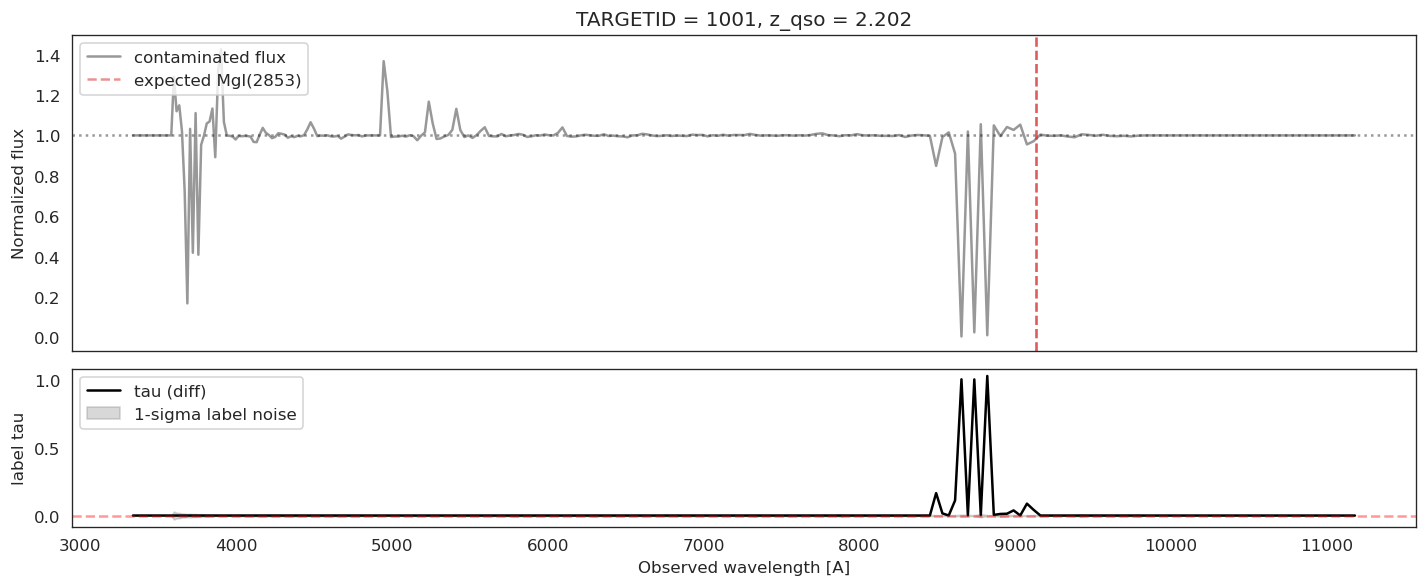

In [23]:
example_tid = common_ids[common_index]
example_sample = build_paired_sample(
    example_tid, uncontaminated_path, contaminated_path,
    spectra_uncontam=spectra_uncontam, spectra_contam=spectra_contam,
)
if example_sample is None:
    raise RuntimeError(
        f"TARGETID {example_tid} has no forest coverage in the fixed rest-frame "
        "window -- pick a different target from common_ids to sanity-check."
    )
 
z_qso_ex = example_sample["z_qso"]
obs_wave_ex = REST_GRID * (1 + z_qso_ex)
label_sigma = np.zeros(N_PIX)
w = example_sample["weight"][0]
label_sigma[w > 0] = 1.0 / np.sqrt(w[w > 0])
 
fig, (axf, axt) = plt.subplots(
    2, 1, figsize=(12, 5), dpi=120, sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5]},
)
axf.plot(obs_wave_ex, example_sample["flux"], color="tab:gray", alpha=0.8, label="contaminated flux")
axf.axhline(1.0, color="k", ls=":", alpha=0.4)
# axf.axvline(1304.37 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected SiII(1304)")
axf.axvline(2852.96 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected MgI(2853)")
axf.set_ylabel("Normalized flux")
axf.set_title(f"TARGETID = {example_tid}, z_qso = {z_qso_ex:.3f}")
axf.legend(loc="upper left")
 
axt.plot(obs_wave_ex, example_sample["label"][0], color="k", label="tau (diff)")
axt.fill_between(obs_wave_ex, -label_sigma, label_sigma, color="tab:gray", alpha=0.3, label="1-sigma label noise")
axt.axhline(0, color="r", ls="--", alpha=0.4)
# axf.axvline(1304.37 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected SiII(1304)")
axf.axvline(2852.96 * (1 + z_qso_ex), color="tab:red", ls="--", alpha=0.5, label="expected MgI(2853)")
axt.set_ylabel("label tau")
axt.set_xlabel("Observed wavelength [A]")
axt.legend(loc="upper left")
plt.tight_layout()
plt.show()

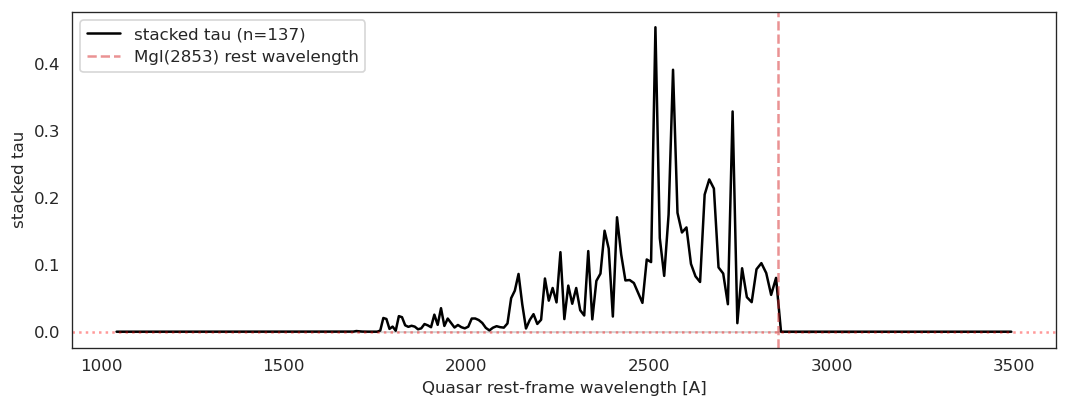

In [24]:

stack_num = np.zeros(N_PIX)
stack_den = np.zeros(N_PIX)
n_stacked = 0
for tid in common_ids[:200]:
    s = build_paired_sample(
        tid, uncontaminated_path, contaminated_path,
        spectra_uncontam=spectra_uncontam, spectra_contam=spectra_contam,
    )
    if s is None:
        continue
    w = s["weight"][0]
    stack_num += s["label"][0] * w
    stack_den += w
    n_stacked += 1
 
stacked_label = np.divide(stack_num, stack_den, out=np.zeros(N_PIX), where=stack_den > 0)
stacked_sigma = np.zeros(N_PIX)
stacked_sigma[stack_den > 0] = 1.0 / np.sqrt(stack_den[stack_den > 0])
 
plt.figure(figsize=(9, 3.5), dpi=120)
plt.plot(REST_GRID, stacked_label, color="k", label=f"stacked tau (n={n_stacked})")
plt.fill_between(REST_GRID, -stacked_sigma, stacked_sigma, color="tab:gray", alpha=0.3)
# plt.axvline(1304.37, color="tab:red", ls="--", alpha=0.5, label="SiII(1304) rest wavelength")
plt.axvline(2852.96, color="tab:red", ls="--", alpha=0.5, label="MgI(2853) rest wavelength")
plt.axhline(0, color="r", ls=":", alpha=0.4)
plt.xlabel("Quasar rest-frame wavelength [A]")
plt.ylabel("stacked tau")
plt.legend()
plt.tight_layout()
plt.show()

### 11.2 Train the model

Uses `train_loader` / `val_loader` (built in section 5b from `samples`) and
the `model` instantiated in section 6/7. Start with a modest number of
epochs -- with this small a network and dataset, overfitting shows up fast
in the train/val loss printout, which is your signal to stop or add
regularization (the `l1_sparsity` term in `masked_weighted_mse`, or fewer
hidden channels) rather than train longer.


In [25]:
model = train(model, train_loader, val_loader, epochs=30, lr=1e-5, device=device)
 
# reload the best checkpoint (train() saves it whenever val loss improves)
model.load_state_dict(torch.load("best_metal_cnn.pt", map_location=device))
model.eval()

final layer gradient: 0.00852636992931366
final layer gradient: 0.006996762007474899
final layer gradient: 0.008424795232713223
final layer gradient: 0.0073495786637067795
raw: -1.3743399381637573 0.054630495607852936 -0.0666971355676651
epoch   0  train 0.02281  val 0.10179
raw: -1.3313323259353638 0.07134806364774704 -0.06307993084192276
epoch   1  train 0.02064  val 0.09616
raw: -0.26567965745925903 -0.0054816873744130135 -0.056981392204761505
epoch   2  train 0.02136  val 0.09062
raw: -1.246882677078247 0.10414012521505356 -0.05217736214399338
epoch   3  train 0.01950  val 0.08498
raw: -0.23941320180892944 -0.00328073906712234 -0.04691518843173981
epoch   4  train 0.01851  val 0.08002
raw: -0.22686663269996643 -0.00021962591563351452 -0.04235038161277771
epoch   5  train 0.01704  val 0.07524
raw: -0.11552868783473969 0.002894872333854437 -0.037811074405908585
epoch   6  train 0.01744  val 0.07047
raw: -0.09030117839574814 0.006638920865952969 -0.033369939774274826
epoch   7  train 

MetalCNN(
  (net): Sequential(
    (0): Conv1d(3, 64, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv1d(64, 1, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)

In [26]:
# Test that matching logic works correctly
sample = val_samples[1]
flux = sample["flux"].astype(np.float32)
z_qso = sample["z_qso"]
true_label = sample["label"]

# Extract true peaks
true_dets = extract_lines_v4(true_label, z_qso, REST_GRID, METAL_LINES)
print(f"True detections: {len(true_dets)}")
for d in true_dets:
    print(f"  pix {d['pixel']:3d}: z={d['z_absorber']:.3f}, τ={d['peak_tau']:.4f}")

# ============ TEST 1: Perfect prediction ============
print("\n" + "="*70)
print("TEST 1: Perfect prediction (copy of true_label)")
print("="*70)
pred_perfect = true_label.copy()
pred_dets = extract_lines_v4(pred_perfect, z_qso, REST_GRID, METAL_LINES)
matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.01)
print(f"Pred detections: {len(pred_dets)}")
print(f"Matched: {len(matched)}, Missed: {len(missed)}, FP: {len(false_pos)}")
if len(matched) == len(true_dets):
    print("✓ Perfect! All peaks matched.")

# ============ TEST 2: Slightly noisy prediction ============
print("\n" + "="*70)
print("TEST 2: Noisy prediction (true_label + 0.01*noise)")
print("="*70)
np.random.seed(42)
pred_noisy = true_label.copy() + 0.01 * np.random.randn(*true_label.shape)
pred_noisy = np.clip(pred_noisy, 0, None)  # Keep non-negative
pred_dets = extract_lines_v4(pred_noisy, z_qso, REST_GRID, METAL_LINES)
matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.01)
print(f"Pred detections: {len(pred_dets)}")
print(f"Matched: {len(matched)}, Missed: {len(missed)}, FP: {len(false_pos)}")

# ============ TEST 3: Shifted prediction ============
print("\n" + "="*70)
print("TEST 3: Shifted prediction (peaks at +2 pixels)")
print("="*70)
pred_shifted = np.roll(true_label, 2, axis=-1)
pred_dets = extract_lines_v4(pred_shifted, z_qso, REST_GRID, METAL_LINES)
matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.01)
print(f"Pred detections: {len(pred_dets)}")
print(f"Matched: {len(matched)}, Missed: {len(missed)}, FP: {len(false_pos)}")

# ============ TEST 4: Actual CNN prediction ============
print("\n" + "="*70)
print("TEST 4: Actual CNN prediction")
print("="*70)
shifted = make_shifted_channels(flux).astype(np.float32)
model.eval()
flux = s["flux"].astype(np.float32)
ivar = s["ivar"].astype(np.float32)
# Normalize inverse variance for use as a CNN input
IVAR_SCALE = 1e7
ivar = ivar / IVAR_SCALE    
x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
x_t = torch.from_numpy(x).unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(x_t)[0].cpu().numpy()

pred_dets = extract_lines_v4(pred, z_qso, REST_GRID, METAL_LINES)
matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.01)
print(f"Pred detections: {len(pred_dets)}")
print(f"Matched: {len(matched)}, Missed: {len(missed)}, FP: {len(false_pos)}")
print(f"\nCNN prediction stats:")
print(f"  min: {pred.min():.6f}")
print(f"  max: {pred.max():.6f}")
print(f"  mean: {pred.mean():.6f}")
print(f"  pixels > 0.01: {(pred > 0.01).sum()}")


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.009856]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 190 195 198 201 207 211]
    Tau values: [0.22499412 0.7916189  1.0098555  0.13202254 0.5950036  0.14295116
 0.6416726 ]
    ✓ Accepted: pix 186, z_abs=2.000, τ=0.2250
    ✓ Accepted: pix 190, z_abs=2.057, τ=0.7916
    ✓ Accepted: pix 195, z_abs=2.131, τ=1.0099
    ✓ Accepted: pix 198, z_abs=2.175, τ=0.1320
    ✓ Accepted: pix 201, z_abs=2.221, τ=0.5950
    ✓ Accepted: pix 207, z_abs=2.314, τ=0.1430
    ✓ Accepted: pix 211, z_abs=2.377, τ=0.6417
True detections: 7
  pix 186: z=2.000, τ=0.2250
  pix 190: z=2.057, τ=0.7916
  pix 195: z=2.131, τ=1.0099
  pix 198: z=2.175, τ=0.1320
  pix 201: z=2.221, τ=0.5950
  pix 207: z=2.314, τ=0.1430
  pix 211: z=2.377, τ=0.6417

TEST 1: Perfect prediction (copy of true_label)

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel:

In [27]:
model.eval()

x, y, w = next(iter(train_loader))

with torch.no_grad():
    raw = model(x)

print("target:")
print("  min:", y.min().item())
print("  max:", y.max().item())
print("  mean:", y.mean().item())
print("  fraction > 0:", (y > 0).float().mean().item())

print("\nraw prediction:")
print("  min:", raw.min().item())
print("  max:", raw.max().item())
print("  mean:", raw.mean().item())
print("  fraction > 0:", (raw > 0).float().mean().item())

target:
  min: 0.0
  max: 1.3862515687942505
  mean: 0.0253845676779747
  fraction > 0: 0.110595703125

raw prediction:
  min: -0.019147979095578194
  max: 0.04859057441353798
  mean: 0.01814325526356697
  fraction > 0: 0.98291015625


### 11.3 Check the output

First a couple of individual spectra with the full plot (predicted vs.
true tau, detected line markers), then aggregate completeness/purity and
strength-recovery stats across the *entire* validation set so you're not
judging performance off one or two cherry-picked examples.


In [28]:
# temp = fitsio.FITS('/pscratch/sd/m/mherbold/tests/metal_CNN_test/QQ_output_test/QQ_output_M-only-preproc/METAL_TEST_MgI-TEMP-1e5/spectra.fits')
# temp['Z_MASK']

True label shape: (1, 256)
True label[0] (MgI) stats:
  min: 0.0
  max: 1.0098555088043213
  mean: 0.018470406532287598
  std: 0.10025819391012192
  n_pixels > 0.01: 22
  n_pixels > 0.1: 11


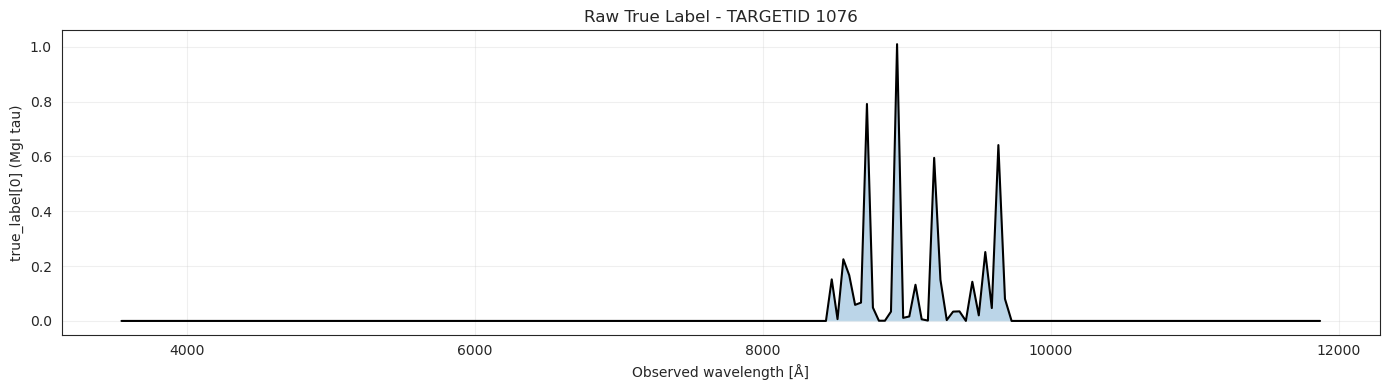


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [-0.011370, 0.044612]
  Noise level: 0.002738
  Raw peaks found: 28
    Pixels: [  2   5   9  13  17  21  24  29  32  35 103 107 114 118 125 128 131 139
 180 184 188 195 199 203 207 211 216 252]
    Tau values: [0.01079573 0.03385432 0.02665608 0.02474556 0.03669466 0.02429002
 0.02411277 0.03196988 0.03923148 0.02864908 0.02893798 0.02356739
 0.03042871 0.01686058 0.02268692 0.01143773 0.02177215 0.02221227
 0.0263206  0.04195882 0.02262068 0.03436562 0.02709324 0.0446119
 0.02619944 0.02718885 0.02959312 0.0228424 ]
    ✓ Accepted: pix 2, z_abs=0.254, τ=0.0108
    ✓ Accepted: pix 5, z_abs=0.272, τ=0.0339
    ✓ Accepted: pix 9, z_abs=0.296, τ=0.0267
    ✓ Accepted: pix 13, z_abs=0.321, τ=0.0247
    ✓ Accepted: pix 17, z_abs=0.346, τ=0.0367
    ✓ Accepted: pix 21, z_abs=0.372, τ=0.0243
    ✓ Accepted: pix 24, z_abs=0.392, τ=0.0241
    ✓ Accepted: 

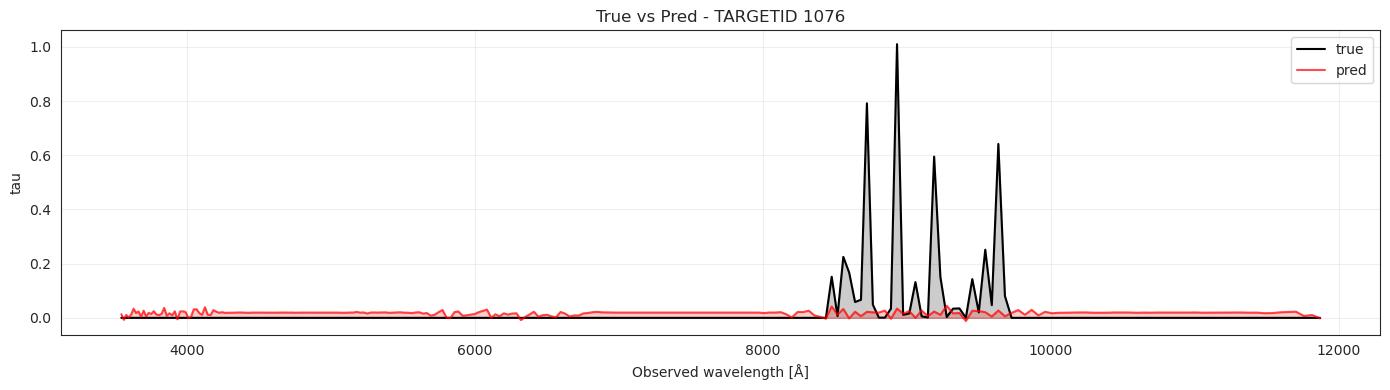

In [29]:
sample = val_samples[1]
true_label = sample["label"]  # (N_METALS, N_PIX)

print("True label shape:", true_label.shape)
print("True label[0] (MgI) stats:")
print(f"  min: {true_label[0].min()}")
print(f"  max: {true_label[0].max()}")
print(f"  mean: {true_label[0].mean()}")
print(f"  std: {true_label[0].std()}")
print(f"  n_pixels > 0.01: {(true_label[0] > 0.01).sum()}")
print(f"  n_pixels > 0.1: {(true_label[0] > 0.1).sum()}")

# Plot raw true label to see what you actually have
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(REST_GRID * (1 + sample["z_qso"]), true_label[0], linewidth=1.5, color="k")
ax.fill_between(REST_GRID * (1 + sample["z_qso"]), 0, true_label[0], alpha=0.3)
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("true_label[0] (MgI tau)")
ax.set_title(f"Raw True Label - TARGETID {sample['targetid']}")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# And check the CNN prediction
shifted = make_shifted_channels(flux).astype(np.float32)
model.eval()
flux = s["flux"].astype(np.float32)
ivar = s["ivar"].astype(np.float32)
# Normalize inverse variance for use as a CNN input
IVAR_SCALE = 1e7
ivar = ivar / IVAR_SCALE    
x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
x_t = torch.from_numpy(x).unsqueeze(0).to(device)
with torch.no_grad():
    pred = model(x_t)[0].cpu().numpy()

pred_dets = extract_lines_v4(pred, z_qso, REST_GRID, METAL_LINES)
matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3, tol_z=0.01)

# x = torch.from_numpy(np.concatenate([
#     sample["flux"][None, :].astype(np.float32),
#     sample["ivar"][None, :].astype(np.float32),
#     make_shifted_channels(sample["flux"].astype(np.float32))
# ], axis=0)).unsqueeze(0).to(device)
# with torch.no_grad():
#     pred = model(x)[0].cpu().numpy()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(REST_GRID * (1 + sample["z_qso"]), true_label[0], linewidth=1.5, color="k", label="true")
ax.plot(REST_GRID * (1 + sample["z_qso"]), pred[0], linewidth=1.5, color="r", label="pred", alpha=0.7)
ax.fill_between(REST_GRID * (1 + sample["z_qso"]), 0, true_label[0], alpha=0.2, color="k")
ax.fill_between(REST_GRID * (1 + sample["z_qso"]), 0, pred[0], alpha=0.2, color="r")
ax.set_xlabel("Observed wavelength [Å]")
ax.set_ylabel("tau")
ax.set_title(f"True vs Pred - TARGETID {sample['targetid']}")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.761757]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [187 190 196 199 203 206 209 212]
    Tau values: [0.46520478 0.3939615  0.76175696 0.03724122 0.10076988 0.03123941
 0.26827705 0.26967525]
    ✓ Accepted: pix 187, z_abs=2.015, τ=0.4652
    ✓ Accepted: pix 190, z_abs=2.058, τ=0.3940
    ✓ Accepted: pix 196, z_abs=2.147, τ=0.7618
    ✓ Accepted: pix 199, z_abs=2.192, τ=0.0372
    ✓ Accepted: pix 203, z_abs=2.253, τ=0.1008
    ✓ Accepted: pix 206, z_abs=2.299, τ=0.0312
    ✓ Accepted: pix 209, z_abs=2.347, τ=0.2683
    ✓ Accepted: pix 212, z_abs=2.395, τ=0.2697

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [-534.568176, 251393.406250]
  Noise level: 28692.051248
  Raw peaks found: 12
    Pixels: [ 39  88 126 130 141 175 181 189

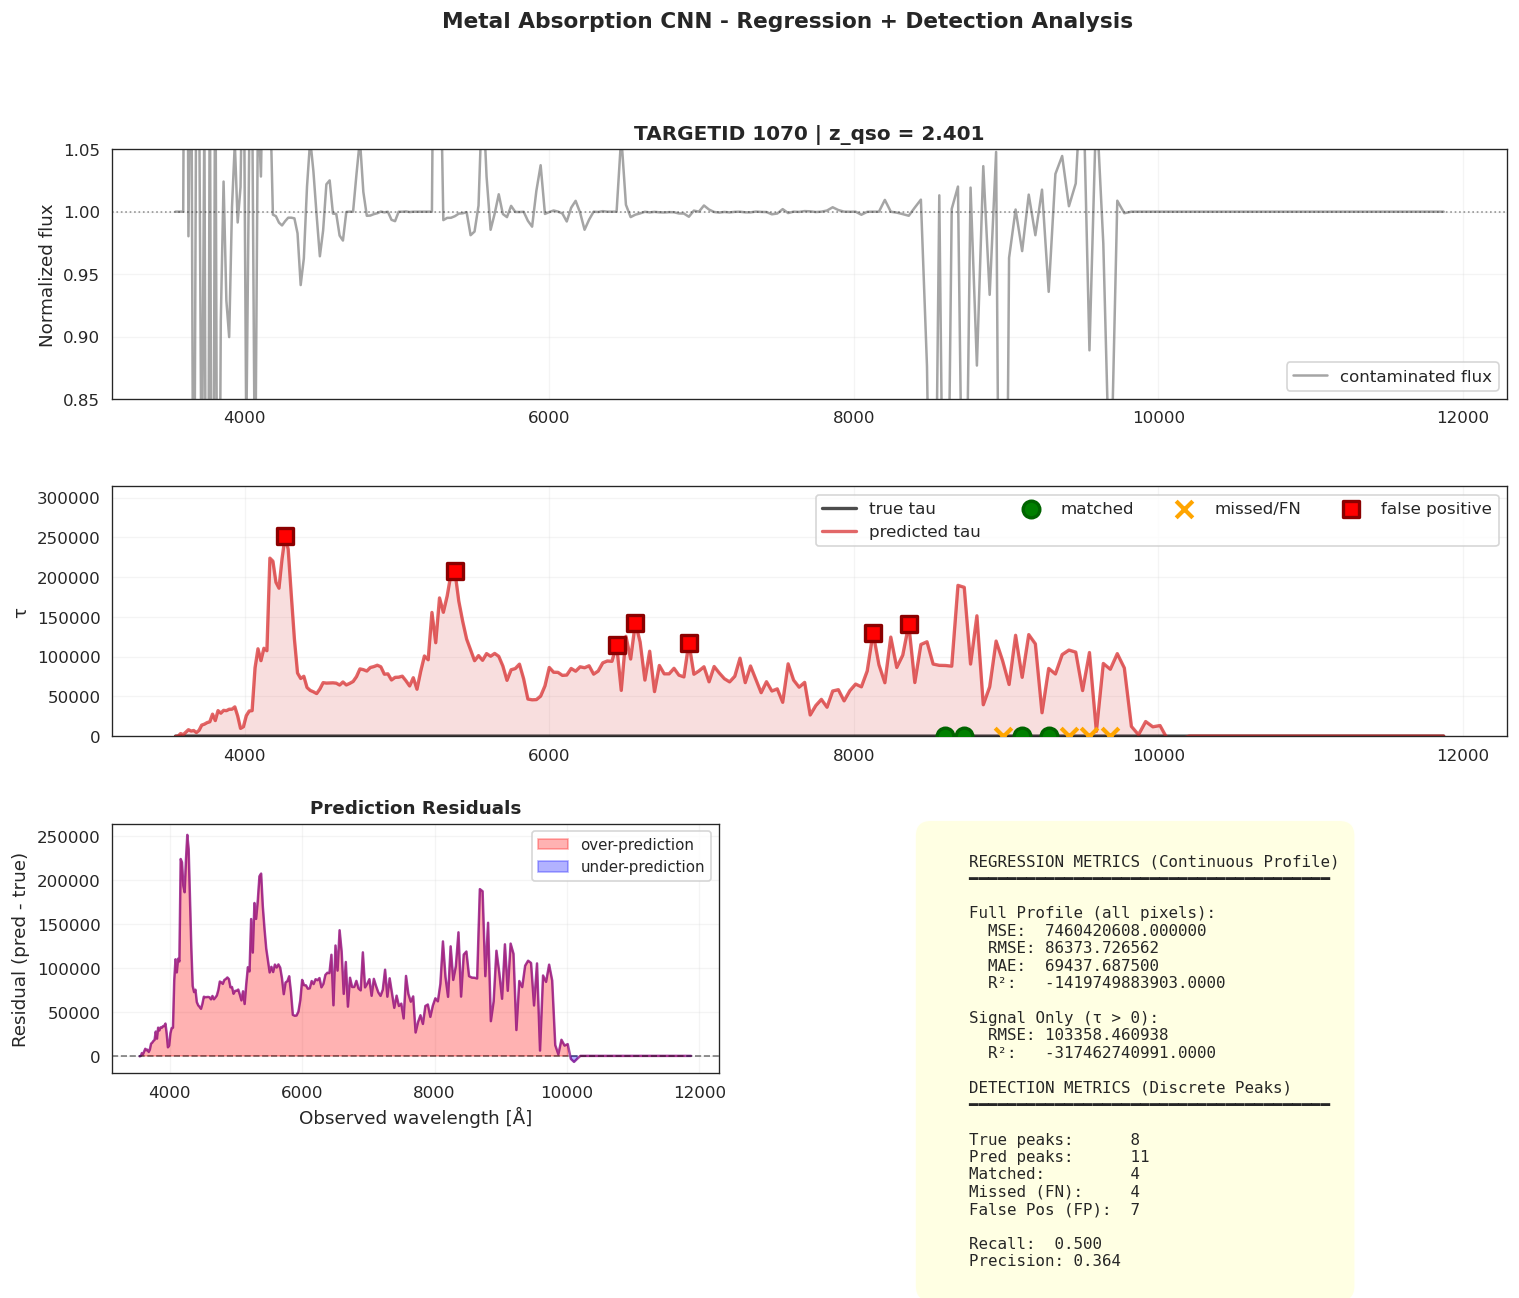


TARGETID 1070 | z_qso = 2.401

REGRESSION METRICS:
  Full profile RMSE: 86373.726562
  Signal-only RMSE:  103358.460938
  R² (full):         -1419749883903.0000
  R² (signal):       -317462740991.0000

DETECTION METRICS:
  True peaks:        8
  Predicted peaks:   11
  Matched:           4
  Missed (FN):       4
  False Positives:   7

  MATCHED PEAKS:
    Peak 1: pix=187 | τ_true=0.4652 → τ_pred=189670.7031 (+189670.2379) | offset=+2pix
    Peak 2: pix=190 | τ_true=0.3940 → τ_pred=151408.5469 (+151408.1529) | offset=+2pix
    Peak 3: pix=199 | τ_true=0.0372 → τ_pred=127715.5859 (+127715.5487) | offset=+1pix
    Peak 4: pix=203 | τ_true=0.1008 → τ_pred=108261.7734 (+108261.6727) | offset=+3pix

  MISSED PEAKS (False Negatives):
    Peak 1: pix=196 | τ=0.7618
    Peak 2: pix=206 | τ=0.0312
    Peak 3: pix=209 | τ=0.2683
    Peak 4: pix=212 | τ=0.2697

  FALSE POSITIVES:
    Peak 1: pix= 39 | τ=251393.4062
    Peak 2: pix= 88 | τ=207356.7344
    Peak 3: pix=126 | τ=115025.8906
    Peak 

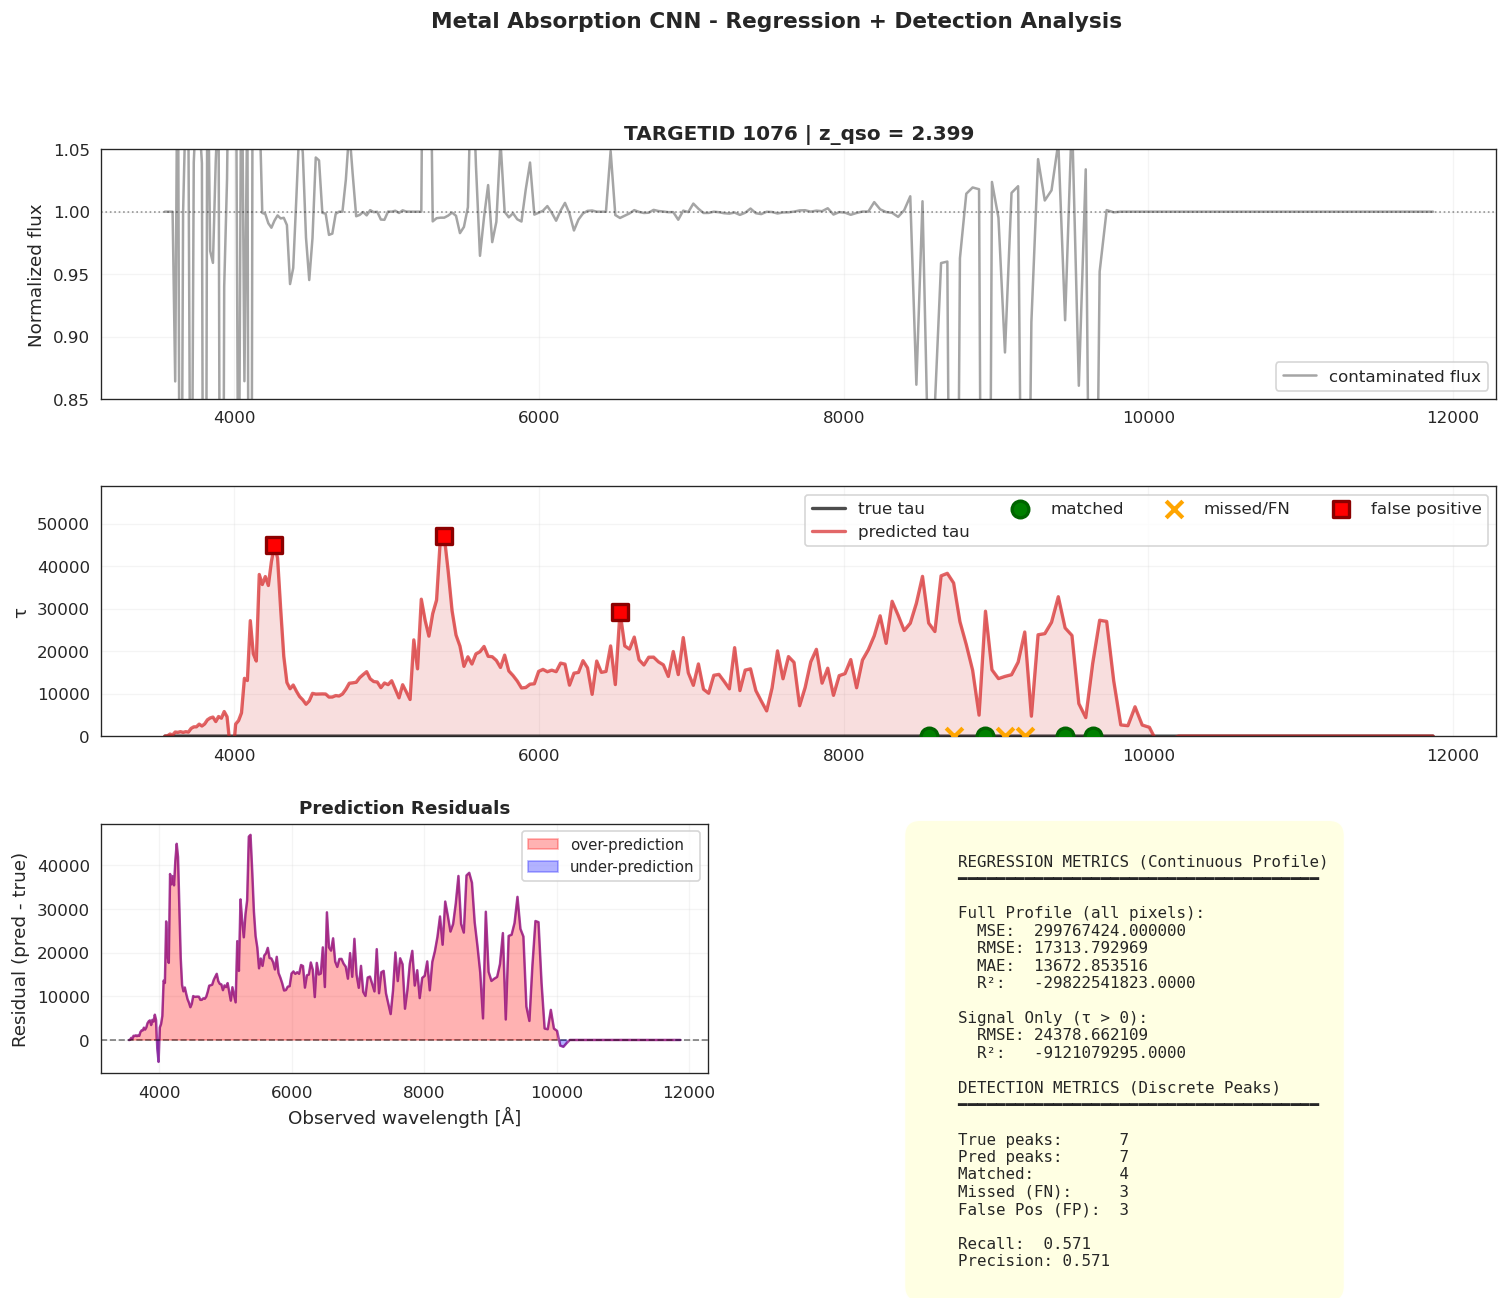


TARGETID 1076 | z_qso = 2.399

REGRESSION METRICS:
  Full profile RMSE: 17313.792969
  Signal-only RMSE:  24378.662109
  R² (full):         -29822541823.0000
  R² (signal):       -9121079295.0000

DETECTION METRICS:
  True peaks:        7
  Predicted peaks:   7
  Matched:           4
  Missed (FN):       3
  False Positives:   3

  MATCHED PEAKS:
    Peak 1: pix=186 | τ_true=0.2250 → τ_pred=38310.1172 (+38309.8922) | offset=+3pix
    Peak 2: pix=195 | τ_true=1.0099 → τ_pred=29396.8711 (+29395.8612) | offset=+0pix
    Peak 3: pix=207 | τ_true=0.1430 → τ_pred=32802.0703 (+32801.9274) | offset=-1pix
    Peak 4: pix=211 | τ_true=0.6417 → τ_pred=27261.0859 (+27260.4443) | offset=+1pix

  MISSED PEAKS (False Negatives):
    Peak 1: pix=190 | τ=0.7916
    Peak 2: pix=198 | τ=0.1320
    Peak 3: pix=201 | τ=0.5950

  FALSE POSITIVES:
    Peak 1: pix= 39 | τ=44965.7578
    Peak 2: pix= 88 | τ=47014.9023
    Peak 3: pix=129 | τ=29261.1055


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 

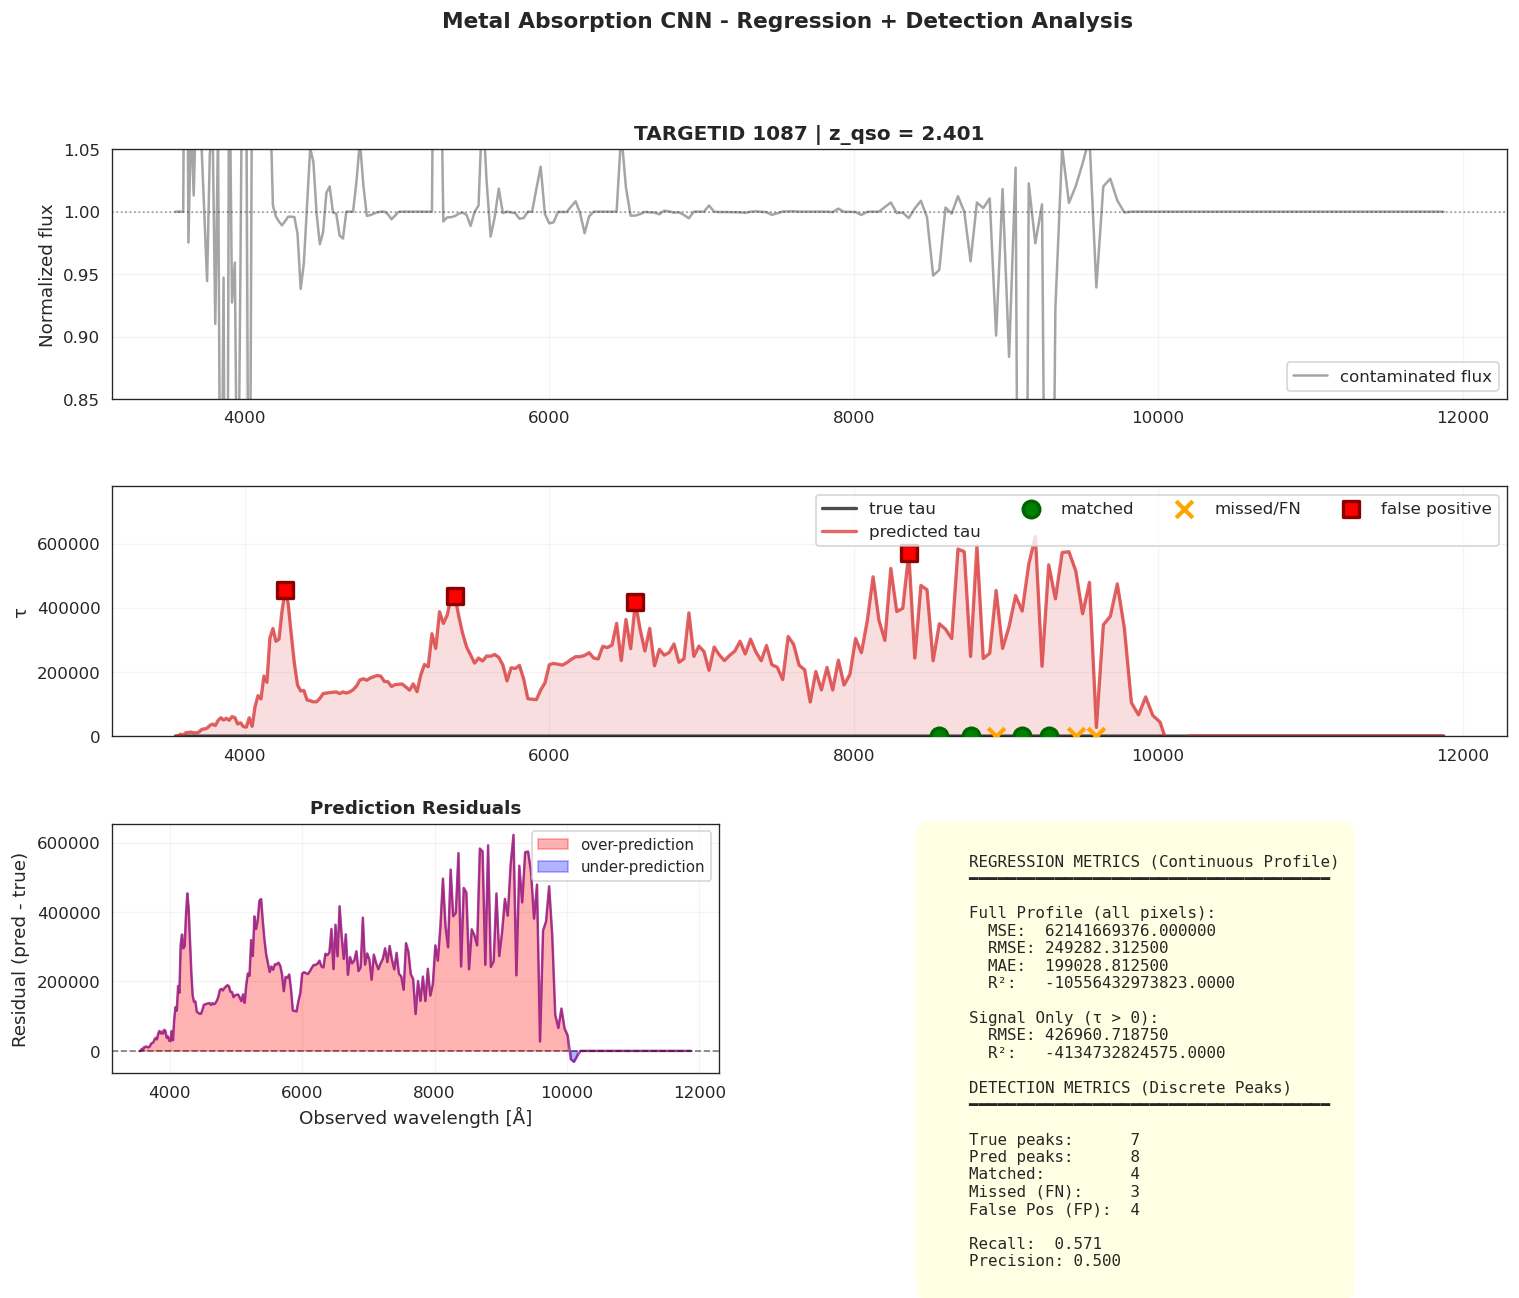


TARGETID 1087 | z_qso = 2.401

REGRESSION METRICS:
  Full profile RMSE: 249282.312500
  Signal-only RMSE:  426960.718750
  R² (full):         -10556432973823.0000
  R² (signal):       -4134732824575.0000

DETECTION METRICS:
  True peaks:        7
  Predicted peaks:   8
  Matched:           4
  Missed (FN):       3
  False Positives:   4

  MATCHED PEAKS:
    Peak 1: pix=186 | τ_true=0.0867 → τ_pred=582927.0625 (+582926.9758) | offset=+3pix
    Peak 2: pix=191 | τ_true=0.0513 → τ_pred=592328.1250 (+592328.0737) | offset=+1pix
    Peak 3: pix=199 | τ_true=0.9817 → τ_pred=622450.5000 (+622449.5183) | offset=+2pix
    Peak 4: pix=203 | τ_true=0.6892 → τ_pred=574493.1875 (+574492.4983) | offset=+3pix

  MISSED PEAKS (False Negatives):
    Peak 1: pix=195 | τ=0.1220
    Peak 2: pix=207 | τ=0.0474
    Peak 3: pix=210 | τ=0.1289

  FALSE POSITIVES:
    Peak 1: pix= 39 | τ=453720.0625
    Peak 2: pix= 88 | τ=437624.4375
    Peak 3: pix=130 | τ=416823.2188
    Peak 4: pix=181 | τ=569931.0625




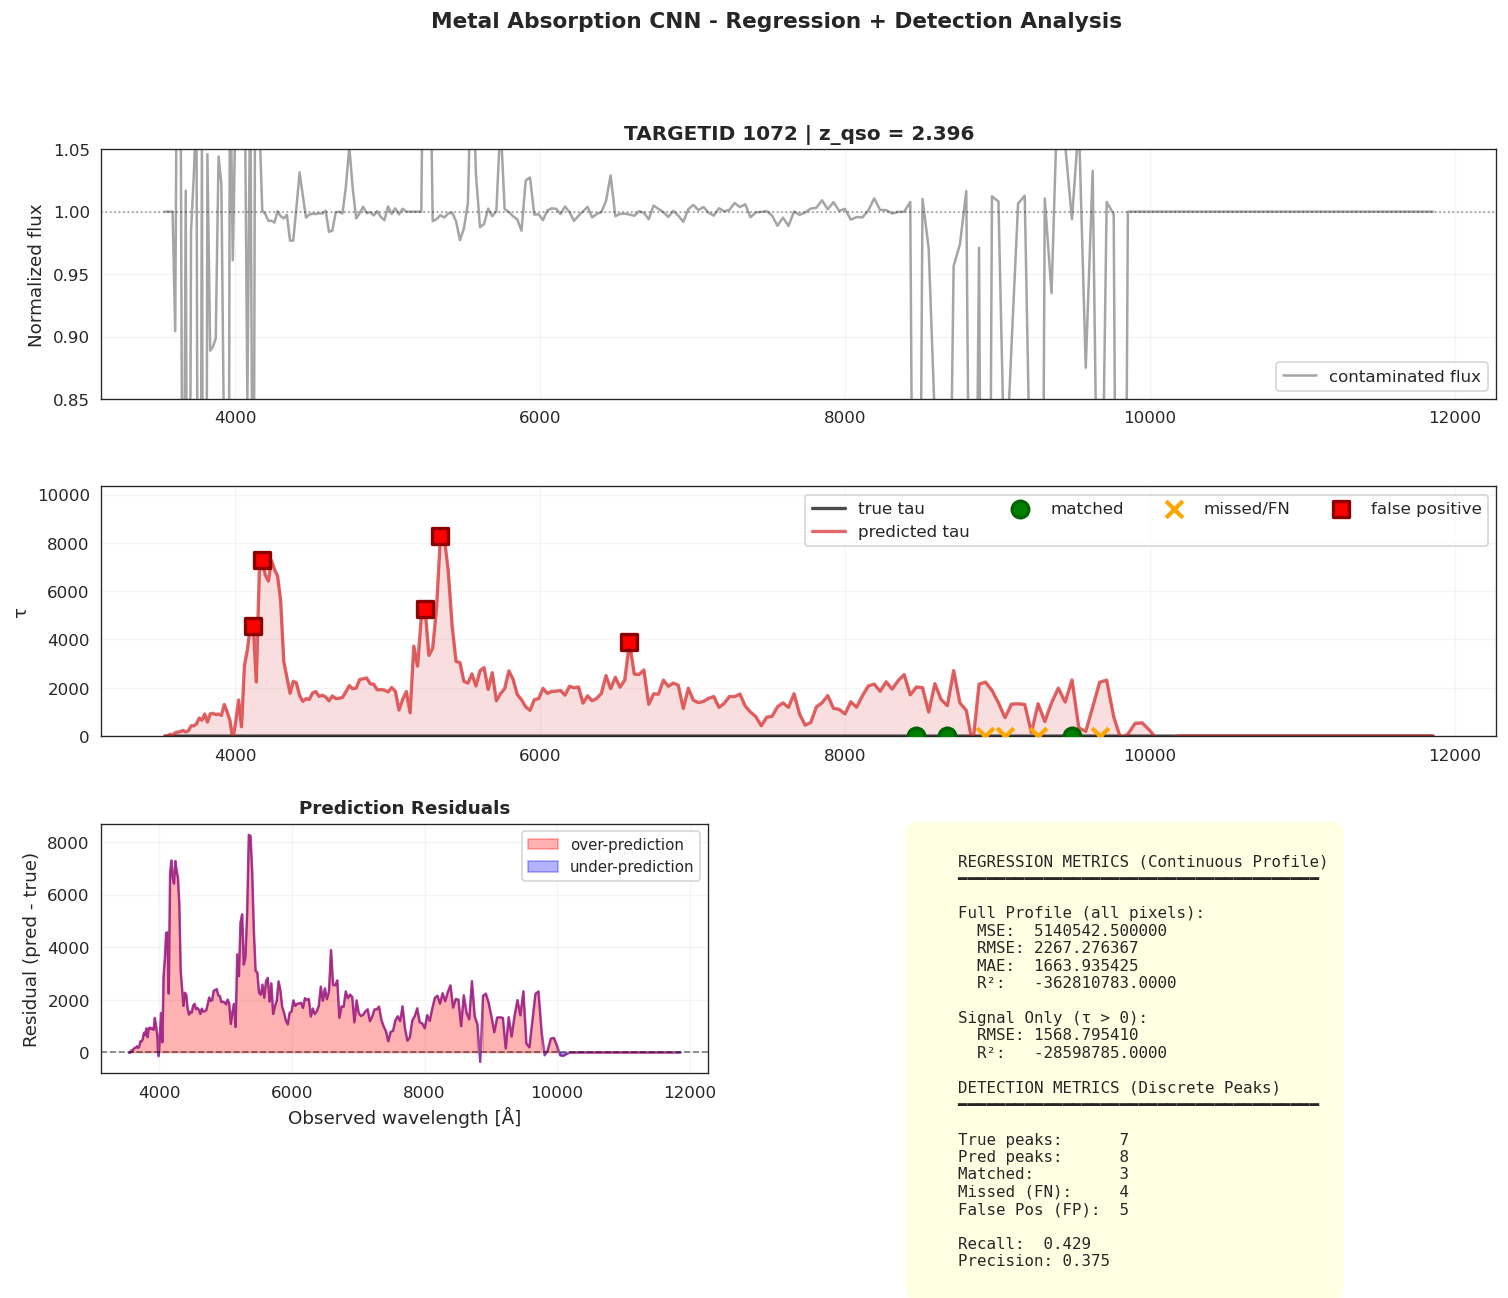


TARGETID 1072 | z_qso = 2.396

REGRESSION METRICS:
  Full profile RMSE: 2267.276367
  Signal-only RMSE:  1568.795410
  R² (full):         -362810783.0000
  R² (signal):       -28598785.0000

DETECTION METRICS:
  True peaks:        7
  Predicted peaks:   8
  Matched:           3
  Missed (FN):       4
  False Positives:   5

  MATCHED PEAKS:
    Peak 1: pix=184 | τ_true=0.7574 → τ_pred=2550.7087 (+2549.9514) | offset=-2pix
    Peak 2: pix=189 | τ_true=0.4511 → τ_pred=2712.6343 (+2712.1831) | offset=+1pix
    Peak 3: pix=208 | τ_true=0.0690 → τ_pred=2327.4648 (+2327.3959) | offset=+0pix

  MISSED PEAKS (False Negatives):
    Peak 1: pix=195 | τ=1.0490
    Peak 2: pix=198 | τ=0.2294
    Peak 3: pix=203 | τ=1.0170
    Peak 4: pix=212 | τ=0.4239

  FALSE POSITIVES:
    Peak 1: pix= 32 | τ=4568.3447
    Peak 2: pix= 35 | τ=7293.8584
    Peak 3: pix= 83 | τ=5250.4058
    Peak 4: pix= 87 | τ=8270.4160
    Peak 5: pix=131 | τ=3890.8438


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 2

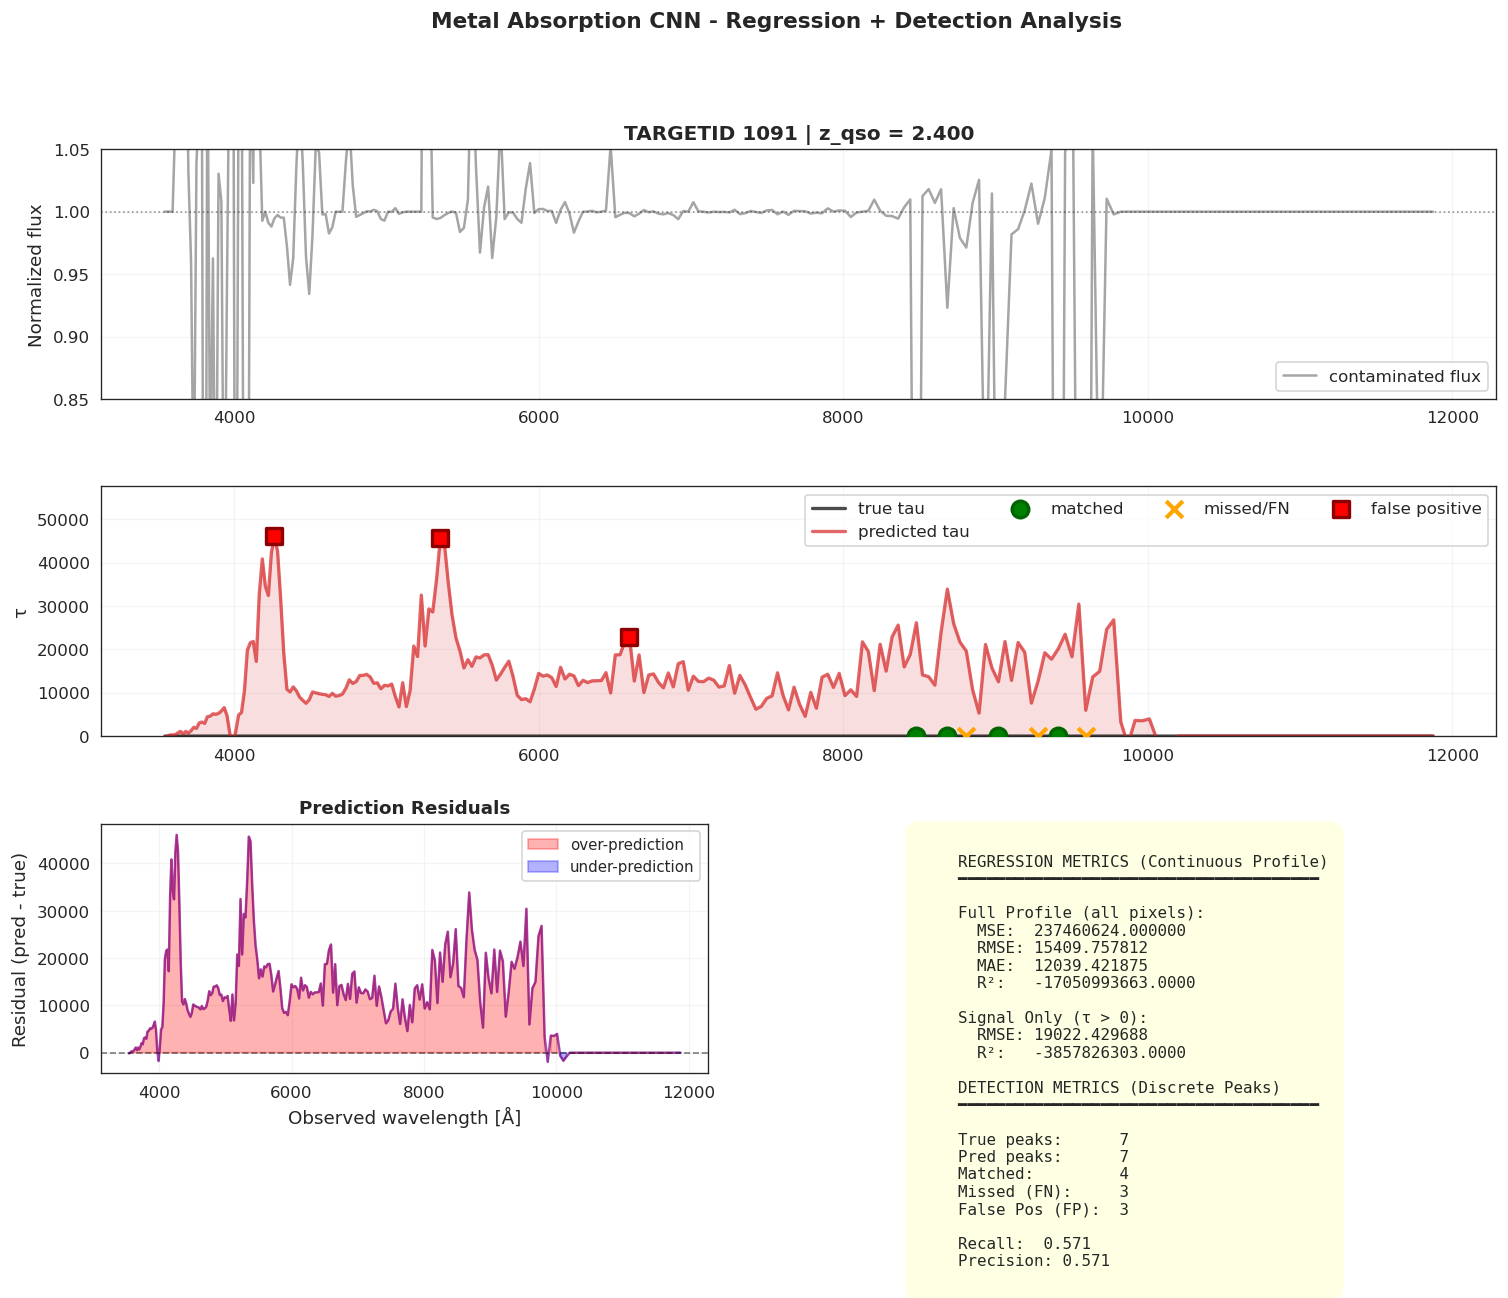


TARGETID 1091 | z_qso = 2.400

REGRESSION METRICS:
  Full profile RMSE: 15409.757812
  Signal-only RMSE:  19022.429688
  R² (full):         -17050993663.0000
  R² (signal):       -3857826303.0000

DETECTION METRICS:
  True peaks:        7
  Predicted peaks:   7
  Matched:           4
  Missed (FN):       3
  False Positives:   3

  MATCHED PEAKS:
    Peak 1: pix=184 | τ_true=0.6815 → τ_pred=26124.8828 (+26124.2014) | offset=+0pix
    Peak 2: pix=189 | τ_true=0.1118 → τ_pred=33866.5195 (+33866.4077) | offset=+0pix
    Peak 3: pix=197 | τ_true=0.4464 → τ_pred=21802.3359 (+21801.8895) | offset=+1pix
    Peak 4: pix=206 | τ_true=1.0504 → τ_pred=30423.9004 (+30422.8500) | offset=+3pix

  MISSED PEAKS (False Negatives):
    Peak 1: pix=192 | τ=0.0436
    Peak 2: pix=203 | τ=0.0416
    Peak 3: pix=210 | τ=1.1002

  FALSE POSITIVES:
    Peak 1: pix= 39 | τ=46038.7266
    Peak 2: pix= 87 | τ=45656.9141
    Peak 3: pix=131 | τ=22869.1055



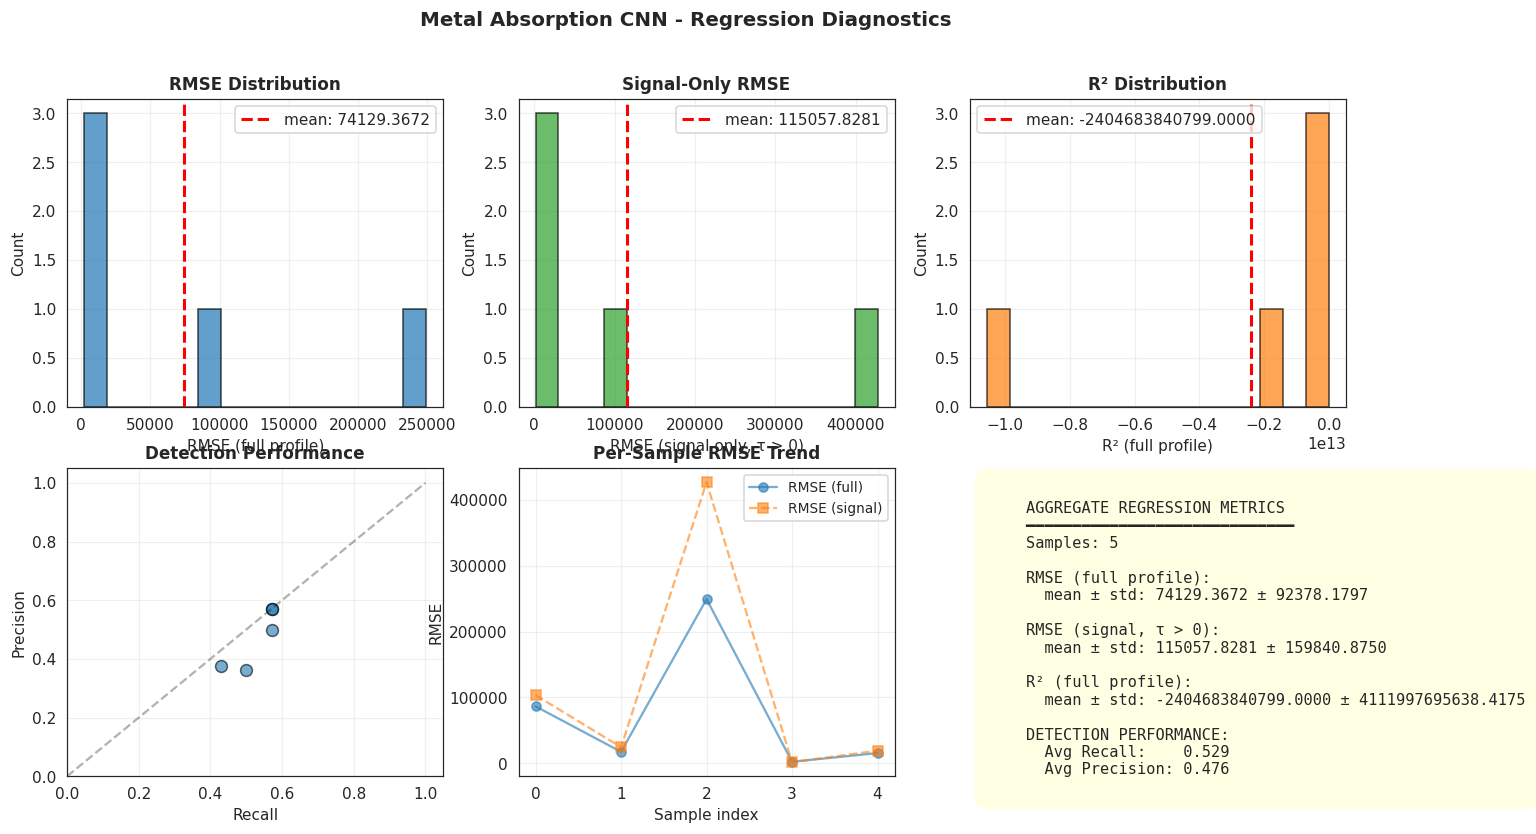

In [31]:
def plot_prediction_vs_truth_regression(model, sample, device="cpu", tol_pix=3, tol_z=0.01):
    """Updated version using robust matching and improved peak extraction."""
    
    model.eval()
    flux = sample["flux"].astype(np.float32)
    ivar = sample["ivar"].astype(np.float32)
    z_qso = sample["z_qso"]
    true_label = sample["label"]
    
    # Generate prediction
    shifted = make_shifted_channels(flux).astype(np.float32)
    x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x_t)[0].cpu().numpy()
    
    obs_wave = REST_GRID * (1 + z_qso)
    
    # ============ Use IMPROVED extraction ============
    true_dets = extract_lines_v4(true_label, z_qso, REST_GRID, METAL_LINES,
                                           min_peak_tau=0.001, distance=3)
    pred_dets = extract_lines_v4(pred, z_qso, REST_GRID, METAL_LINES,
                                           min_peak_tau=0.001, distance=3)
    
    # ============ Use ROBUST matching ============
    matched, missed, false_pos = match_detections_v2(
        true_dets, pred_dets, tol_pix=tol_pix, tol_z=tol_z
    )
    
    # ============ Create comprehensive visualization ============
    fig = plt.figure(figsize=(15, 10), dpi=120)
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    # ============ Panel 1: Flux (top) ============
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(obs_wave, flux, color="tab:gray", alpha=0.7, linewidth=1.5, label="contaminated flux")
    ax1.axhline(1.0, color="k", ls=":", alpha=0.4, linewidth=1)
    ax1.set_ylabel("Normalized flux", fontsize=11)
    ax1.set_title(f"TARGETID {sample['targetid']} | z_qso = {z_qso:.3f}", fontsize=12, weight="bold")
    ax1.set_ylim([0.85, 1.05])
    ax1.legend(loc="lower right", fontsize=10)
    ax1.grid(True, alpha=0.2)
    
    # ============ Panel 2: Full tau profile comparison ============
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(obs_wave, true_label[0], color="k", alpha=0.7, linewidth=2, label="true tau")
    ax2.fill_between(obs_wave, 0, true_label[0], alpha=0.15, color="k")
    ax2.plot(obs_wave, pred[0], color="tab:red", alpha=0.7, linewidth=2, label="predicted tau")
    ax2.fill_between(obs_wave, 0, pred[0], alpha=0.15, color="tab:red")
    
    # Mark matched peaks (GREEN)
    for td, pd in matched:
        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)
        ax2.scatter(obsw, td["peak_tau"], s=100, marker="o", color="green", 
                   edgecolor="darkgreen", linewidth=2, zorder=5, label="matched" if td is matched[0][0] else "")
    
    # Mark missed peaks (ORANGE)
    for td in missed:
        obsw = REST_GRID[td["pixel"]] * (1 + z_qso)
        ax2.scatter(obsw, td["peak_tau"], s=100, marker="x", color="orange", 
                   linewidth=2.5, zorder=5, label="missed/FN" if td is missed[0] else "")
    
    # Mark false positives (RED)
    for pd in false_pos:
        obsw = REST_GRID[pd["pixel"]] * (1 + z_qso)
        ax2.scatter(obsw, pd["peak_tau"], s=100, marker="s", color="red", 
                   edgecolor="darkred", linewidth=2, zorder=5, label="false positive" if pd is false_pos[0] else "")
    
    ax2.set_ylabel("τ", fontsize=11)
    ax2.set_ylim([0, max(true_label[0].max(), pred[0].max()) * 1.25])
    ax2.legend(loc="upper right", fontsize=10, ncol=4)
    ax2.grid(True, alpha=0.2)
    
    # ============ Panel 3: Residuals (pred - true) ============
    ax3 = fig.add_subplot(gs[2, 0])
    residual = pred[0] - true_label[0]
    ax3.plot(obs_wave, residual, color="purple", alpha=0.7, linewidth=1.5)
    ax3.fill_between(obs_wave, 0, residual, where=(residual > 0), alpha=0.3, 
                     color="red", label="over-prediction")
    ax3.fill_between(obs_wave, 0, residual, where=(residual <= 0), alpha=0.3, 
                     color="blue", label="under-prediction")
    ax3.axhline(0, color="k", ls="--", alpha=0.5, linewidth=1)
    ax3.set_ylabel("Residual (pred - true)", fontsize=11)
    ax3.set_xlabel("Observed wavelength [Å]", fontsize=11)
    ax3.set_title("Prediction Residuals", fontsize=11, weight="bold")
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.2)
    
    # ============ Panel 4: Profile-level metrics ============
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.axis("off")
    
    # Compute regression metrics
    mse = np.mean((pred[0] - true_label[0])**2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(pred[0] - true_label[0]))
    r2 = 1 - (np.sum((pred[0] - true_label[0])**2) / np.sum((true_label[0] - true_label[0].mean())**2))
    
    # Only where tau > 0
    mask = true_label[0] > 0
    if mask.sum() > 0:
        mse_signal = np.mean((pred[0][mask] - true_label[0][mask])**2)
        rmse_signal = np.sqrt(mse_signal)
        r2_signal = 1 - (np.sum((pred[0][mask] - true_label[0][mask])**2) / 
                         np.sum((true_label[0][mask] - true_label[0][mask].mean())**2))
    else:
        mse_signal = rmse_signal = r2_signal = np.nan
    
    summary_text = f"""
    REGRESSION METRICS (Continuous Profile)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    
    Full Profile (all pixels):
      MSE:  {mse:.6f}
      RMSE: {rmse:.6f}
      MAE:  {mae:.6f}
      R²:   {r2:.4f}
    
    Signal Only (τ > 0):
      RMSE: {rmse_signal:.6f}
      R²:   {r2_signal:.4f}
    
    DETECTION METRICS (Discrete Peaks)
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    
    True peaks:      {len(true_dets)}
    Pred peaks:      {len(pred_dets)}
    Matched:         {len(matched)}
    Missed (FN):     {len(missed)}
    False Pos (FP):  {len(false_pos)}
    
    Recall:  {len(matched) / max(len(true_dets), 1):.3f}
    Precision: {len(matched) / max(len(pred_dets), 1):.3f}
    """
    
    ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
            fontsize=9.5, verticalalignment="top", family="monospace",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9, pad=1))
    
    fig.suptitle(f"Metal Absorption CNN - Regression + Detection Analysis", 
                fontsize=13, weight="bold", y=0.995)
    # plt.tight_layout()
    plt.show()
    
    # ============ Print detailed diagnostics ============
    print("\n" + "="*70)
    print(f"TARGETID {sample['targetid']} | z_qso = {z_qso:.3f}")
    print("="*70)
    print(f"\nREGRESSION METRICS:")
    print(f"  Full profile RMSE: {rmse:.6f}")
    print(f"  Signal-only RMSE:  {rmse_signal:.6f}")
    print(f"  R² (full):         {r2:.4f}")
    print(f"  R² (signal):       {r2_signal:.4f}")
    
    print(f"\nDETECTION METRICS:")
    print(f"  True peaks:        {len(true_dets)}")
    print(f"  Predicted peaks:   {len(pred_dets)}")
    print(f"  Matched:           {len(matched)}")
    print(f"  Missed (FN):       {len(missed)}")
    print(f"  False Positives:   {len(false_pos)}")
    
    if matched:
        print(f"\n  MATCHED PEAKS:")
        for i, (td, pd) in enumerate(matched):
            pix_offset = pd["pixel"] - td["pixel"]
            tau_err = pd["peak_tau"] - td["peak_tau"]
            print(f"    Peak {i+1}: pix={td['pixel']:3d} | τ_true={td['peak_tau']:.4f} → "
                  f"τ_pred={pd['peak_tau']:.4f} ({tau_err:+.4f}) | offset={pix_offset:+d}pix")
    
    if missed:
        print(f"\n  MISSED PEAKS (False Negatives):")
        for i, td in enumerate(missed):
            print(f"    Peak {i+1}: pix={td['pixel']:3d} | τ={td['peak_tau']:.4f}")
    
    if false_pos:
        print(f"\n  FALSE POSITIVES:")
        for i, pd in enumerate(false_pos):
            print(f"    Peak {i+1}: pix={pd['pixel']:3d} | τ={pd['peak_tau']:.4f}")
    
    print("="*70 + "\n")
    
    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "rmse_signal": rmse_signal,
        "r2_signal": r2_signal,
        "matched": matched,
        "missed": missed,
        "false_pos": false_pos,
        "true_dets": true_dets,
        "pred_dets": pred_dets,
    }


def plot_regression_diagnostics(all_results):
    """
    Aggregate regression metrics across multiple samples.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=110)
    axes = axes.flatten()
    
    rmses = [r["rmse"] for r in all_results]
    rmses_signal = [r["rmse_signal"] for r in all_results]
    r2s = [r["r2"] for r in all_results]
    r2s_signal = [r["r2_signal"] for r in all_results]
    recalls = [len(r["matched"]) / max(len(r["true_dets"]), 1) for r in all_results]
    precisions = [len(r["matched"]) / max(len(r["pred_dets"]), 1) for r in all_results]
    
    # Plot 1: RMSE distribution
    axes[0].hist(rmses, bins=15, alpha=0.7, color="tab:blue", edgecolor="k")
    axes[0].axvline(np.mean(rmses), color="r", ls="--", linewidth=2, label=f"mean: {np.mean(rmses):.4f}")
    axes[0].set_xlabel("RMSE (full profile)", fontsize=10)
    axes[0].set_ylabel("Count", fontsize=10)
    axes[0].set_title("RMSE Distribution", fontsize=11, weight="bold")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Signal-only RMSE
    axes[1].hist(rmses_signal, bins=15, alpha=0.7, color="tab:green", edgecolor="k")
    axes[1].axvline(np.nanmean(rmses_signal), color="r", ls="--", linewidth=2, 
                    label=f"mean: {np.nanmean(rmses_signal):.4f}")
    axes[1].set_xlabel("RMSE (signal only, τ > 0)", fontsize=10)
    axes[1].set_ylabel("Count", fontsize=10)
    axes[1].set_title("Signal-Only RMSE", fontsize=11, weight="bold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Plot 3: R² distribution
    axes[2].hist(r2s, bins=15, alpha=0.7, color="tab:orange", edgecolor="k")
    axes[2].axvline(np.mean(r2s), color="r", ls="--", linewidth=2, label=f"mean: {np.mean(r2s):.4f}")
    axes[2].set_xlabel("R² (full profile)", fontsize=10)
    axes[2].set_ylabel("Count", fontsize=10)
    axes[2].set_title("R² Distribution", fontsize=11, weight="bold")
    axes[2].legend()
    axes[2].grid(alpha=0.3)
    
    # Plot 4: Recall vs Precision scatter
    axes[3].scatter(recalls, precisions, s=60, alpha=0.6, edgecolors="k")
    axes[3].set_xlabel("Recall", fontsize=10)
    axes[3].set_ylabel("Precision", fontsize=10)
    axes[3].set_title("Detection Performance", fontsize=11, weight="bold")
    axes[3].set_xlim([0, 1.05])
    axes[3].set_ylim([0, 1.05])
    axes[3].grid(alpha=0.3)
    axes[3].plot([0, 1], [0, 1], "k--", alpha=0.3)
    
    # Plot 5: Per-sample metrics
    x_pos = np.arange(len(all_results))
    axes[4].plot(x_pos, rmses, "o-", alpha=0.6, label="RMSE (full)", linewidth=1.5)
    axes[4].plot(x_pos, rmses_signal, "s--", alpha=0.6, label="RMSE (signal)", linewidth=1.5)
    axes[4].set_xlabel("Sample index", fontsize=10)
    axes[4].set_ylabel("RMSE", fontsize=10)
    axes[4].set_title("Per-Sample RMSE Trend", fontsize=11, weight="bold")
    axes[4].legend(fontsize=9)
    axes[4].grid(alpha=0.3)
    
    # Plot 6: Summary statistics
    axes[5].axis("off")
    summary = f"""
    AGGREGATE REGRESSION METRICS
    ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Samples: {len(all_results)}
    
    RMSE (full profile):
      mean ± std: {np.mean(rmses):.4f} ± {np.std(rmses):.4f}
      
    RMSE (signal, τ > 0):
      mean ± std: {np.nanmean(rmses_signal):.4f} ± {np.nanstd(rmses_signal):.4f}
      
    R² (full profile):
      mean ± std: {np.mean(r2s):.4f} ± {np.std(r2s):.4f}
      
    DETECTION PERFORMANCE:
      Avg Recall:    {np.mean(recalls):.3f}
      Avg Precision: {np.mean(precisions):.3f}
    """
    axes[5].text(0.05, 0.95, summary, transform=axes[5].transAxes,
                fontsize=10, verticalalignment="top", family="monospace",
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.9, pad=1))
    
    plt.suptitle("Metal Absorption CNN - Regression Diagnostics", fontsize=13, weight="bold")
    # plt.tight_layout()
    plt.show()


# ============ USAGE ============
all_results = []
for i in range(min(5, len(val_samples))):
    result = plot_prediction_vs_truth_regression(model, val_samples[i], device=device, tol_pix=3)
    all_results.append(result)

plot_regression_diagnostics(all_results)

In [97]:
all_results = []
for i in range(min(10, len(val_samples))):  # Evaluate first 10 val samples
    print(f"\n\nSample {i}:")
    result = plot_prediction_vs_truth_verbose(model, val_samples[i], device=device, tol_pix=3)
    all_results.append(result)

# Compute aggregate metrics
metrics = compute_detection_metrics(all_results)
print("\n" + "="*60)
print("AGGREGATE METRICS")
print("="*60)
for key, val in metrics.items():
    print(f"{key:25s}: {val}")
    
# Create comprehensive diagnostic plot
plot_ml_diagnostics(all_results, title="Metal Absorption CNN - Model Diagnostics")



Sample 0:

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.761757]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [187 190 196 199 203 206 209 212]
    Tau values: [0.46520478 0.3939615  0.76175696 0.03724122 0.10076988 0.03123941
 0.26827705 0.26967525]
    ✓ Accepted: pix 187, z_abs=2.015, τ=0.4652
    ✓ Accepted: pix 190, z_abs=2.058, τ=0.3940
    ✓ Accepted: pix 196, z_abs=2.147, τ=0.7618
    ✓ Accepted: pix 199, z_abs=2.192, τ=0.0372
    ✓ Accepted: pix 203, z_abs=2.253, τ=0.1008
    ✓ Accepted: pix 206, z_abs=2.299, τ=0.0312
    ✓ Accepted: pix 209, z_abs=2.347, τ=0.2683
    ✓ Accepted: pix 212, z_abs=2.395, τ=0.2697

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.063944, 0.126953]
  Noise level: 0.002579
  Raw peaks found: 24
    Pixels: [  2   6  13  17  25  29  32  37

NameError: name 'match_detections' is not defined


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.761757]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [187 190 196 199 203 206 209 212]
    Tau values: [0.46520478 0.3939615  0.76175696 0.03724122 0.10076988 0.03123941
 0.26827705 0.26967525]
    ✓ Accepted: pix 187, z_abs=2.015, τ=0.4652
    ✓ Accepted: pix 190, z_abs=2.058, τ=0.3940
    ✓ Accepted: pix 196, z_abs=2.147, τ=0.7618
    ✓ Accepted: pix 199, z_abs=2.192, τ=0.0372
    ✓ Accepted: pix 203, z_abs=2.253, τ=0.1008
    ✓ Accepted: pix 206, z_abs=2.299, τ=0.0312
    ✓ Accepted: pix 209, z_abs=2.347, τ=0.2683
    ✓ Accepted: pix 212, z_abs=2.395, τ=0.2697

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.067320, 0.117806]
  Noise level: 0.002775
  Raw peaks found: 18
    Pixels: [  7  12  16  19  31  45  81 159 174 177 180

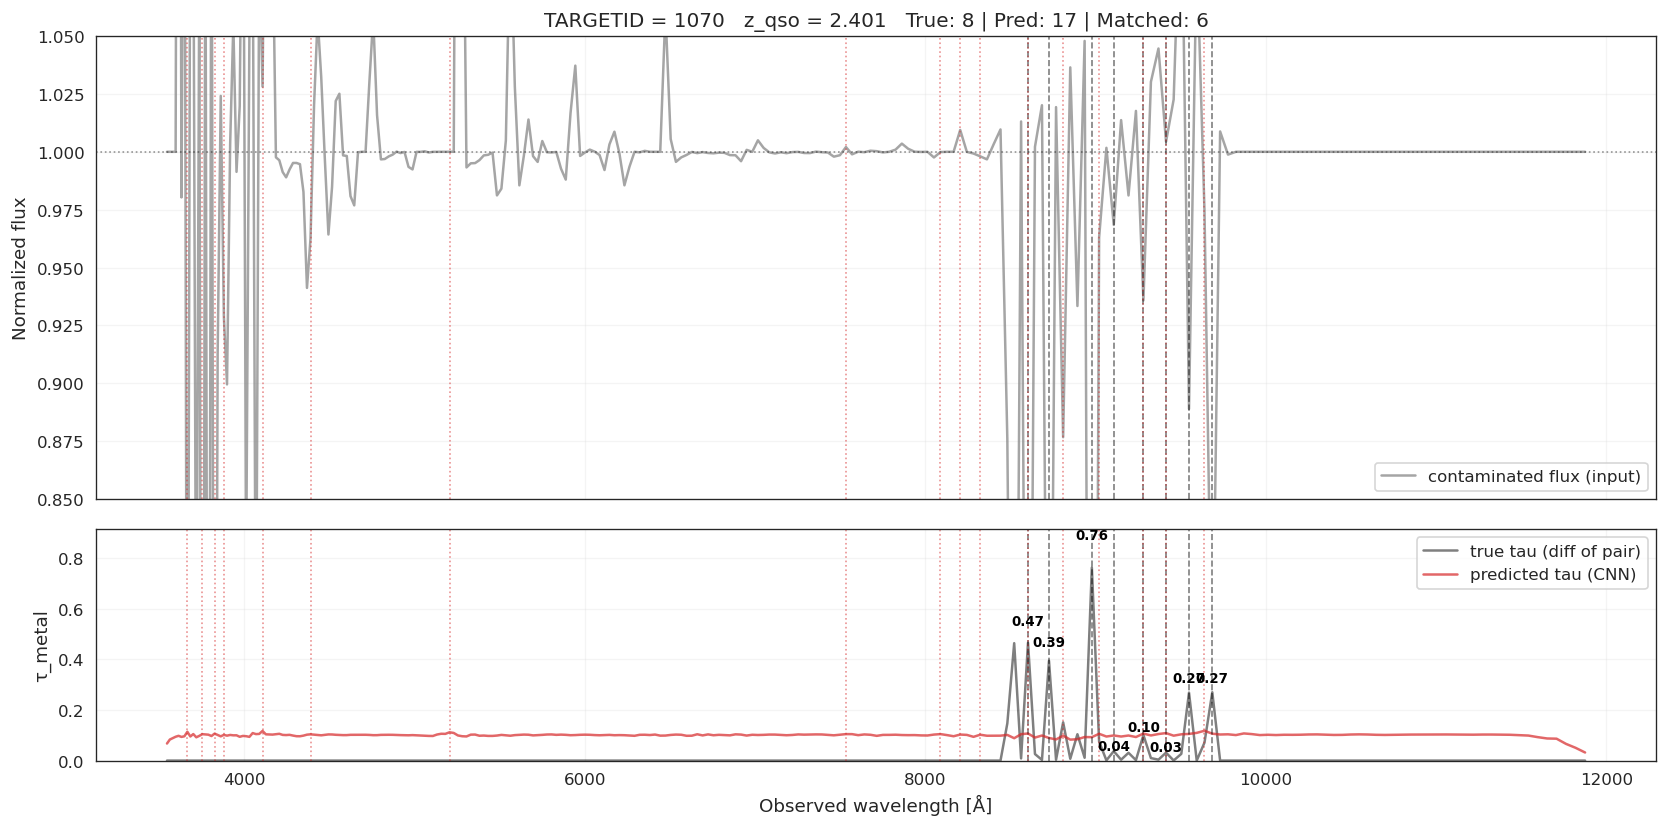


TARGETID 1070 | z_qso = 2.401
true detections:  8
pred detections:  17
matched:          6
missed (FN):      2
false positives:  11

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=2.015 | τ_true=0.4652 → τ_pred=0.1069 | pix_offset=+0
  MgI(2853)      : z=2.058 | τ_true=0.3940 → τ_pred=0.0983 | pix_offset=+2
  MgI(2853)      : z=2.147 | τ_true=0.7618 → τ_pred=0.1058 | pix_offset=+1
  MgI(2853)      : z=2.192 | τ_true=0.0372 → τ_pred=0.1066 | pix_offset=+4
  MgI(2853)      : z=2.253 | τ_true=0.1008 → τ_pred=0.1086 | pix_offset=+3
  MgI(2853)      : z=2.299 | τ_true=0.0312 → τ_pred=0.1178 | pix_offset=+5

Strength recovery (integrated tau):
  bias:    -0.5961
  scatter: 5.1583
  RMSE:    5.1926


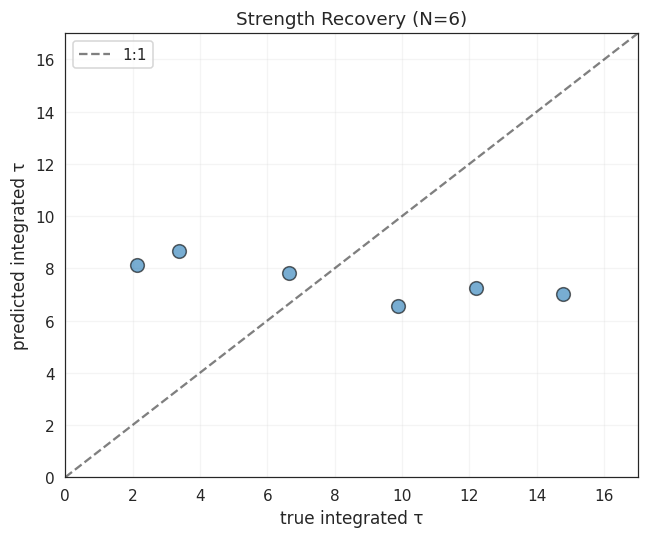


--- MISSED DETECTIONS (False Negatives) ---
  MgI(2853)      : z=2.347 | τ=0.2683 | pix=209
  MgI(2853)      : z=2.395 | τ=0.2697 | pix=212

--- FALSE POSITIVES ---
  MgI(2853)      : z=0.285 | τ=0.1138 | pix=7
  MgI(2853)      : z=0.315 | τ=0.1043 | pix=12
  MgI(2853)      : z=0.341 | τ=0.1064 | pix=16
  MgI(2853)      : z=0.360 | τ=0.1016 | pix=19
  MgI(2853)      : z=0.439 | τ=0.1170 | pix=31
  MgI(2853)      : z=0.538 | τ=0.1036 | pix=45
  MgI(2853)      : z=0.824 | τ=0.1117 | pix=81
  MgI(2853)      : z=1.640 | τ=0.1045 | pix=159
  MgI(2853)      : z=1.835 | τ=0.1045 | pix=174
  MgI(2853)      : z=1.876 | τ=0.1028 | pix=177
  MgI(2853)      : z=1.917 | τ=0.1021 | pix=180


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.009856]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 190 195 198 201 207 211]
    Tau values: [0.22499412 0.7916189  1.0098555  0.13202254 0.5

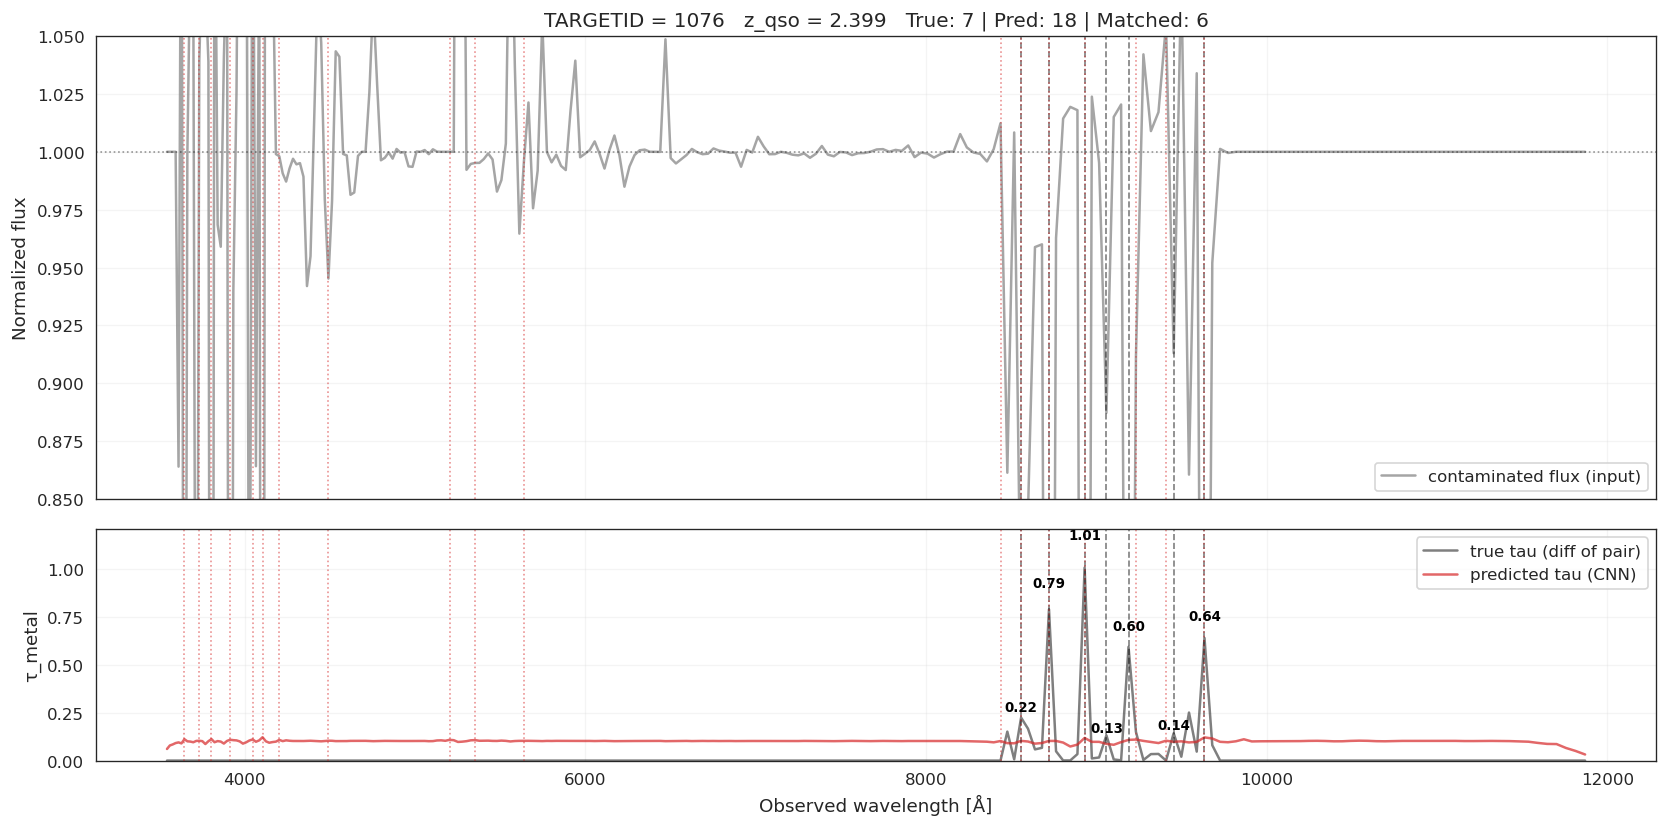


TARGETID 1076 | z_qso = 2.399
true detections:  7
pred detections:  18
matched:          6
missed (FN):      1
false positives:  12

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=2.000 | τ_true=0.2250 → τ_pred=0.1032 | pix_offset=+0
  MgI(2853)      : z=2.057 | τ_true=0.7916 → τ_pred=0.1029 | pix_offset=+0
  MgI(2853)      : z=2.131 | τ_true=1.0099 → τ_pred=0.1184 | pix_offset=+0
  MgI(2853)      : z=2.175 | τ_true=0.1320 → τ_pred=0.1100 | pix_offset=+4
  MgI(2853)      : z=2.221 | τ_true=0.5950 → τ_pred=0.1040 | pix_offset=+5
  MgI(2853)      : z=2.314 | τ_true=0.1430 → τ_pred=0.1214 | pix_offset=+4

Strength recovery (integrated tau):
  bias:    -3.2329
  scatter: 3.0621
  RMSE:    4.4529


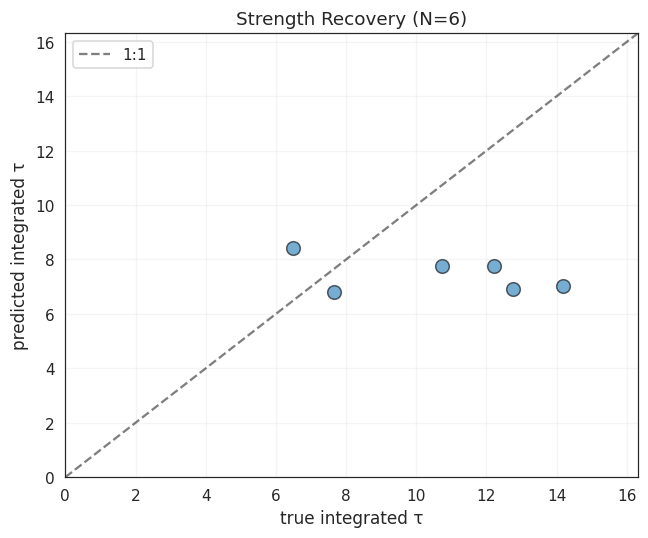


--- MISSED DETECTIONS (False Negatives) ---
  MgI(2853)      : z=2.377 | τ=0.6417 | pix=211

--- FALSE POSITIVES ---
  MgI(2853)      : z=0.278 | τ=0.1120 | pix=6
  MgI(2853)      : z=0.309 | τ=0.1037 | pix=11
  MgI(2853)      : z=0.334 | τ=0.1125 | pix=15
  MgI(2853)      : z=0.372 | τ=0.1090 | pix=21
  MgI(2853)      : z=0.418 | τ=0.1108 | pix=28
  MgI(2853)      : z=0.439 | τ=0.1222 | pix=31
  MgI(2853)      : z=0.473 | τ=0.1083 | pix=36
  MgI(2853)      : z=0.574 | τ=0.1040 | pix=50
  MgI(2853)      : z=0.824 | τ=0.1086 | pix=81
  MgI(2853)      : z=0.876 | τ=0.1071 | pix=87
  MgI(2853)      : z=0.977 | τ=0.1035 | pix=98
  MgI(2853)      : z=1.957 | τ=0.1024 | pix=183


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.981665]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 191 195 199 203 207 210]
    Tau values: [0.08666504 0.05129827 0.12204942 0.98166543 0.68923

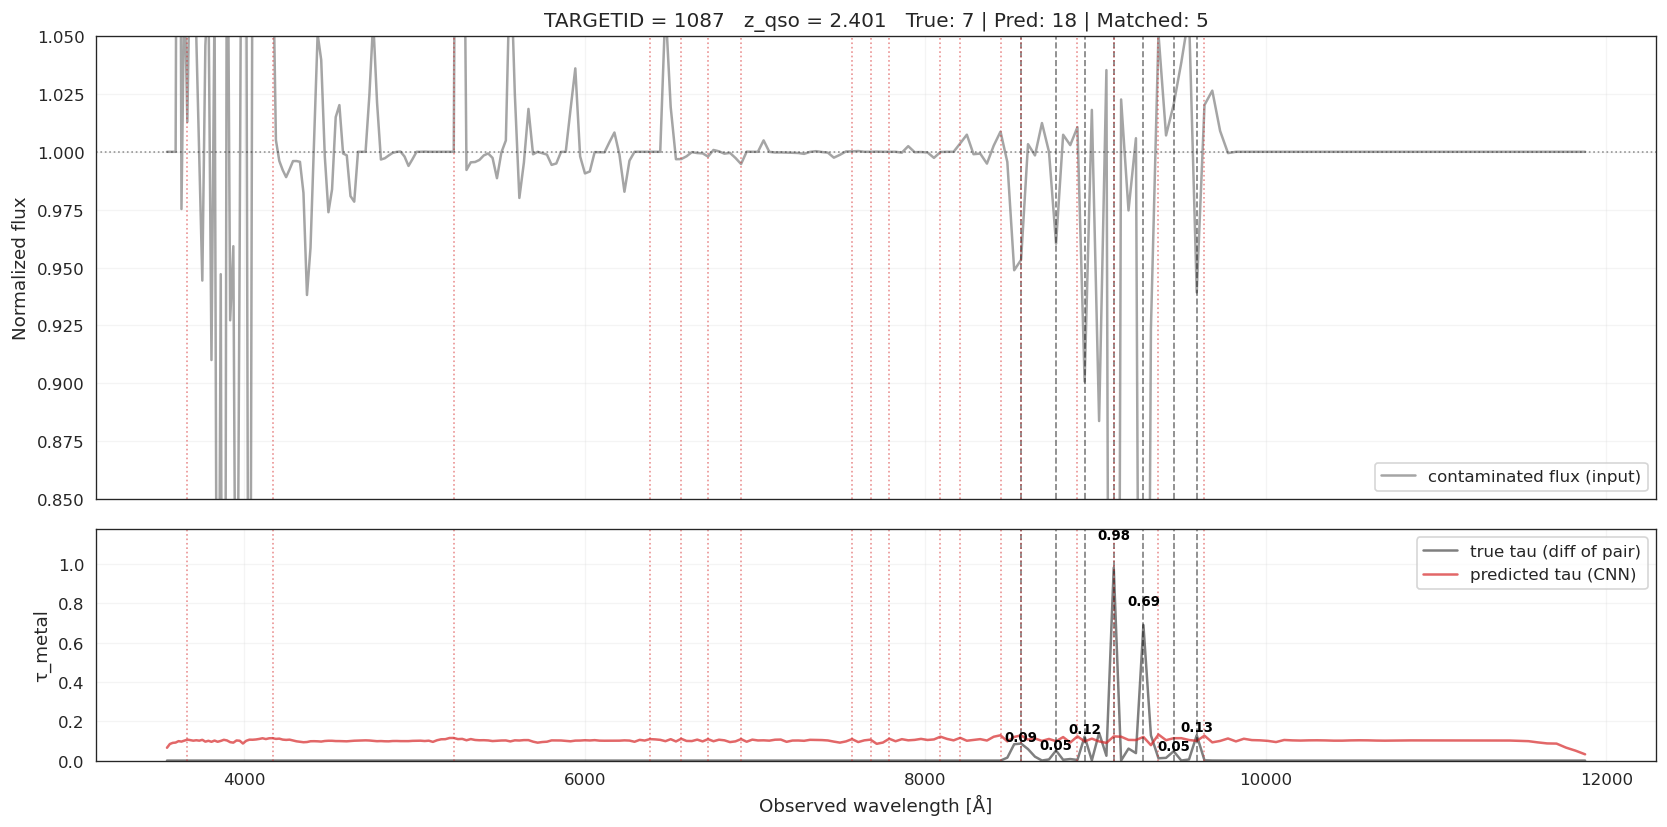


TARGETID 1087 | z_qso = 2.401
true detections:  7
pred detections:  18
matched:          5
missed (FN):      2
false positives:  13

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=2.001 | τ_true=0.0867 → τ_pred=0.1283 | pix_offset=+0
  MgI(2853)      : z=2.073 | τ_true=0.0513 → τ_pred=0.1233 | pix_offset=+3
  MgI(2853)      : z=2.132 | τ_true=0.1220 → τ_pred=0.1230 | pix_offset=+4
  MgI(2853)      : z=2.192 | τ_true=0.9817 → τ_pred=0.1326 | pix_offset=+6
  MgI(2853)      : z=2.315 | τ_true=0.0474 → τ_pred=0.1267 | pix_offset=+4

Strength recovery (integrated tau):
  bias:    +3.0709
  scatter: 5.0923
  RMSE:    5.9466


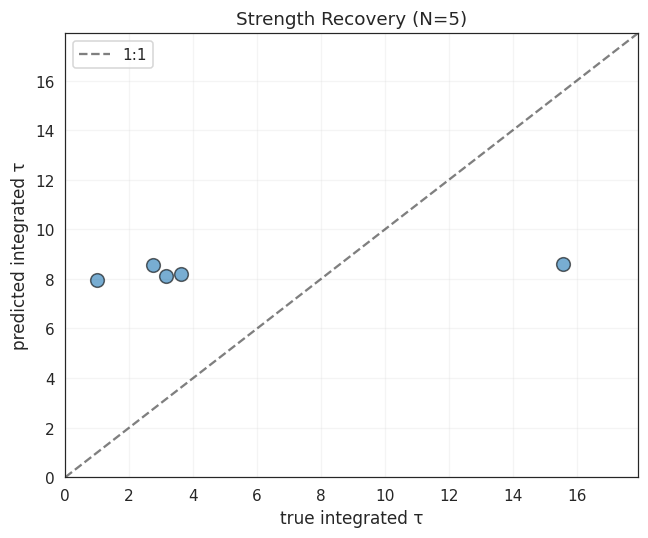


--- MISSED DETECTIONS (False Negatives) ---
  MgI(2853)      : z=2.253 | τ=0.6892 | pix=203
  MgI(2853)      : z=2.363 | τ=0.1289 | pix=210

--- FALSE POSITIVES ---
  MgI(2853)      : z=0.285 | τ=0.1067 | pix=7
  MgI(2853)      : z=0.460 | τ=0.1140 | pix=34
  MgI(2853)      : z=0.833 | τ=0.1151 | pix=82
  MgI(2853)      : z=1.237 | τ=0.1093 | pix=124
  MgI(2853)      : z=1.302 | τ=0.1111 | pix=130
  MgI(2853)      : z=1.357 | τ=0.1092 | pix=135
  MgI(2853)      : z=1.425 | τ=0.1094 | pix=141
  MgI(2853)      : z=1.653 | τ=0.1093 | pix=160
  MgI(2853)      : z=1.691 | τ=0.1066 | pix=163
  MgI(2853)      : z=1.730 | τ=0.1112 | pix=166
  MgI(2853)      : z=1.835 | τ=0.1216 | pix=174
  MgI(2853)      : z=1.876 | τ=0.1158 | pix=177
  MgI(2853)      : z=1.959 | τ=0.1287 | pix=183


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.049010]
  Noise level: 0.000100
  Raw peaks found: 7
    Pi

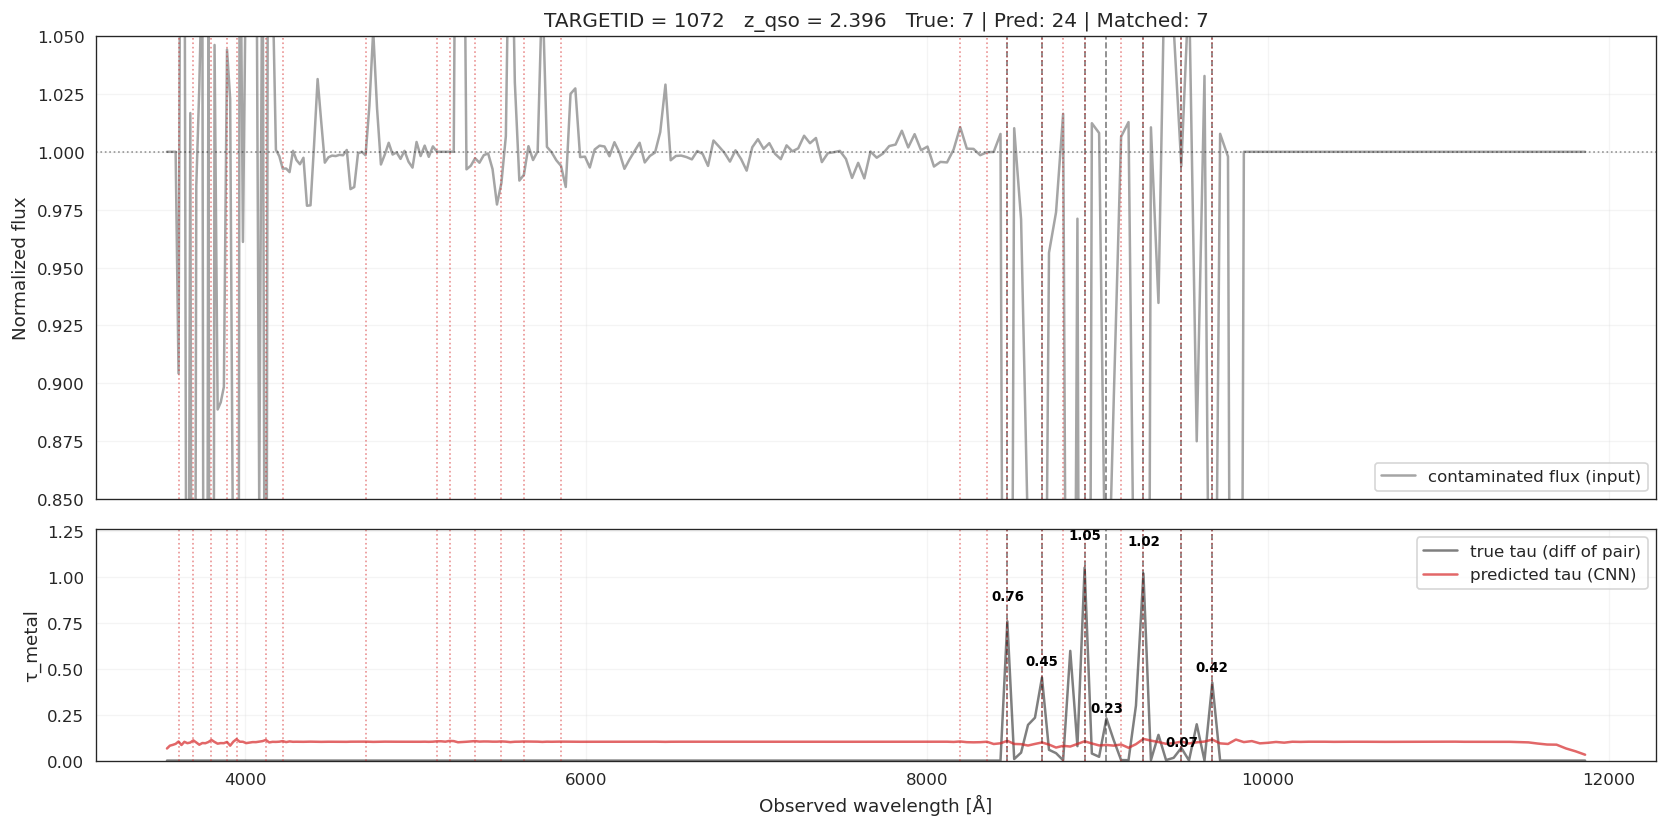


TARGETID 1072 | z_qso = 2.396
true detections:  7
pred detections:  24
matched:          7
missed (FN):      0
false positives:  17

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=1.969 | τ_true=0.7574 → τ_pred=0.1075 | pix_offset=+0
  MgI(2853)      : z=2.040 | τ_true=0.4511 → τ_pred=0.0985 | pix_offset=+0
  MgI(2853)      : z=2.128 | τ_true=1.0490 → τ_pred=0.1049 | pix_offset=+0
  MgI(2853)      : z=2.173 | τ_true=0.2294 → τ_pred=0.0875 | pix_offset=+2
  MgI(2853)      : z=2.249 | τ_true=1.0170 → τ_pred=0.1179 | pix_offset=+0
  MgI(2853)      : z=2.327 | τ_true=0.0690 → τ_pred=0.1033 | pix_offset=+0
  MgI(2853)      : z=2.390 | τ_true=0.4239 → τ_pred=0.1141 | pix_offset=+0

Strength recovery (integrated tau):
  bias:    -5.8115
  scatter: 6.2084
  RMSE:    8.5040


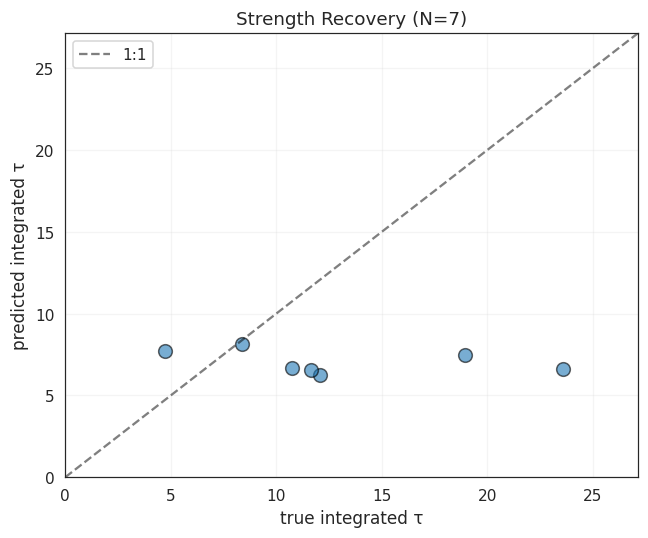


--- FALSE POSITIVES ---
  MgI(2853)      : z=0.265 | τ=0.1037 | pix=4
  MgI(2853)      : z=0.295 | τ=0.1100 | pix=9
  MgI(2853)      : z=0.332 | τ=0.1123 | pix=15
  MgI(2853)      : z=0.364 | τ=0.1014 | pix=20
  MgI(2853)      : z=0.384 | τ=0.1164 | pix=23
  MgI(2853)      : z=0.444 | τ=0.1122 | pix=32
  MgI(2853)      : z=0.479 | τ=0.1060 | pix=37
  MgI(2853)      : z=0.649 | τ=0.1030 | pix=60
  MgI(2853)      : z=0.796 | τ=0.1049 | pix=78
  MgI(2853)      : z=0.822 | τ=0.1070 | pix=81
  MgI(2853)      : z=0.875 | τ=0.1060 | pix=87
  MgI(2853)      : z=0.929 | τ=0.1042 | pix=93
  MgI(2853)      : z=0.975 | τ=0.1039 | pix=98
  MgI(2853)      : z=1.051 | τ=0.1031 | pix=106
  MgI(2853)      : z=1.872 | τ=0.1039 | pix=177
  MgI(2853)      : z=1.927 | τ=0.1025 | pix=181
  MgI(2853)      : z=2.084 | τ=0.0803 | pix=192


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.100236]
  Noise lev

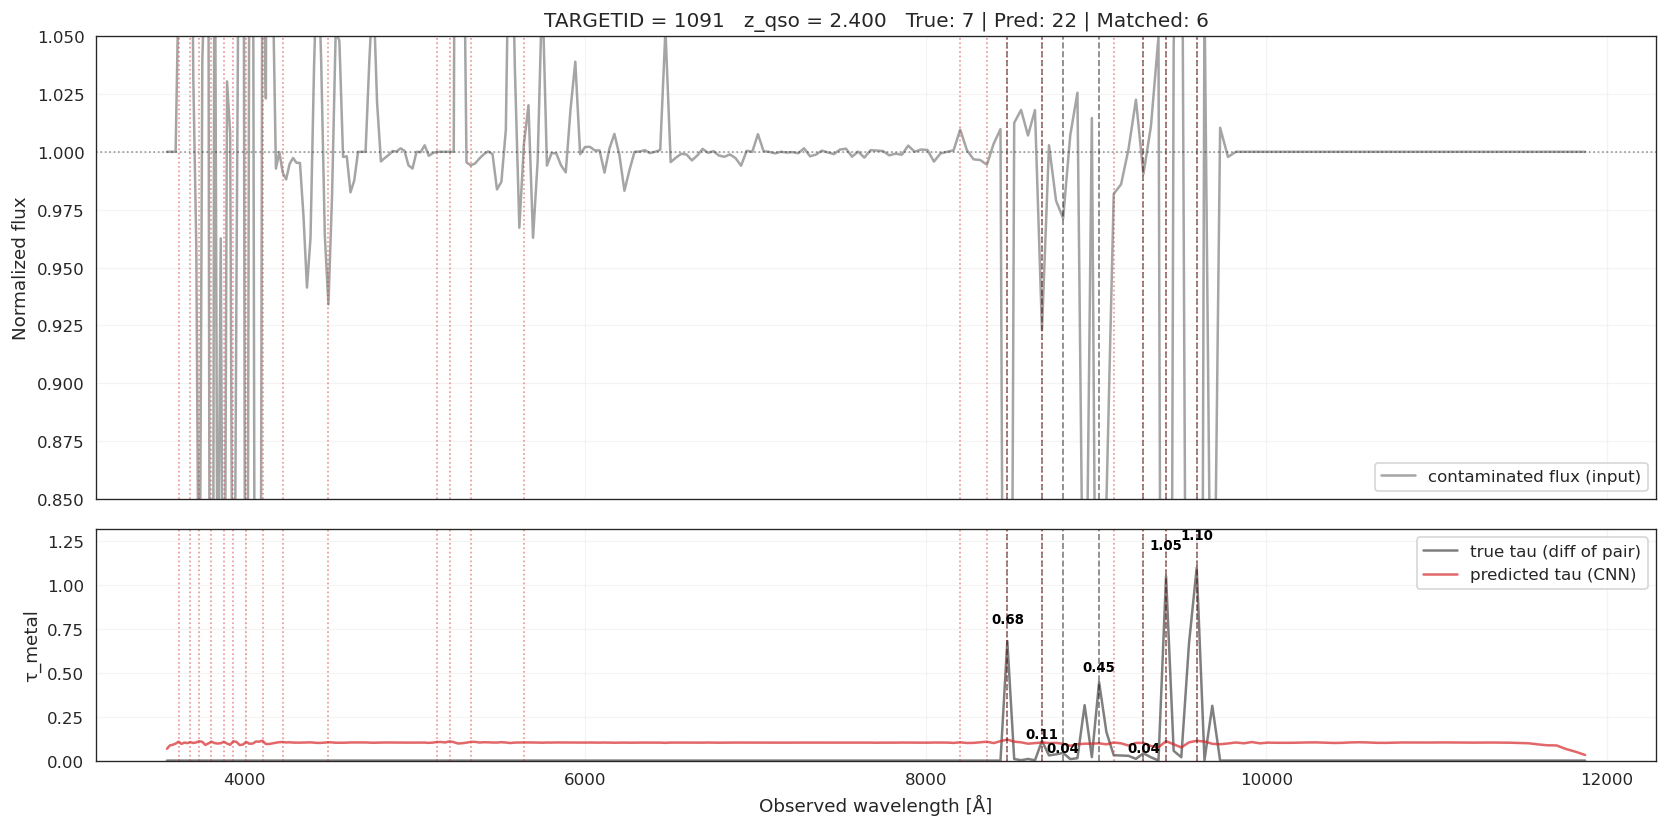


TARGETID 1091 | z_qso = 2.400
true detections:  7
pred detections:  22
matched:          6
missed (FN):      1
false positives:  16

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=1.972 | τ_true=0.6815 → τ_pred=0.1197 | pix_offset=+0
  MgI(2853)      : z=2.043 | τ_true=0.1118 → τ_pred=0.1031 | pix_offset=+0
  MgI(2853)      : z=2.161 | τ_true=0.4464 → τ_pred=0.1028 | pix_offset=+2
  MgI(2853)      : z=2.252 | τ_true=0.0416 → τ_pred=0.1008 | pix_offset=+0
  MgI(2853)      : z=2.299 | τ_true=1.0504 → τ_pred=0.1106 | pix_offset=+0
  MgI(2853)      : z=2.362 | τ_true=1.1002 → τ_pred=0.1128 | pix_offset=+0

Strength recovery (integrated tau):
  bias:    -5.9246
  scatter: 8.4064
  RMSE:    10.2844


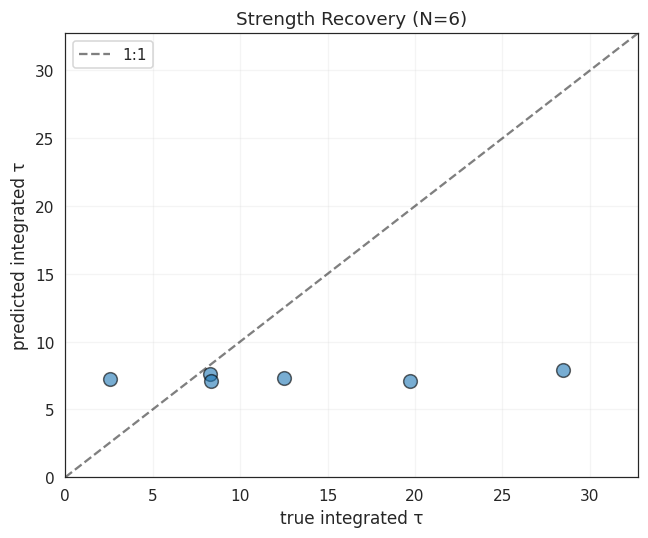


--- MISSED DETECTIONS (False Negatives) ---
  MgI(2853)      : z=2.087 | τ=0.0436 | pix=192

--- FALSE POSITIVES ---
  MgI(2853)      : z=0.266 | τ=0.1076 | pix=4
  MgI(2853)      : z=0.290 | τ=0.1053 | pix=8
  MgI(2853)      : z=0.309 | τ=0.1104 | pix=11
  MgI(2853)      : z=0.334 | τ=0.1081 | pix=15
  MgI(2853)      : z=0.360 | τ=0.1075 | pix=19
  MgI(2853)      : z=0.379 | τ=0.1104 | pix=22
  MgI(2853)      : z=0.405 | τ=0.1064 | pix=26
  MgI(2853)      : z=0.439 | τ=0.1132 | pix=31
  MgI(2853)      : z=0.481 | τ=0.1061 | pix=37
  MgI(2853)      : z=0.575 | τ=0.1046 | pix=50
  MgI(2853)      : z=0.798 | τ=0.1064 | pix=78
  MgI(2853)      : z=0.824 | τ=0.1098 | pix=81
  MgI(2853)      : z=0.868 | τ=0.1068 | pix=86
  MgI(2853)      : z=0.977 | τ=0.1035 | pix=98
  MgI(2853)      : z=1.875 | τ=0.1043 | pix=177
  MgI(2853)      : z=1.930 | τ=0.1076 | pix=181


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal

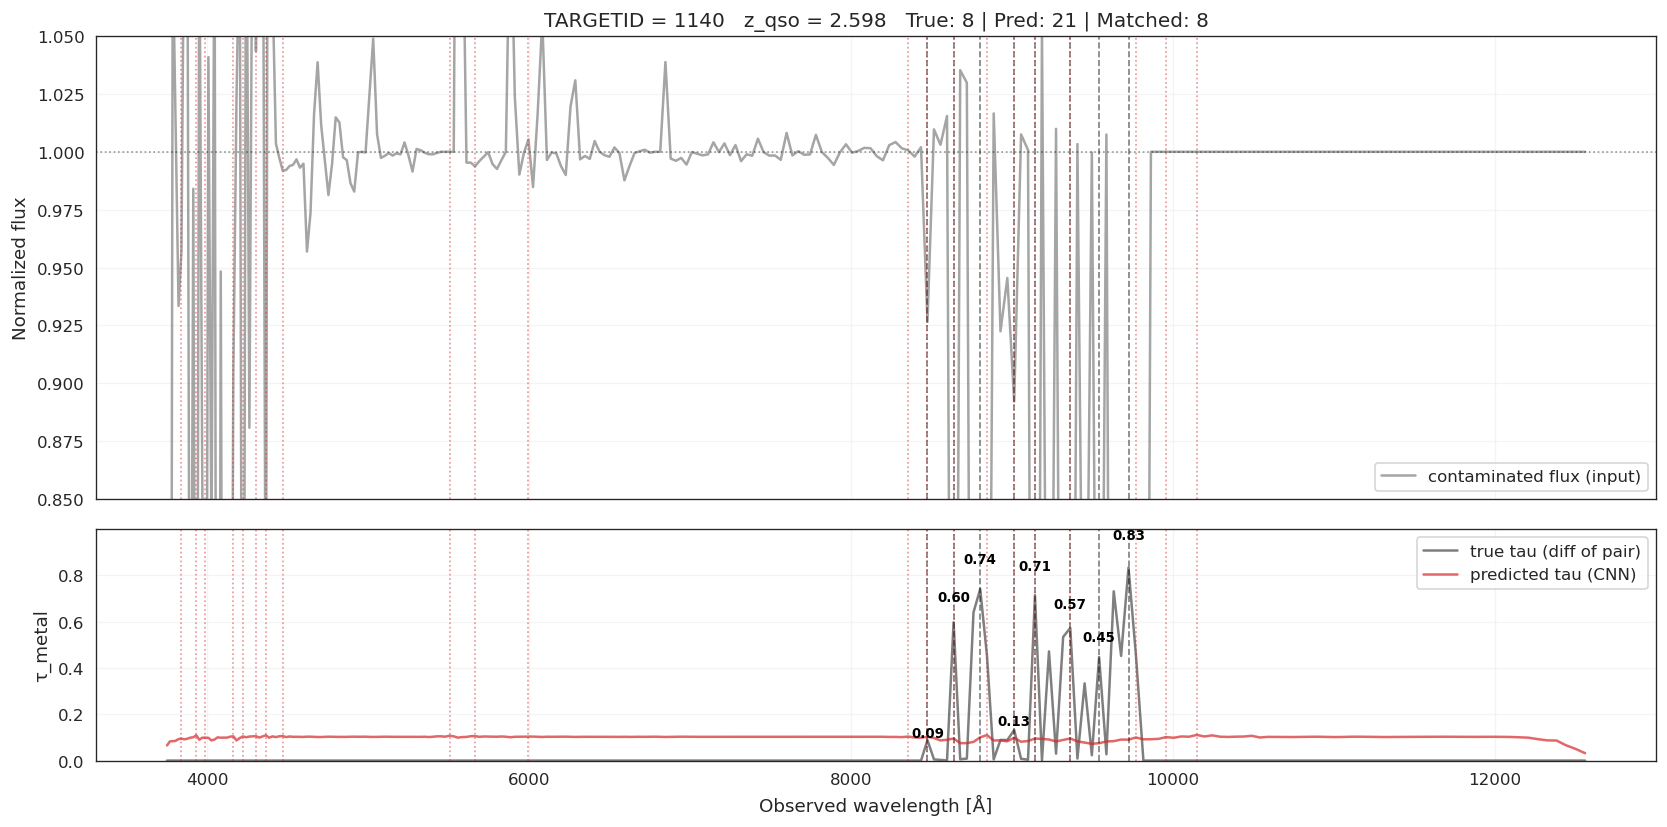


TARGETID 1140 | z_qso = 2.598
true detections:  8
pred detections:  21
matched:          8
missed (FN):      0
false positives:  13

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=1.971 | τ_true=0.0879 → τ_pred=0.1026 | pix_offset=+0
  MgI(2853)      : z=2.028 | τ_true=0.5968 → τ_pred=0.0952 | pix_offset=+0
  MgI(2853)      : z=2.086 | τ_true=0.7401 → τ_pred=0.1098 | pix_offset=+1
  MgI(2853)      : z=2.160 | τ_true=0.1318 → τ_pred=0.0986 | pix_offset=+0
  MgI(2853)      : z=2.205 | τ_true=0.7136 → τ_pred=0.0950 | pix_offset=+0
  MgI(2853)      : z=2.282 | τ_true=0.5720 → τ_pred=0.0954 | pix_offset=+0
  MgI(2853)      : z=2.345 | τ_true=0.4472 → τ_pred=0.0997 | pix_offset=+5
  MgI(2853)      : z=2.409 | τ_true=0.8325 → τ_pred=0.1013 | pix_offset=+5

Strength recovery (integrated tau):
  bias:    -10.0517
  scatter: 8.7579
  RMSE:    13.3318


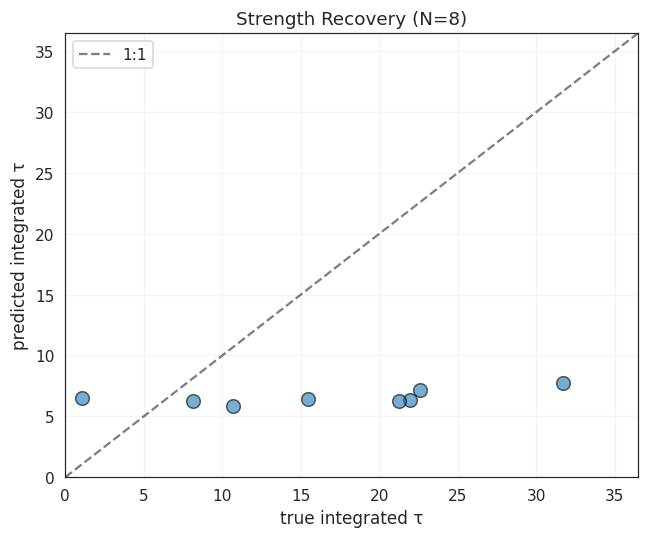


--- FALSE POSITIVES ---
  MgI(2853)      : z=0.346 | τ=0.0943 | pix=5
  MgI(2853)      : z=0.378 | τ=0.1094 | pix=10
  MgI(2853)      : z=0.398 | τ=0.0989 | pix=13
  MgI(2853)      : z=0.459 | τ=0.1048 | pix=22
  MgI(2853)      : z=0.480 | τ=0.1043 | pix=25
  MgI(2853)      : z=0.508 | τ=0.1054 | pix=29
  MgI(2853)      : z=0.530 | τ=0.1091 | pix=32
  MgI(2853)      : z=0.567 | τ=0.1057 | pix=37
  MgI(2853)      : z=0.930 | τ=0.1073 | pix=81
  MgI(2853)      : z=0.986 | τ=0.1054 | pix=87
  MgI(2853)      : z=1.102 | τ=0.1037 | pix=99
  MgI(2853)      : z=1.929 | τ=0.1035 | pix=169
  MgI(2853)      : z=2.557 | τ=0.1106 | pix=210


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.189807]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [131 134 138 141 144 148 154 158]
    Tau values: [1.0699168  0.22950163 0.994982   1.1898073  1.146385   0.34466526
 0.4257131  1.0530602 ]
  

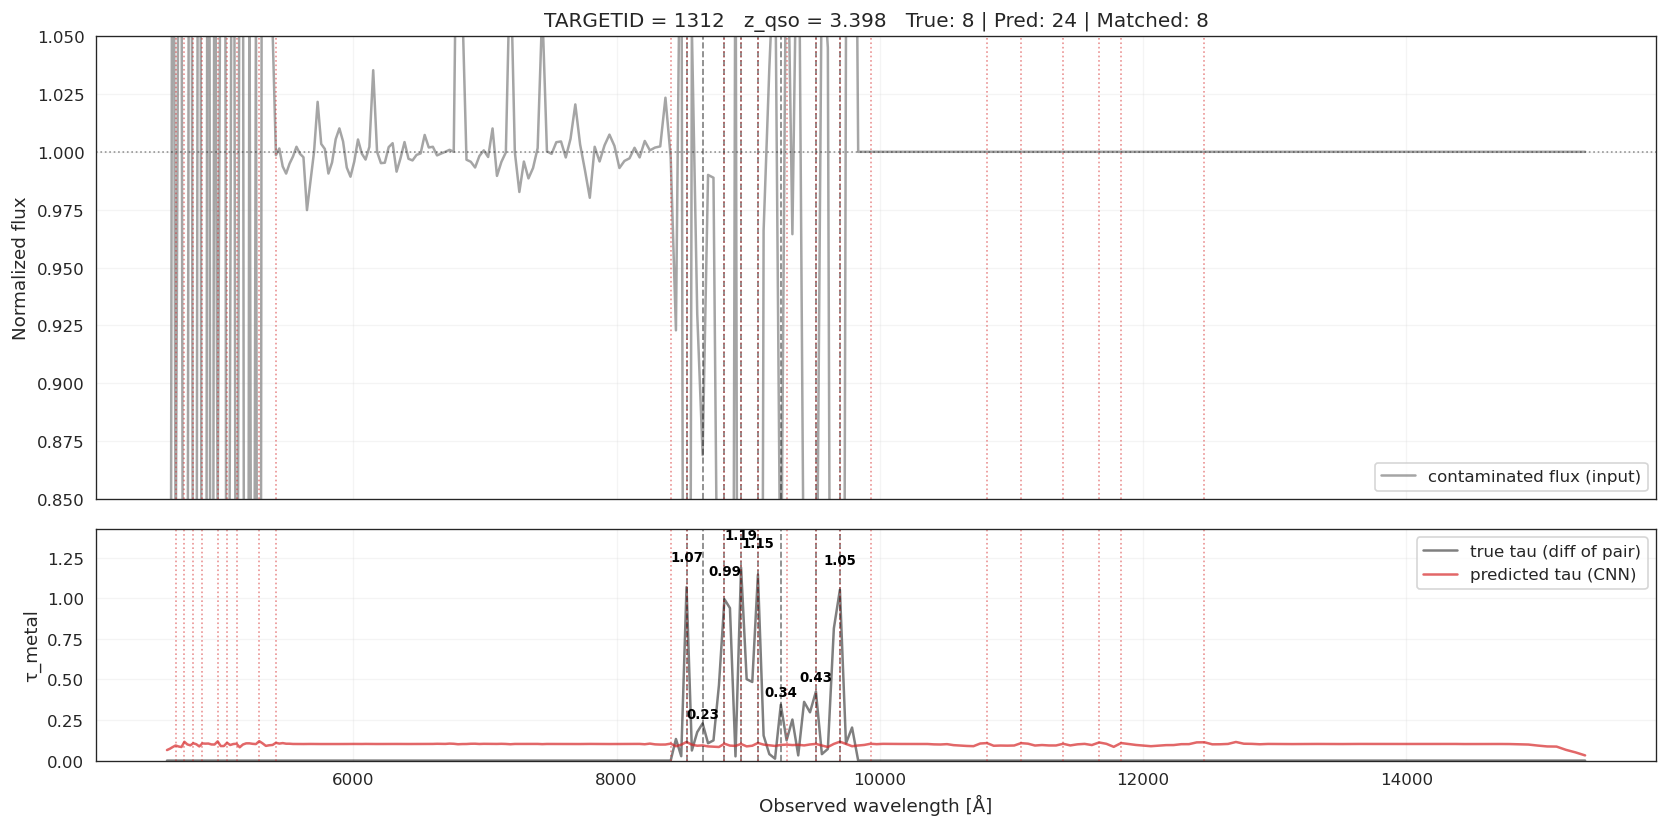


TARGETID 1312 | z_qso = 3.398
true detections:  8
pred detections:  24
matched:          8
missed (FN):      0
false positives:  16

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=1.991 | τ_true=1.0699 → τ_pred=0.1149 | pix_offset=+0
  MgI(2853)      : z=2.033 | τ_true=0.2295 → τ_pred=0.1042 | pix_offset=+4
  MgI(2853)      : z=2.091 | τ_true=0.9950 → τ_pred=0.1024 | pix_offset=+3
  MgI(2853)      : z=2.136 | τ_true=1.1898 → τ_pred=0.1088 | pix_offset=+3
  MgI(2853)      : z=2.181 | τ_true=1.1464 → τ_pred=0.0985 | pix_offset=+5
  MgI(2853)      : z=2.242 | τ_true=0.3447 → τ_pred=0.1029 | pix_offset=+6
  MgI(2853)      : z=2.335 | τ_true=0.4257 → τ_pred=0.1165 | pix_offset=+4
  MgI(2853)      : z=2.399 | τ_true=1.0531 → τ_pred=0.1037 | pix_offset=+5

Strength recovery (integrated tau):
  bias:    -16.3613
  scatter: 9.9778
  RMSE:    19.1637


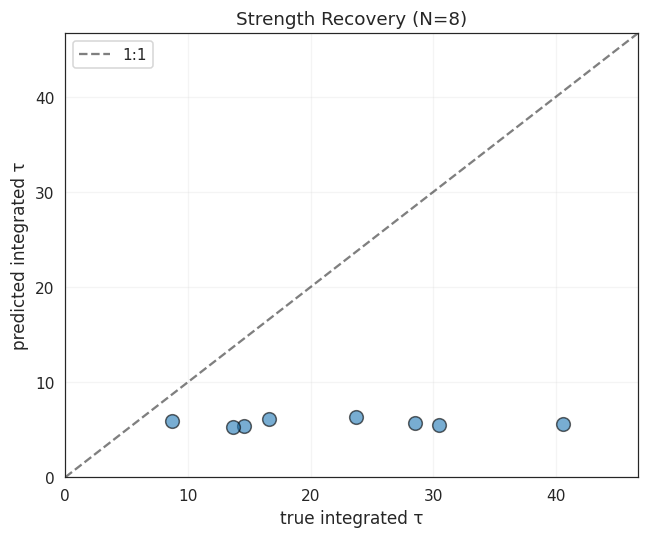


--- FALSE POSITIVES ---
  MgI(2853)      : z=0.630 | τ=0.0932 | pix=3
  MgI(2853)      : z=0.654 | τ=0.1160 | pix=6
  MgI(2853)      : z=0.677 | τ=0.1068 | pix=9
  MgI(2853)      : z=0.701 | τ=0.1058 | pix=12
  MgI(2853)      : z=0.742 | τ=0.1184 | pix=17
  MgI(2853)      : z=0.767 | τ=0.1098 | pix=20
  MgI(2853)      : z=0.792 | τ=0.1039 | pix=23
  MgI(2853)      : z=0.853 | τ=0.1199 | pix=30
  MgI(2853)      : z=0.897 | τ=0.1098 | pix=35
  MgI(2853)      : z=1.948 | τ=0.1045 | pix=128
  MgI(2853)      : z=2.790 | τ=0.1080 | pix=181
  MgI(2853)      : z=2.881 | τ=0.1076 | pix=186
  MgI(2853)      : z=2.993 | τ=0.1037 | pix=192
  MgI(2853)      : z=3.089 | τ=0.1118 | pix=197
  MgI(2853)      : z=3.148 | τ=0.1082 | pix=200
  MgI(2853)      : z=3.370 | τ=0.1129 | pix=211


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.547368]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels:

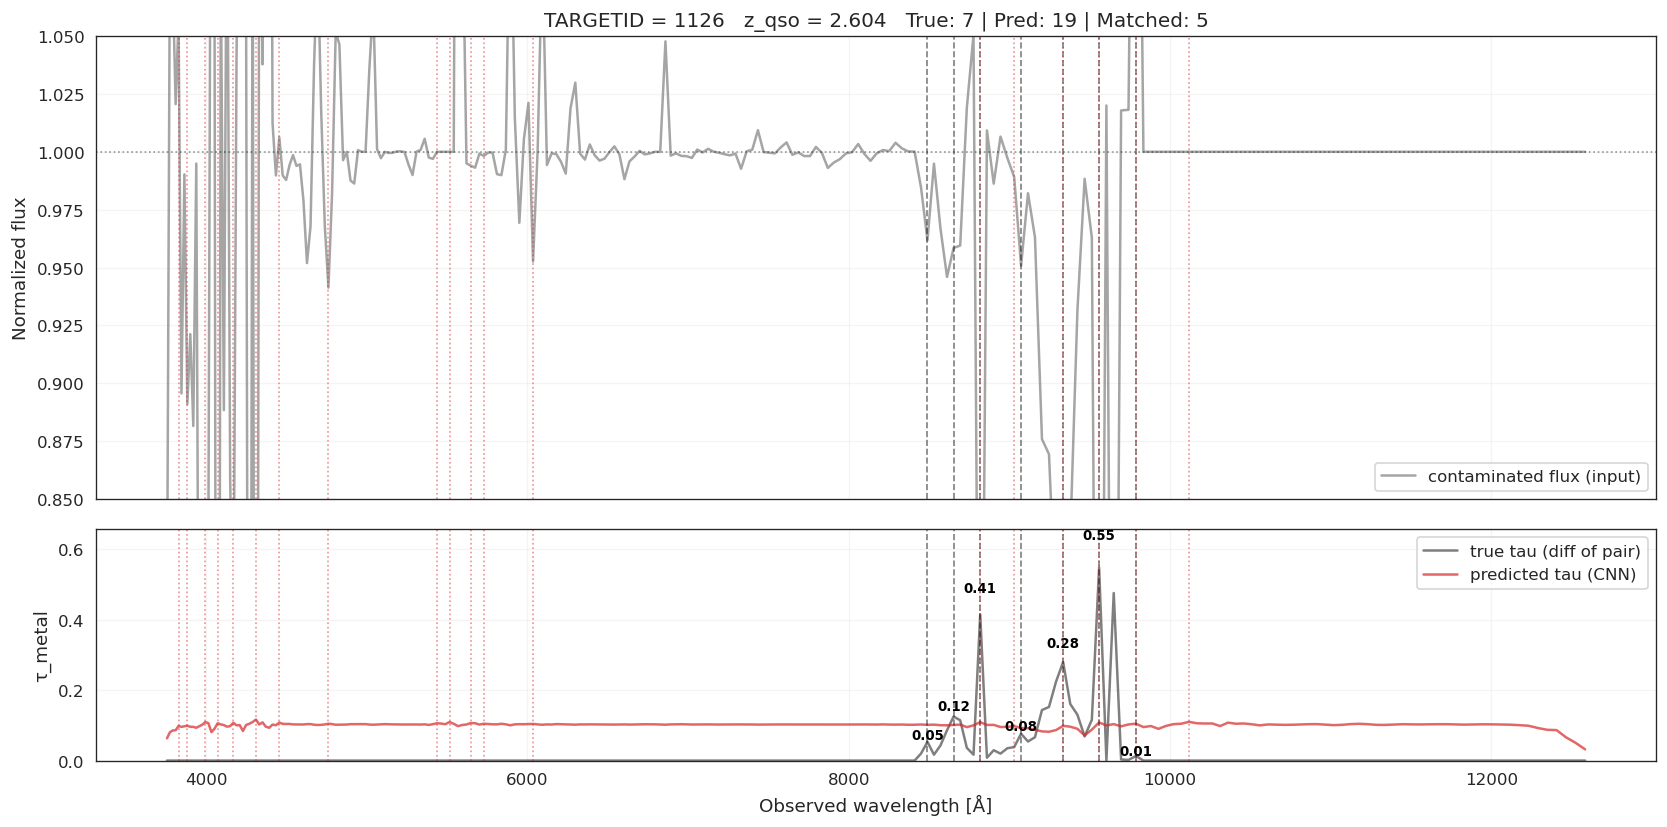


TARGETID 1126 | z_qso = 2.604
true detections:  7
pred detections:  19
matched:          5
missed (FN):      2
false positives:  14

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=2.033 | τ_true=0.1249 → τ_pred=0.1089 | pix_offset=+4
  MgI(2853)      : z=2.091 | τ_true=0.4146 → τ_pred=0.0977 | pix_offset=+5
  MgI(2853)      : z=2.180 | τ_true=0.0761 → τ_pred=0.0985 | pix_offset=+6
  MgI(2853)      : z=2.272 | τ_true=0.2795 → τ_pred=0.1081 | pix_offset=+5
  MgI(2853)      : z=2.350 | τ_true=0.5474 → τ_pred=0.1047 | pix_offset=+5

Strength recovery (integrated tau):
  bias:    -1.9157
  scatter: 4.3887
  RMSE:    4.7886


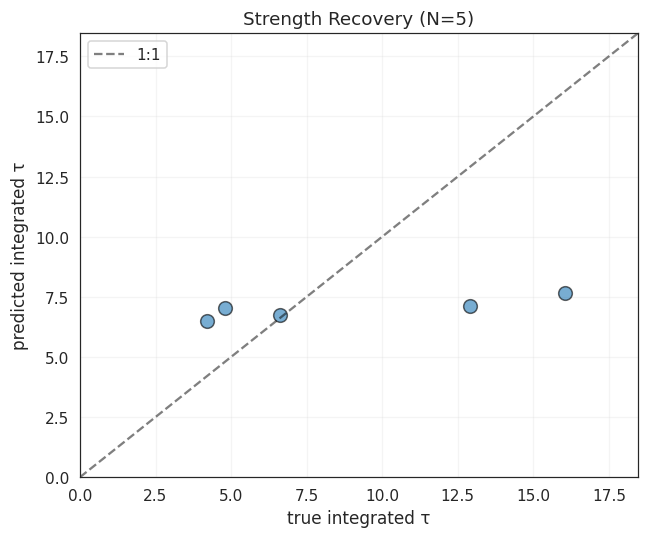


--- MISSED DETECTIONS (False Negatives) ---
  MgI(2853)      : z=1.976 | τ=0.0533 | pix=172
  MgI(2853)      : z=2.431 | τ=0.0131 | pix=202

--- FALSE POSITIVES ---
  MgI(2853)      : z=0.342 | τ=0.0981 | pix=4
  MgI(2853)      : z=0.361 | τ=0.0988 | pix=7
  MgI(2853)      : z=0.401 | τ=0.1094 | pix=13
  MgI(2853)      : z=0.427 | τ=0.1059 | pix=17
  MgI(2853)      : z=0.462 | τ=0.1073 | pix=22
  MgI(2853)      : z=0.511 | τ=0.1164 | pix=29
  MgI(2853)      : z=0.562 | τ=0.1079 | pix=36
  MgI(2853)      : z=0.669 | τ=0.1046 | pix=50
  MgI(2853)      : z=0.906 | τ=0.1059 | pix=78
  MgI(2853)      : z=0.933 | τ=0.1093 | pix=81
  MgI(2853)      : z=0.980 | τ=0.1065 | pix=86
  MgI(2853)      : z=1.008 | τ=0.1045 | pix=89
  MgI(2853)      : z=1.115 | τ=0.1040 | pix=100
  MgI(2853)      : z=2.547 | τ=0.1100 | pix=209


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.981643]
  Noise level

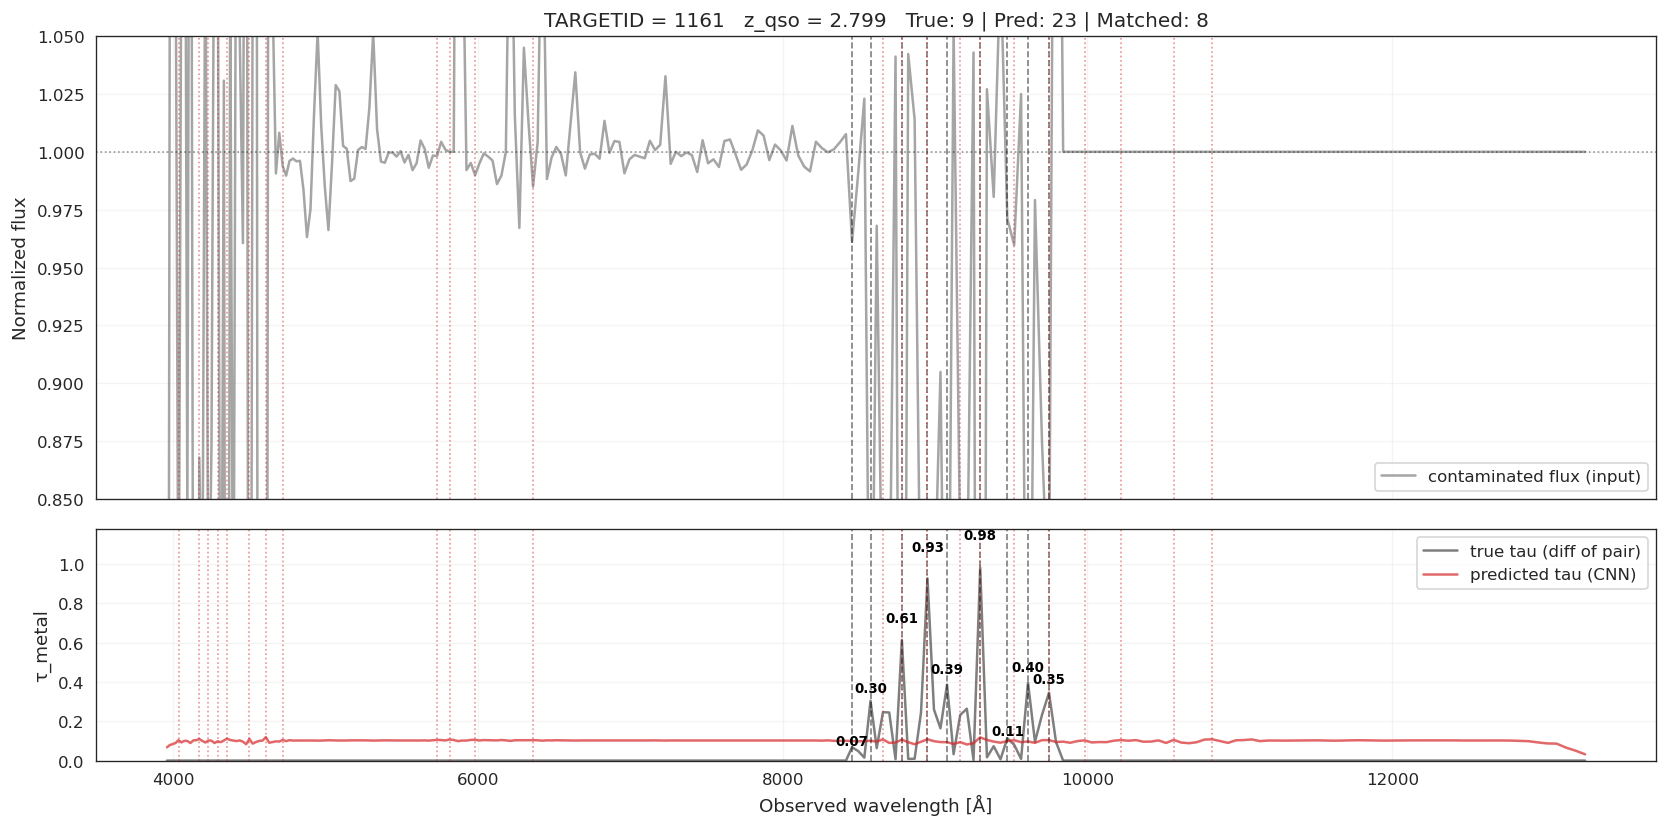


TARGETID 1161 | z_qso = 2.799
true detections:  9
pred detections:  23
matched:          8
missed (FN):      1
false positives:  15

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=1.964 | τ_true=0.0678 → τ_pred=0.1078 | pix_offset=+5
  MgI(2853)      : z=2.006 | τ_true=0.3039 → τ_pred=0.1065 | pix_offset=+5
  MgI(2853)      : z=2.078 | τ_true=0.6142 → τ_pred=0.1085 | pix_offset=+4
  MgI(2853)      : z=2.137 | τ_true=0.9269 → τ_pred=0.0940 | pix_offset=+5
  MgI(2853)      : z=2.182 | τ_true=0.3864 → τ_pred=0.1180 | pix_offset=+5
  MgI(2853)      : z=2.258 | τ_true=0.9816 → τ_pred=0.1037 | pix_offset=+5
  MgI(2853)      : z=2.321 | τ_true=0.1138 → τ_pred=0.1042 | pix_offset=+6
  MgI(2853)      : z=2.417 | τ_true=0.3453 → τ_pred=0.1029 | pix_offset=+5

Strength recovery (integrated tau):
  bias:    -5.5690
  scatter: 5.7846
  RMSE:    8.0297


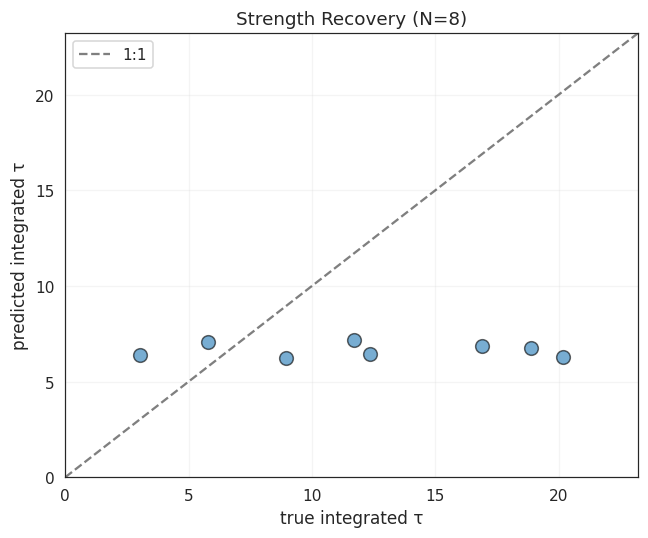


--- MISSED DETECTIONS (False Negatives) ---
  MgI(2853)      : z=2.368 | τ=0.3961 | pix=187

--- FALSE POSITIVES ---
  MgI(2853)      : z=0.415 | τ=0.1041 | pix=4
  MgI(2853)      : z=0.462 | τ=0.1097 | pix=11
  MgI(2853)      : z=0.483 | τ=0.1025 | pix=14
  MgI(2853)      : z=0.505 | τ=0.0981 | pix=17
  MgI(2853)      : z=0.526 | τ=0.1115 | pix=20
  MgI(2853)      : z=0.578 | τ=0.1103 | pix=27
  MgI(2853)      : z=0.616 | τ=0.1191 | pix=32
  MgI(2853)      : z=0.654 | τ=0.1050 | pix=37
  MgI(2853)      : z=1.009 | τ=0.1054 | pix=78
  MgI(2853)      : z=1.038 | τ=0.1071 | pix=81
  MgI(2853)      : z=1.097 | τ=0.1056 | pix=87
  MgI(2853)      : z=1.230 | τ=0.1039 | pix=100
  MgI(2853)      : z=2.583 | τ=0.1045 | pix=200
  MgI(2853)      : z=2.703 | τ=0.1053 | pix=207
  MgI(2853)      : z=2.792 | τ=0.1081 | pix=212


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.030222]
  Noise lev

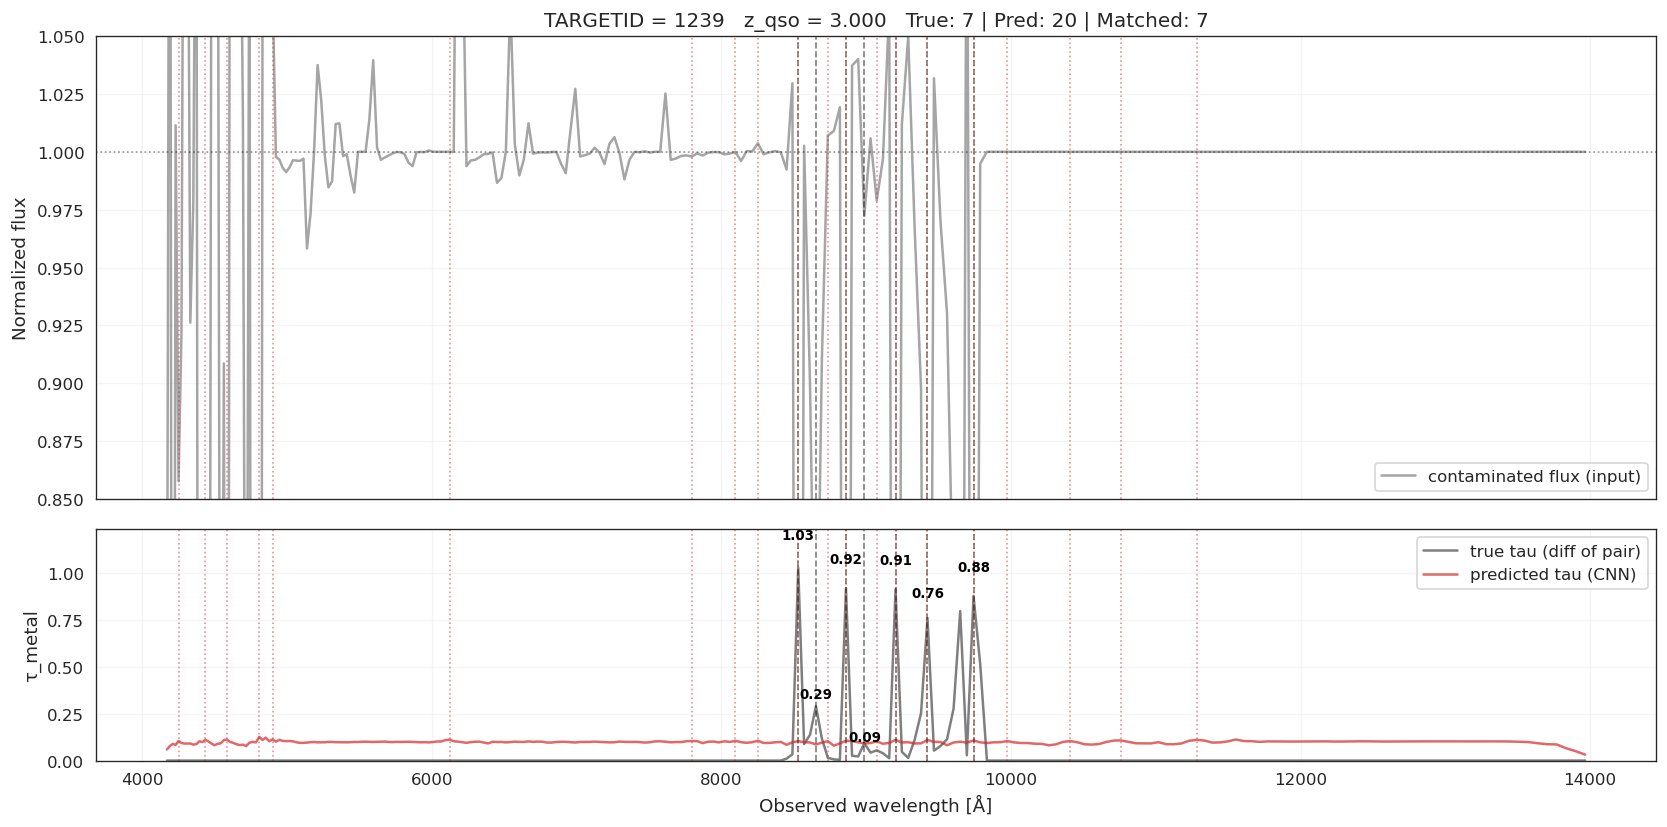


TARGETID 1239 | z_qso = 3.000
true detections:  7
pred detections:  20
matched:          7
missed (FN):      0
false positives:  13

--- MATCHED DETECTIONS ---
  MgI(2853)      : z=1.990 | τ_true=1.0302 → τ_pred=0.1038 | pix_offset=+0
  MgI(2853)      : z=2.033 | τ_true=0.2907 → τ_pred=0.1037 | pix_offset=+2
  MgI(2853)      : z=2.105 | τ_true=0.9192 → τ_pred=0.1061 | pix_offset=+0
  MgI(2853)      : z=2.150 | τ_true=0.0928 → τ_pred=0.1028 | pix_offset=+2
  MgI(2853)      : z=2.226 | τ_true=0.9149 → τ_pred=0.1106 | pix_offset=+0
  MgI(2853)      : z=2.303 | τ_true=0.7612 → τ_pred=0.1097 | pix_offset=+0
  MgI(2853)      : z=2.414 | τ_true=0.8791 → τ_pred=0.1074 | pix_offset=+0

Strength recovery (integrated tau):
  bias:    -7.9122
  scatter: 5.5470
  RMSE:    9.6629


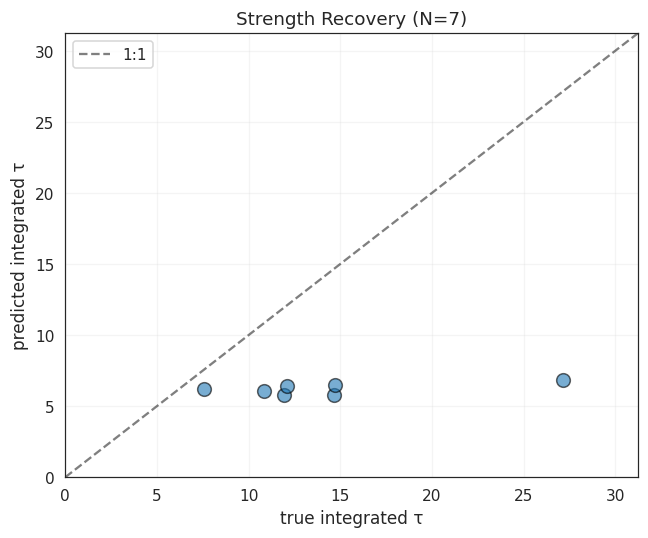


--- FALSE POSITIVES ---
  MgI(2853)      : z=0.489 | τ=0.1047 | pix=4
  MgI(2853)      : z=0.554 | τ=0.1104 | pix=13
  MgI(2853)      : z=0.607 | τ=0.1117 | pix=20
  MgI(2853)      : z=0.685 | τ=0.1261 | pix=30
  MgI(2853)      : z=0.717 | τ=0.1131 | pix=34
  MgI(2853)      : z=1.146 | τ=0.1121 | pix=81
  MgI(2853)      : z=1.732 | τ=0.1043 | pix=132
  MgI(2853)      : z=1.838 | τ=0.1055 | pix=140
  MgI(2853)      : z=1.892 | τ=0.1061 | pix=144
  MgI(2853)      : z=2.496 | τ=0.1044 | pix=184
  MgI(2853)      : z=2.649 | τ=0.1041 | pix=193
  MgI(2853)      : z=2.772 | τ=0.1074 | pix=200
  MgI(2853)      : z=2.955 | τ=0.1106 | pix=210



TypeError: extract_lines_v4() missing 2 required positional arguments: 'rest_grid' and 'metal_lines'

In [101]:
for s in val_samples[:10]:
    plot_prediction_vs_truth(model, s, device=device)
 
# aggregate check across all validation samples
all_matched, all_missed, all_fp = [], [], []
for s in val_samples:
    flux = s["flux"].astype(np.float32)
    ivar = s["ivar"].astype(np.float32)
    shifted = make_shifted_channels(flux).astype(np.float32)
    x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(x_t)[0].cpu().numpy()
 
    true_dets = extract_lines_v4(s["label"], s["z_qso"])
    pred_dets = extract_lines_v4(pred, s["z_qso"])
    matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3)
    all_matched += matched
    all_missed += missed
    all_fp += false_pos
 
n_true = len(all_matched) + len(all_missed)
n_pred = len(all_matched) + len(all_fp)
completeness = len(all_matched) / n_true if n_true else float("nan")
purity = len(all_matched) / n_pred if n_pred else float("nan")
print(f"validation set: {len(val_samples)} spectra")
print(f"true lines:     {n_true}")
print(f"predicted:      {n_pred}")
print(f"completeness:   {completeness:.2f}")
print(f"purity:         {purity:.2f}")
 

if all_matched:
    true_s = np.array([m[0]["integrated_tau"] for m in all_matched])
    pred_s = np.array([m[1]["integrated_tau"] for m in all_matched])
    print(f"strength bias:    {np.mean(pred_s - true_s):.4f}")
    print(f"strength scatter: {np.std(pred_s - true_s):.4f}")
 
    plt.figure(figsize=(4, 4), dpi=110)
    lims = [0, max(true_s.max(), pred_s.max()) * 1.1 + 1e-6]
    plt.plot(lims, lims, "k--", alpha=0.5)
    plt.scatter(true_s, pred_s, s=15, alpha=0.7)
    plt.xlabel("true integrated tau")
    plt.ylabel("predicted integrated tau")
    plt.title("Validation set: strength recovery")
    plt.tight_layout()
    plt.show()
 
 
# A low completeness/purity or a strongly biased strength-recovery plot at
# this exaggerated test strength (0.2) is a sign to debug the pipeline
# (pixel-shift bookkeeping, label noise, continuum normalization) before
# worrying about detecting the realistic 1e-4 strength regime -- if it
# can't find an obvious injected line here, it won't find a subtle one.


## Split architecture: separate location and strength

**Why:** section 11.3 shows the current model's raw output collapsed to a
near-constant ~0.02 everywhere (matches the *global mean* of the sparse
label almost exactly), while true labels are 89% exact zero with rare
spikes up to ~1.4. A single MSE regression head has little incentive to
push the 89% "quiet" majority to exactly zero -- it can get away with
predicting the mean everywhere. Downstream, `extract_lines_v4`'s
local-noise-relative threshold then reports every ripple in that flat
output as a "detection," which is the false-positive flood you were
seeing.

**Fix:** two heads sharing one trunk --
- `detect_head`: per-pixel logit -> sigmoid probability that a line sits
  at that pixel, trained with **focal BCE** against a small Gaussian bump
  painted around each true peak (heavily down-weights the easy, dominant
  background class instead of leaving it to leak a constant offset).
- `strength_head`: continuous regression, but its loss is **masked to
  only pixels near true peaks** -- it is never asked to regress toward
  the flat background, so it has no reason to output a smoothed baseline
  everywhere.

At inference: threshold the detection probability to find pixel
locations, then read the strength head's value at those pixels. This
replaces the local-MAD-based peak finder in `extract_lines_v4` (which was
adaptively threshold against the *prediction's own* noise -- fragile when
the prediction is a smooth blob) with a fixed, calibrated probability
cut.

In [78]:

def build_detection_targets(labels, min_peak=0.01, sigma_pix=1.5, distance=3):
    """
    Turn the continuous, sparse dF label (N_METALS, N_PIX) into a soft
    per-pixel detection heatmap (N_METALS, N_PIX) in [0, 1]: a small
    Gaussian bump centered on each true peak.

    A hard 0/1 target also works, but the soft Gaussian gives the
    classifier partial credit for being "close" during training, which
    speeds up convergence when peak positions only matter to within a
    few pixels (as they do here downstream in match_detections_v2).

    min_peak: same absolute threshold you already use elsewhere
        (extract_lines_v4 uses min_peak_tau=0.001-0.01) -- keep these
        consistent so "what counts as a real line" doesn't silently
        differ between label-building and evaluation.
    """

    n_metals, n_pix = labels.shape
    heatmap = np.zeros((n_metals, n_pix), dtype=np.float32)
    xs = np.arange(n_pix)

    for i in range(n_metals):
        tau = labels[i]
        if tau.max() < min_peak:
            continue
        peaks, _ = find_peaks(tau, height=min_peak, distance=distance)
        for p in peaks:
            heatmap[i] = np.maximum(
                heatmap[i],
                np.exp(-0.5 * ((xs - p) / sigma_pix) ** 2),
            )

    return heatmap


### 12.2 Dataset wrapper that also emits the detection heatmap

In [143]:

class MetalLineDatasetV2(Dataset):
    """
    Same as MetalLineDataset, but __getitem__ also returns the binary/soft
    detection target built from the true label, for the two-head model.
    """
    def __init__(self, samples, min_peak=0.01, sigma_pix=1.0):

                 # sigma_pix=1.5):
        self.samples = samples
        self.min_peak = min_peak
        self.sigma_pix = sigma_pix

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]

        flux = s["flux"].astype(np.float32)
        ivar = s["ivar"].astype(np.float32)

        IVAR_SCALE = 1e7
        ivar = ivar / IVAR_SCALE

        shifted = make_shifted_channels(flux).astype(np.float32)
        x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)

        y_strength = s["label"].astype(np.float32)
        w = s["weight"].astype(np.float32)
        y_detect = build_detection_targets(
            y_strength, min_peak=self.min_peak, sigma_pix=self.sigma_pix
        )

        return (
            torch.from_numpy(x),
            torch.from_numpy(y_detect),
            torch.from_numpy(y_strength),
            torch.from_numpy(w),
        )


train_loader_v2 = DataLoader(MetalLineDatasetV2(train_samples), batch_size=32, shuffle=True)
val_loader_v2 = DataLoader(MetalLineDatasetV2(val_samples), batch_size=32, shuffle=False)


### 12.3 Two-head model

In [144]:

class TwoHeadMetalCNN(nn.Module):
    def __init__(self, in_channels, n_metals, hidden=64):
        super().__init__()

        self.trunk = nn.Sequential(
            nn.Conv1d(
                in_channels, hidden,
                kernel_size=7,
                padding=3,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        
            nn.Conv1d(
                hidden, hidden,
                kernel_size=5,
                padding=2,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        
            nn.Conv1d(
                hidden, hidden,
                kernel_size=5,
                padding=2,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        
            nn.Conv1d(
                hidden, hidden,
                kernel_size=5,
                padding=2,
                padding_mode="replicate",
            ),
            nn.LeakyReLU(0.01),
        )
        # raw logits -- apply sigmoid outside (BCEWithLogits-style) for
        # numerical stability
        self.detect_head = nn.Conv1d(
            hidden,
            n_metals,
            kernel_size=3,
            padding=1,
            padding_mode="replicate",
        )
        self.strength_head = nn.Conv1d(
            hidden,
            n_metals,
            kernel_size=3,
            padding=1,
            padding_mode="replicate",
        )

    def forward(self, x):
        feat = self.trunk(x)
        detect_logits = self.detect_head(feat)
        strength = self.strength_head(feat)
        return detect_logits, strength


two_head_model = TwoHeadMetalCNN(in_channels=2 + N_METALS, n_metals=N_METALS)


### 12.4 Losses: focal BCE for location, masked MSE for strength

In [145]:

def focal_bce_loss(logits, target, alpha=0.85, gamma=2.0):
    """
    Focal loss (Lin et al. 2017) on top of BCE-with-logits. `alpha` up-
    weights the rare positive (on-a-line) class; `gamma` down-weights
    already-easy examples (both confidently-correct negatives AND
    confidently-correct positives) so the loss stays focused on the hard,
    ambiguous pixels near line edges instead of being swamped by the vast
    number of trivially-easy background pixels.
    """
    prob = torch.sigmoid(logits)
    prob = prob.clamp(1e-6, 1 - 1e-6)

    bce = -(alpha * target * torch.log(prob)
            + (1 - alpha) * (1 - target) * torch.log(1 - prob))
    focal_weight = (target * (1 - prob) + (1 - target) * prob) ** gamma
    return (focal_weight * bce).mean()
    

# def detection_loss(logits, target, pos_weight=10.0):
#     # Pixelwise weighting based on soft target.
#     # target=1 gets pos_weight; target=0 gets weight 1.
#     weights = 1.0 + (pos_weight - 1.0) * target

#     loss = F.binary_cross_entropy_with_logits(
#         logits,
#         target,
#         reduction="none",
#     )
#     return (weights * loss).mean()

def detection_loss(logits, target, pos_weight=10.0):
    weights = 1.0 + (pos_weight - 1.0) * target

    bce = torch.nn.functional.binary_cross_entropy_with_logits(
    # bce = F.binary_cross_entropy_with_logits(
        logits,
        target,
        reduction="none",
    )

    return (weights * bce).mean()

def masked_strength_loss(
    strength_pred,
    strength_true,
    weight,
    min_strength=0.01,
):
    mask = (strength_true >= min_strength).float()
    weighted_mask = mask * weight
    se = (strength_pred - strength_true) ** 2 * weighted_mask

    return se.sum() / (weighted_mask.sum() + 1e-8)


# def combined_loss(detect_logits, strength_pred, detect_target, strength_true,
#                    weight, lambda_strength=1.0, alpha=0.85, gamma=2.0):
#     l_detect = focal_bce_loss(detect_logits, detect_target, alpha=alpha, gamma=gamma)
#     l_strength = masked_strength_loss(strength_pred, strength_true, detect_target, weight)
#     total = l_detect + lambda_strength * l_strength
#     return total, l_detect.detach().item(), l_strength.detach().item()


def combined_loss(
    detect_logits,
    strength_pred,
    detect_target,
    strength_true,
    weight,
    lambda_strength=1.0,
    pos_weight=10.0,
    # pos_weight=5.0,
):
    l_detect = detection_loss(
        detect_logits,
        detect_target,
        pos_weight=pos_weight,
    )

    l_strength = masked_strength_loss(
        strength_pred,
        strength_true,
        weight,
    )

    total = l_detect + lambda_strength * l_strength

    return total, l_detect.detach().item(), l_strength.detach().item()


### 12.5 Training loop for the two-head model

In [146]:

def train_two_head(model, train_loader, val_loader, epochs=60, lr=1e-3,
                    device="cpu", lambda_strength=1.0, alpha=0.85, gamma=2.0):
    """
    NOTE the learning rate: the original run used lr=1e-5 for 30 epochs,
    and the training-loss trace barely moved (0.0119 -> 0.0106) -- far
    from converged. 1e-3 (Adam's usual starting point) with a
    ReduceLROnPlateau scheduler gets you into the right regime much
    faster; the scheduler will back it off automatically if it overshoots.
    """
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)
    best_val = np.inf

    for epoch in range(epochs):
        model.train()
        train_loss = train_ld = train_ls = 0.0
        for x, y_detect, y_strength, w in train_loader:
            x = x.to(device)
            y_detect, y_strength, w = y_detect.to(device), y_strength.to(device), w.to(device)

            opt.zero_grad()
            detect_logits, strength_pred = model(x)
            
            # loss, ld, ls = combined_loss(
            #     detect_logits, strength_pred, y_detect, y_strength, w,
            #     lambda_strength=lambda_strength, alpha=alpha, gamma=gamma)

            loss, ld, ls = combined_loss(
                detect_logits, strength_pred, y_detect, y_strength, 
                w, lambda_strength=lambda_strength)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()

            bs = x.size(0)
            train_loss += loss.item() * bs
            train_ld += ld * bs
            train_ls += ls * bs

        n_train = len(train_loader.dataset)
        train_loss /= n_train
        train_ld /= n_train
        train_ls /= n_train

        model.eval()
        val_loss = val_ld = val_ls = 0.0
        with torch.no_grad():
            for x, y_detect, y_strength, w in val_loader:
                x = x.to(device)
                y_detect, y_strength, w = y_detect.to(device), y_strength.to(device), w.to(device)
                detect_logits, strength_pred = model(x)
                # loss, ld, ls = combined_loss(
                #     detect_logits, strength_pred, y_detect, y_strength, w,
                #     lambda_strength=lambda_strength, alpha=alpha, gamma=gamma,
                # )
                loss, ld, ls = combined_loss(
                    detect_logits, strength_pred, y_detect, y_strength, 
                    w, lambda_strength=lambda_strength)
                bs = x.size(0)
                val_loss += loss.item() * bs
                val_ld += ld * bs
                val_ls += ls * bs

        n_val = len(val_loader.dataset)
        val_loss /= n_val
        val_ld /= n_val
        val_ls /= n_val
        sched.step(val_loss)

        print(f"epoch {epoch:3d}  train {train_loss:.5f} (det {train_ld:.5f} / str {train_ls:.5f})"
              f"  val {val_loss:.5f} (det {val_ld:.5f} / str {val_ls:.5f})")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_two_head_metal_cnn.pt")

    return model


### 12.6 Run new model


Start with more epochs and a realistic LR -- watch the printed `det` /
`str` loss components separately. If `det` loss plateaus early while
`str` keeps dropping, the detector has converged and you can lower
`lambda_strength`; if `det` won't drop, try raising `alpha` (more weight
on the positive class) or increasing `sigma_pix` in
`build_detection_targets` so the target bumps are easier to localize.

In [147]:

two_head_model = train_two_head(
    two_head_model, train_loader_v2, val_loader_v2,
    epochs=30, lr=1e-3, device=device,
)

two_head_model.load_state_dict(torch.load("best_two_head_metal_cnn.pt", map_location=device))
two_head_model.eval()


epoch   0  train 1.16001 (det 1.05899 / str 0.10102)  val 1.38180 (det 1.04283 / str 0.33896)
epoch   1  train 1.08570 (det 0.99916 / str 0.08654)  val 1.20061 (det 0.99291 / str 0.20770)
epoch   2  train 1.02654 (det 0.95929 / str 0.06724)  val 1.07999 (det 0.98097 / str 0.09902)
epoch   3  train 1.02696 (det 0.95532 / str 0.07164)  val 1.07431 (det 0.97324 / str 0.10107)
epoch   4  train 1.01179 (det 0.94506 / str 0.06674)  val 1.06167 (det 0.96364 / str 0.09802)
epoch   5  train 1.00405 (det 0.93503 / str 0.06902)  val 1.05397 (det 0.95041 / str 0.10357)
epoch   6  train 0.98337 (det 0.91880 / str 0.06457)  val 1.02608 (det 0.92586 / str 0.10022)
epoch   7  train 0.95714 (det 0.89045 / str 0.06669)  val 1.00815 (det 0.89456 / str 0.11359)
epoch   8  train 0.91113 (det 0.84588 / str 0.06525)  val 1.03322 (det 0.83030 / str 0.20291)
epoch   9  train 0.84017 (det 0.78042 / str 0.05975)  val 0.93111 (det 0.75693 / str 0.17418)
epoch  10  train 0.75457 (det 0.70599 / str 0.04857)  val 0.

TwoHeadMetalCNN(
  (trunk): Sequential(
    (0): Conv1d(3, 64, kernel_size=(7,), stride=(1,), padding=(3,), padding_mode=replicate)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=replicate)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=replicate)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,), padding_mode=replicate)
    (7): LeakyReLU(negative_slope=0.01)
  )
  (detect_head): Conv1d(64, 1, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=replicate)
  (strength_head): Conv1d(64, 1, kernel_size=(3,), stride=(1,), padding=(1,), padding_mode=replicate)
)

### 12.7 Inference: threshold the detection head, read strength at those pixels

In [148]:

def extract_lines_two_head(detect_logits, strength_pred, z_qso, rest_grid, metal_lines,
                            prob_threshold=0.5, distance=3):
    """
    Replaces extract_lines_v4's local-MAD adaptive threshold with a fixed,
    calibrated probability cut on the detection head. Much less prone to
    reporting ripples in a flat background as detections, because the
    detection head was explicitly trained to push background probability
    toward 0 (via focal BCE) rather than being judged relative to its own
    output's local noise level.

    detect_logits, strength_pred: (N_METALS, N_PIX) numpy arrays (already
    squeezed out of the batch dimension).
    """
    from scipy.signal import find_peaks

    probs = 1.0 / (1.0 + np.exp(-detect_logits))  # sigmoid
    detections = []

    for metal_name, metal_rest_wave in metal_lines.items():
        idx = list(metal_lines.keys()).index(metal_name)
        if idx >= len(probs):
            continue

        p = probs[idx]
        strength = strength_pred[idx]

        peaks, props = find_peaks(p, height=prob_threshold, distance=distance)

        metal_pix = np.argmin(np.abs(rest_grid - metal_rest_wave))

        for pk in peaks:
            rest_wave_at_p = rest_grid[pk]
            z_abs = (rest_wave_at_p * (1 + z_qso) / metal_rest_wave) - 1.0

            # keep the same physical sanity checks as extract_lines_v4
            if pk > metal_pix:
                continue
            if z_abs < 0 or z_abs > z_qso:
                continue

            detections.append({
                "metal_name": metal_name,
                "pixel": int(pk),
                "rest_wavelength_A": metal_rest_wave,
                "z_absorber": z_abs,
                "detect_prob": float(p[pk]),
                "peak_tau": float(strength[pk]),
                "integrated_tau": float(np.trapz(
                    strength[max(0, pk - 3):min(len(strength), pk + 4)],
                    rest_grid[max(0, pk - 3):min(len(rest_grid), pk + 4)],
                )),
            })

    return detections


def predict_two_head(model, sample, device="cpu"):
    flux = sample["flux"].astype(np.float32)
    ivar = sample["ivar"].astype(np.float32) / 1e7
    shifted = make_shifted_channels(flux).astype(np.float32)
    x = np.concatenate([flux[None, :], ivar[None, :], shifted], axis=0)
    x_t = torch.from_numpy(x).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        detect_logits, strength_pred = model(x_t)

    return detect_logits[0].cpu().numpy(), strength_pred[0].cpu().numpy()


# quick check on one validation sample
_sample = val_samples[1]
_detect_logits, _strength_pred = predict_two_head(two_head_model, _sample, device=device)

_true_dets = extract_lines_v4(_sample["label"], _sample["z_qso"], REST_GRID, METAL_LINES)
_pred_dets = extract_lines_two_head(_detect_logits, _strength_pred, _sample["z_qso"], REST_GRID, METAL_LINES)
_matched, _missed, _false_pos = match_detections_v2(_true_dets, _pred_dets, tol_pix=3)

print(f"true: {len(_true_dets)}  pred: {len(_pred_dets)}  "
      f"matched: {len(_matched)}  missed: {len(_missed)}  FP: {len(_false_pos)}")



MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.009856]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 190 195 198 201 207 211]
    Tau values: [0.22499412 0.7916189  1.0098555  0.13202254 0.5950036  0.14295116
 0.6416726 ]
    ✓ Accepted: pix 186, z_abs=2.000, τ=0.2250
    ✓ Accepted: pix 190, z_abs=2.057, τ=0.7916
    ✓ Accepted: pix 195, z_abs=2.131, τ=1.0099
    ✓ Accepted: pix 198, z_abs=2.175, τ=0.1320
    ✓ Accepted: pix 201, z_abs=2.221, τ=0.5950
    ✓ Accepted: pix 207, z_abs=2.314, τ=0.1430
    ✓ Accepted: pix 211, z_abs=2.377, τ=0.6417
true: 7  pred: 15  matched: 7  missed: 0  FP: 8


### 12.8 Aggregate evaluation, same metric as section 11.3

Run this over the full validation set the same way section 11.3 did for
the single-head model, so you have a like-for-like precision/recall/
strength-bias comparison.


MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 0.761757]
  Noise level: 0.000100
  Raw peaks found: 8
    Pixels: [187 190 196 199 203 206 209 212]
    Tau values: [0.46520478 0.3939615  0.76175696 0.03724122 0.10076988 0.03123941
 0.26827705 0.26967525]
    ✓ Accepted: pix 187, z_abs=2.015, τ=0.4652
    ✓ Accepted: pix 190, z_abs=2.058, τ=0.3940
    ✓ Accepted: pix 196, z_abs=2.147, τ=0.7618
    ✓ Accepted: pix 199, z_abs=2.192, τ=0.0372
    ✓ Accepted: pix 203, z_abs=2.253, τ=0.1008
    ✓ Accepted: pix 206, z_abs=2.299, τ=0.0312
    ✓ Accepted: pix 209, z_abs=2.347, τ=0.2683
    ✓ Accepted: pix 212, z_abs=2.395, τ=0.2697

MgI(2853):
  Metal rest wave: 2852.96 Å
  Metal pixel: 212
  REST_GRID[212]: 2847.83 Å
  Signal region: pixels 0 to 213
  Signal tau range: [0.000000, 1.009856]
  Noise level: 0.000100
  Raw peaks found: 7
    Pixels: [186 190 195 198 201 207 211]
    Tau values:

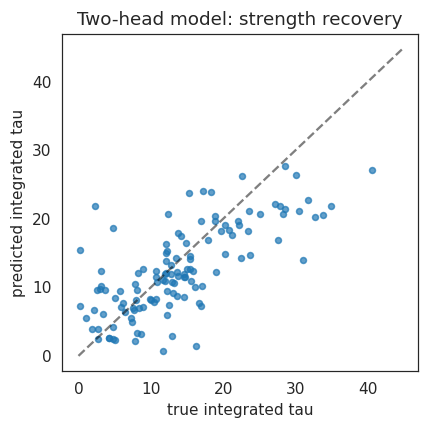

In [149]:

all_matched, all_missed, all_fp = [], [], []
for s in val_samples:
    detect_logits, strength_pred = predict_two_head(two_head_model, s, device=device)
    true_dets = extract_lines_v4(s["label"], s["z_qso"], REST_GRID, METAL_LINES)
    pred_dets = extract_lines_two_head(detect_logits, strength_pred, s["z_qso"], REST_GRID, METAL_LINES)
    matched, missed, false_pos = match_detections_v2(true_dets, pred_dets, tol_pix=3)
    all_matched += matched
    all_missed += missed
    all_fp += false_pos

n_true = len(all_matched) + len(all_missed)
n_pred = len(all_matched) + len(all_fp)
completeness = len(all_matched) / n_true if n_true else float("nan")
purity = len(all_matched) / n_pred if n_pred else float("nan")

print(f"validation set: {len(val_samples)} spectra")
print(f"true lines:     {n_true}")
print(f"predicted:      {n_pred}")
print(f"completeness:   {completeness:.2f}")
print(f"purity:         {purity:.2f}")

if all_matched:
    true_s = np.array([m[0]["integrated_tau"] for m in all_matched])
    pred_s = np.array([m[1]["integrated_tau"] for m in all_matched])
    print(f"strength bias:    {np.mean(pred_s - true_s):.4f}")
    print(f"strength scatter: {np.std(pred_s - true_s):.4f}")

    plt.figure(figsize=(4, 4), dpi=110)
    lims = [0, max(true_s.max(), pred_s.max()) * 1.1 + 1e-6]
    plt.plot(lims, lims, "k--", alpha=0.5)
    plt.scatter(true_s, pred_s, s=15, alpha=0.7)
    plt.xlabel("true integrated tau")
    plt.ylabel("predicted integrated tau")
    plt.title("Two-head model: strength recovery")
    plt.tight_layout()
    plt.show()


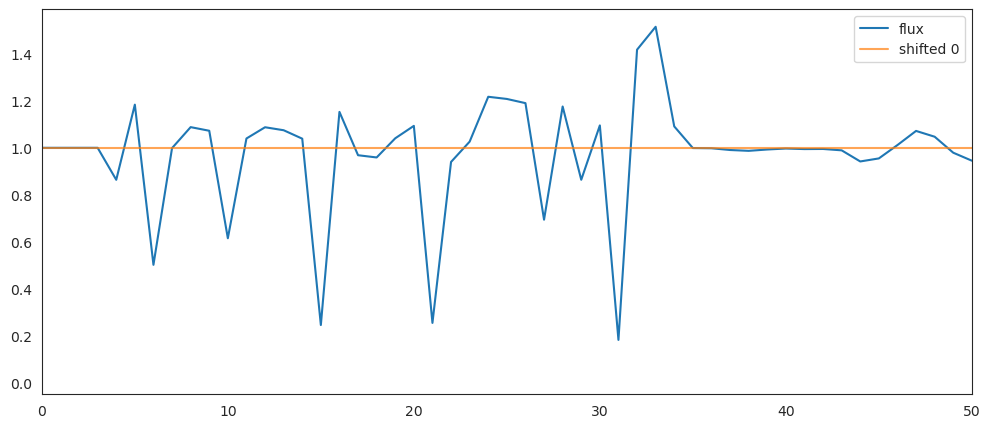

In [150]:
plt.figure(figsize=(12, 5))

plt.plot(
    _sample["flux"],
    label="flux",
)

shifted = make_shifted_channels(_sample["flux"])

for i in range(shifted.shape[0]):
    plt.plot(
        shifted[i],
        label=f"shifted {i}",
        alpha=0.7,
    )

plt.xlim(0, 50)
plt.legend()
plt.show()

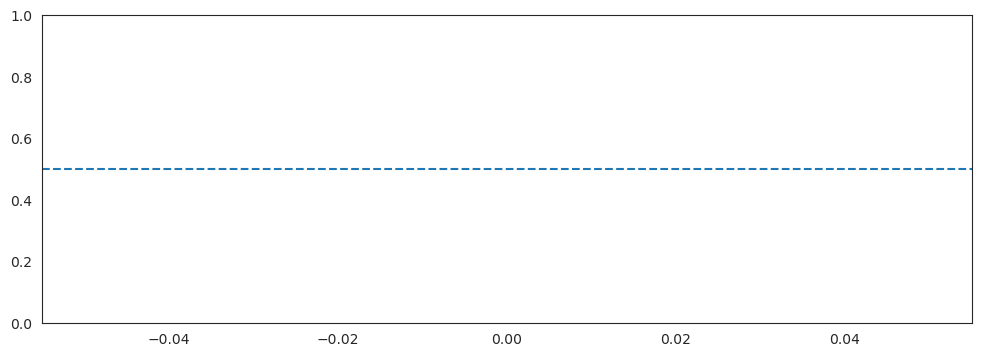

In [151]:
plt.figure(figsize=(12, 4))

plt.plot(
    probs[0],
    label="detection probability",
)

plt.axhline(0.5, ls="--")

# plt.xlim(0, 50)
plt.ylim(0, 1)

# plt.legend()
plt.show()

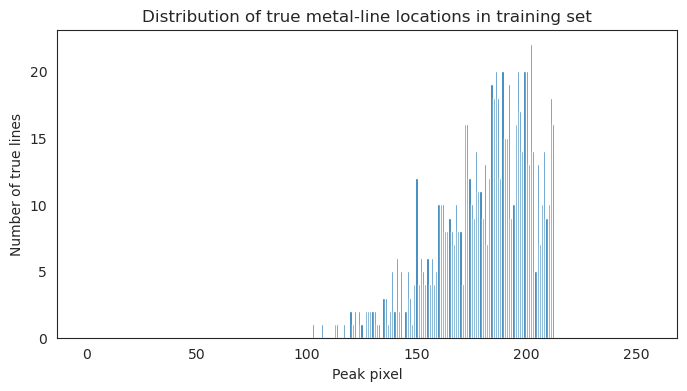

In [153]:
all_peak_pixels = []

for s in train_samples:
    labels = s["label"]

    for metal in range(labels.shape[0]):
        peaks, _ = find_peaks(
            labels[metal],
            height=0.01,
            distance=3,
        )
        all_peak_pixels.extend(peaks)

plt.figure(figsize=(8, 4))
plt.hist(all_peak_pixels, bins=np.arange(257) - 0.5)
plt.xlabel("Peak pixel")
plt.ylabel("Number of true lines")
plt.title("Distribution of true metal-line locations in training set")
plt.show()

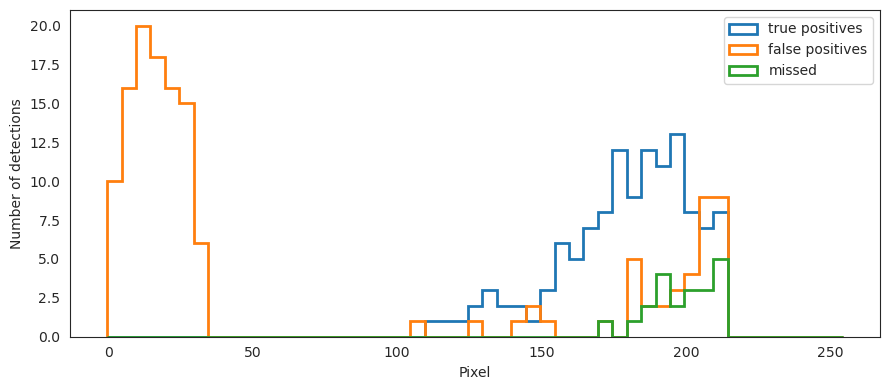

In [154]:
tp_pix = np.array([
    m[1]["pixel"] for m in all_matched
])

fp_pix = np.array([
    d["pixel"] for d in all_fp
])

miss_pix = np.array([
    d["pixel"] for d in all_missed
])

plt.figure(figsize=(9, 4))

bins = np.arange(-0.5, 256.5, 5)

plt.hist(tp_pix, bins=bins, histtype="step", linewidth=2, label="true positives")
plt.hist(fp_pix, bins=bins, histtype="step", linewidth=2, label="false positives")
plt.hist(miss_pix, bins=bins, histtype="step", linewidth=2, label="missed")

plt.xlabel("Pixel")
plt.ylabel("Number of detections")
plt.legend()
plt.tight_layout()
plt.show()

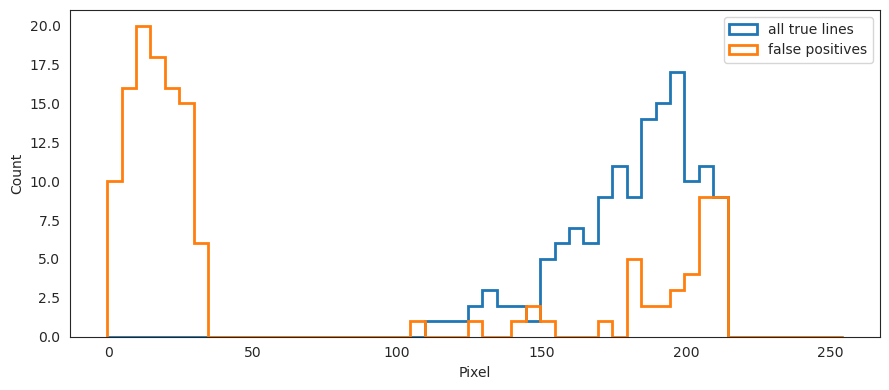

In [155]:
true_pix = []

for s in val_samples:
    for m in range(s["label"].shape[0]):
        peaks, _ = find_peaks(
            s["label"][m],
            height=0.01,
            distance=3
        )
        true_pix.extend(peaks)

plt.figure(figsize=(9, 4))

plt.hist(true_pix, bins=bins, histtype="step", linewidth=2, label="all true lines")
plt.hist(fp_pix, bins=bins, histtype="step", linewidth=2, label="false positives")

plt.xlabel("Pixel")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

In [116]:
detect_logits, strength_pred = predict_two_head(
    two_head_model, val_samples[1], device=device
)

probs = torch.sigmoid(
    torch.from_numpy(detect_logits)
).numpy()

print("Logit stats:")
print("  min:", detect_logits.min())
print("  max:", detect_logits.max())
print("  mean:", detect_logits.mean())

print("\nProbability stats:")
print("  min:", probs.min())
print("  max:", probs.max())
print("  mean:", probs.mean())

for threshold in [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]:
    print(f"pixels > {threshold}: {(probs > threshold).sum()}")

Logit stats:
  min: -5.621026
  max: 1.9207021
  mean: -1.998077

Probability stats:
  min: 0.00360786
  max: 0.8722167
  mean: 0.22319199
pixels > 0.01: 252
pixels > 0.05: 131
pixels > 0.1: 94
pixels > 0.2: 77
pixels > 0.3: 70
pixels > 0.5: 66


In [117]:
y = val_samples[1]["label"]
y_detect = build_detection_targets(y)

for metal in range(N_METALS):
    true_peaks, _ = find_peaks(y[metal], height=0.01, distance=3)

    print(f"\nMetal {metal}")
    for p in true_peaks:
        print(
            f"pixel {p:3d}: "
            f"true tau={y[metal, p]:.3f}, "
            f"target={y_detect[metal, p]:.3f}, "
            f"prob={probs[metal, p]:.4f}"
        )


Metal 0
pixel 186: true tau=0.225, target=1.000, prob=0.7561
pixel 190: true tau=0.792, target=1.000, prob=0.8604
pixel 195: true tau=1.010, target=1.000, prob=0.8722
pixel 198: true tau=0.132, target=1.000, prob=0.7055
pixel 201: true tau=0.595, target=1.000, prob=0.8336
pixel 207: true tau=0.143, target=1.000, prob=0.7364
pixel 211: true tau=0.642, target=1.000, prob=0.8586


In [118]:
# detect_prob = torch.sigmoid(detect_logits)
# strength_raw = self.strength_head(feat)
# strength = detect_prob * strength_raw

In [119]:
x, y_detect, y_strength, w = next(iter(train_loader_v2))

print("Detection target:")
print("  min:", y_detect.min().item())
print("  max:", y_detect.max().item())
print("  mean:", y_detect.mean().item())
print("  fraction > 0:", (y_detect > 0).float().mean().item())
print("  fraction > 0.1:", (y_detect > 0.1).float().mean().item())
print("  fraction > 0.5:", (y_detect > 0.5).float().mean().item())
print("  fraction == 1:", (y_detect == 1).float().mean().item())

print("\nPer-sample number of peaks:")
for i in range(min(10, len(y_detect))):
    print(i, (y_detect[i] == 1).sum().item())

Detection target:
  min: 0.0
  max: 1.0
  mean: 0.08444637060165405
  fraction > 0: 0.2681884765625
  fraction > 0.1: 0.12646484375
  fraction > 0.5: 0.0794677734375
  fraction == 1: 0.0264892578125

Per-sample number of peaks:
0 5
1 8
2 9
3 6
4 6
5 8
6 6
7 7
8 7
9 7


In [120]:
sample = train_samples[0]

dataset_one = MetalLineDatasetV2([sample])
loader_one = DataLoader(dataset_one, batch_size=1, shuffle=True)

model_test = TwoHeadMetalCNN(
    in_channels=2 + N_METALS,
    n_metals=N_METALS,
).to(device)

model_test.train()
opt = torch.optim.Adam(model_test.parameters(), lr=1e-3)

for step in range(1000):
    for x, y_detect, y_strength, w in loader_one:

        x = x.to(device)
        y_detect = y_detect.to(device)

        opt.zero_grad()

        logits, strength = model_test(x)

        loss = torch.nn.functional.binary_cross_entropy_with_logits(
            logits,
            y_detect,
        )

        loss.backward()
        opt.step()

    if step % 100 == 0:
        with torch.no_grad():
            probs = torch.sigmoid(logits)

        print(
            step,
            "loss:", loss.item(),
            "prob max:", probs.max().item(),
            "prob mean:", probs.mean().item(),
        )

0 loss: 0.7041165828704834 prob max: 0.5101403594017029 prob mean: 0.5067067742347717
100 loss: 0.1509142369031906 prob max: 0.8217519521713257 prob mean: 0.10715185850858688
200 loss: 0.05953731760382652 prob max: 0.9333008527755737 prob mean: 0.09132050722837448
300 loss: 0.0820944607257843 prob max: 0.9960144758224487 prob mean: 0.11943341791629791
400 loss: 0.05532876402139664 prob max: 0.9975595474243164 prob mean: 0.09328654408454895
500 loss: 0.05484039708971977 prob max: 0.9998247027397156 prob mean: 0.09342791140079498
600 loss: 0.054708562791347504 prob max: 0.9999628067016602 prob mean: 0.09332817792892456
700 loss: 0.0546560101211071 prob max: 0.9999833106994629 prob mean: 0.09358794242143631
800 loss: 0.05461983382701874 prob max: 0.9999899864196777 prob mean: 0.09290672838687897
900 loss: 0.05460956320166588 prob max: 0.9999924898147583 prob mean: 0.09261162579059601


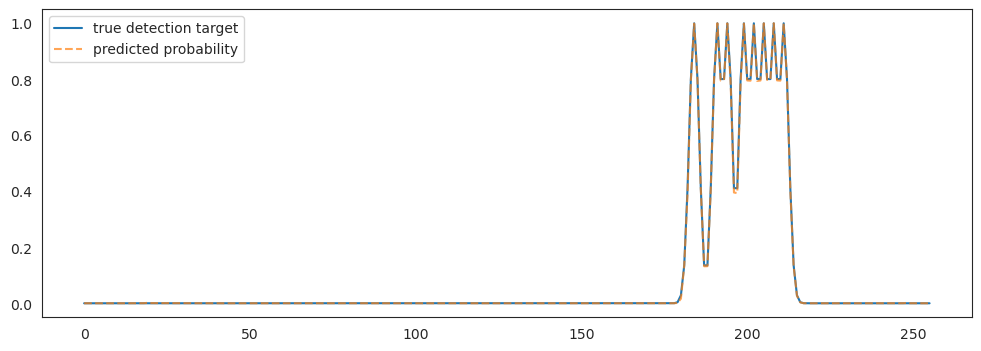

In [121]:
plt.figure(figsize=(12, 4))

plt.plot(
    y_detect[0, 0].cpu().numpy(),
    label="true detection target",
)

plt.plot(
    probs[0, 0].detach().cpu().numpy(),
    label="predicted probability",
    ls = 'dashed', alpha=0.7
)

plt.legend()
plt.show()

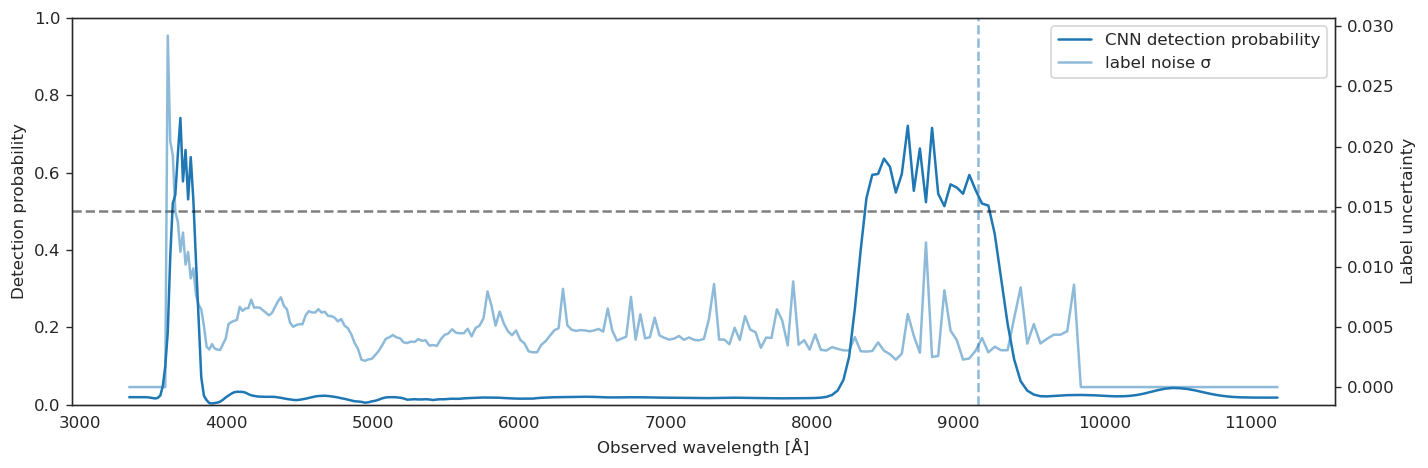

In [156]:
label_sigma = np.zeros(N_PIX)
w = example_sample["weight"][0]
label_sigma[w > 0] = 1.0 / np.sqrt(w[w > 0])

detect_logits, strength_pred = predict_two_head(
    two_head_model,
    example_sample,
    device=device,
)

prob = 1 / (1 + np.exp(-detect_logits[0]))

fig, ax1 = plt.subplots(figsize=(12, 4), dpi=120)

ax1.plot(
    obs_wave_ex,
    prob,
    label="CNN detection probability",
)
ax1.axhline(0.5, color="k", ls="--", alpha=0.5)
ax1.set_ylabel("Detection probability")
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()

ax2.plot(
    obs_wave_ex,
    label_sigma,
    alpha=0.5,
    label="label noise σ",
)
ax2.set_ylabel("Label uncertainty")

ax1.axvline(
    2852.96 * (1 + z_qso_ex),
    ls="--",
    alpha=0.5,
)

ax1.set_xlabel("Observed wavelength [Å]")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
)

plt.tight_layout()
plt.show()

In [103]:
true_peaks, _ = find_peaks(
    _sample["label"][0],
    height=0.01,
    distance=3,
)

pred_peaks, _ = find_peaks(
    probs[0],
    height=0.5,
    distance=3,
)

print("True peaks:", true_peaks)
print("Pred peaks:", pred_peaks)

True peaks: [186 190 195 198 201 207 211]
Pred peaks: [  1   6  10  15  18  21  29 186 190 195 198 201 207 211 214]


In [104]:
metal_name = list(METAL_LINES.keys())[0]
metal_rest_wave = METAL_LINES[metal_name]

p = probs[0]

peaks, props = find_peaks(
    p,
    height=0.5,
    distance=3,
)

metal_pix = np.argmin(
    np.abs(REST_GRID - metal_rest_wave)
)

print("metal:", metal_name)
print("metal rest wavelength:", metal_rest_wave)
print("metal_pix:", metal_pix)
print("n raw probability peaks:", len(peaks))

for pk in peaks:
    rest_wave_at_p = REST_GRID[pk]
    z_abs = (
        rest_wave_at_p * (1 + _sample["z_qso"]) /
        metal_rest_wave
    ) - 1.0

    reason = "ACCEPT"
    if pk > metal_pix:
        reason = "REJECT: pk > metal_pix"
    elif z_abs < 0:
        reason = "REJECT: z_abs < 0"
    elif z_abs > _sample["z_qso"]:
        reason = "REJECT: z_abs > z_qso"

    print(
        f"pk={pk:3d}, "
        f"prob={p[pk]:.3f}, "
        f"z_abs={z_abs:.3f}, "
        f"{reason}"
    )

metal: MgI(2853)
metal rest wavelength: 2852.96
metal_pix: 212
n raw probability peaks: 15
pk=  1, prob=0.599, z_abs=0.248, ACCEPT
pk=  6, prob=0.713, z_abs=0.278, ACCEPT
pk= 10, prob=0.703, z_abs=0.302, ACCEPT
pk= 15, prob=0.758, z_abs=0.334, ACCEPT
pk= 18, prob=0.693, z_abs=0.353, ACCEPT
pk= 21, prob=0.741, z_abs=0.372, ACCEPT
pk= 29, prob=0.639, z_abs=0.425, ACCEPT
pk=186, prob=0.714, z_abs=2.000, ACCEPT
pk=190, prob=0.780, z_abs=2.057, ACCEPT
pk=195, prob=0.781, z_abs=2.131, ACCEPT
pk=198, prob=0.686, z_abs=2.175, ACCEPT
pk=201, prob=0.760, z_abs=2.221, ACCEPT
pk=207, prob=0.709, z_abs=2.314, ACCEPT
pk=211, prob=0.786, z_abs=2.377, ACCEPT
pk=214, prob=0.649, z_abs=2.426, REJECT: pk > metal_pix
